In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl 
import pybaseball as pb
from pybaseball import statcast
import sklearn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from datetime import date
import requests
from bs4 import BeautifulSoup
from pandasql import sqldf
import duckdb


# Imputing Nulls

In [2]:
rookieDF = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/rookieDF.csv')
GBS = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/GameBoxScoresFinal.csv')

/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_61662/3410768775.py:2: DtypeWarning: Columns (0: AwayLineScore) have mixed types. Specify dtype option on import or set low_memory=False.
  GBS = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/GameBoxScoresFinal.csv')


In [ ]:
GBS

In [3]:
# For rookie hitters, I created a dataframe with aggregated statistics for Top50, Non-Top 50, and All rookies to use as references for imputing NULL values.

rookieDF['OPS'] = rookieDF['OBP'] + rookieDF['SLG']

stats_list = [
    'PA', 'BB%', 'K%', 'AVG', 'OBP', 'SLG', 
    'wOBA', 'xwOBA', 'wRC+', 'BsR', 'WAR', 'OPS'
]

# 1. Get the split stats
split_stats = rookieDF.groupby('Top50_Indicator')[stats_list].agg(['mean', 'median'])

# 2. Get the "All" stats simply
all_stats_raw = rookieDF[stats_list].agg(['mean', 'median'])

flattened_cols = [f'{stat}_{metric}' for stat in stats_list for metric in ['mean', 'median']]

split_stats.columns = flattened_cols
split_stats.index = ['Non-Top 50', 'Top 50']

all_rookies_row = pd.DataFrame([all_stats_raw.values.flatten('F')], 
                                columns=flattened_cols, 
                                index=['All Rookies'])

# 5. Combine 
final_comparison = pd.concat([split_stats, all_rookies_row])

final_comparison

,PA_mean,PA_median,BB%_mean,BB%_median,K%_mean,K%_median,AVG_mean,AVG_median,OBP_mean,OBP_median,...,xwOBA_mean,xwOBA_median,wRC+_mean,wRC+_median,BsR_mean,BsR_median,WAR_mean,WAR_median,OPS_mean,OPS_median
Non-Top 50,114.340301,68.0,0.073439,0.069,0.288316,0.273,0.204425,0.215,0.270493,0.2825,...,0.264994,0.275,63.113255,70.0,0.092642,0.0,0.154933,0.0,0.590607,0.617
Top 50,233.276382,162.0,0.079352,0.078,0.266261,0.265,0.230618,0.239,0.299603,0.3090,...,0.300286,0.306,88.301508,93.0,0.379397,0.0,0.835678,0.3,0.687302,0.706
All Rookies,131.306810,75.0,0.074282,0.070,0.285170,0.273,0.208161,0.219,0.274646,0.2860,...,0.270050,0.280,66.716751,73.0,0.133548,0.0,0.252043,0.0,0.604401,0.629


In [ ]:
final_comparison

In [4]:
rookieDFPitcher = pd.read_csv("/Users/owendrummond/Documents/python_projects/Capstone/RookieDFPitcher.csv")
rookieDFPitcher

,index,Name,Team,W,L,SV,G,GS,IP,K_9,...,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Top50_Indicator
0,1,Taylor Cole,LAA,0,0,0,2,2,2.1,15.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2,Chris Flexen,NYM,0,1,0,1,1,3.0,6.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,3,Luke Farrell,CHC,0,2,0,2,2,6.0,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,4,Jalen Beeks,BOS,0,1,0,1,1,4.0,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,5,Evan Phillips,BAL,0,1,0,1,1,2.0,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,101,Luke Little,CHC,0,0,0,1,1,1.0,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
737,102,AJ Smith-Shawver,ATL,0,0,0,1,1,4.1,8.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
738,103,Ben Joyce,LAA,0,0,0,1,1,2.0,13.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
739,104,Orion Kerkering,PHI,0,0,0,2,2,2.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
# For rookie hitters, I created a dataframe with aggregated statistics for Top50, Non-Top 50, and All rookies to use as references for imputing NULL values.

pitcher_stats = [
    'IP', 'K_9', 'BB_9', 'K_BB', 'GB_pct', 
    'ERA', 'xERA', 'FIP', 'xFIP', 'WAR', 'SIERA'
]

# 1. Get the split stats (Mean and Median)
split_stats_p = rookieDFPitcher.groupby('Top50_Indicator')[pitcher_stats].agg(['mean', 'median'])

# 2. Get the "All" stats for the baseline
all_stats_raw_p = rookieDFPitcher[pitcher_stats].agg(['mean', 'median'])

flattened_cols_p = [f'{stat}_{metric}' for stat in pitcher_stats for metric in ['mean', 'median']]

# 4. Re-assign columns and index to the split dataframe
split_stats_p.columns = flattened_cols_p
split_stats_p.index = ['Non-Top 50', 'Top 50']

all_rookies_row_p = pd.DataFrame([all_stats_raw_p.values.flatten('F')], 
                                  columns=flattened_cols_p, 
                                  index=['All Rookies'])

final_pitcher_comparison = pd.concat([split_stats_p, all_rookies_row_p])

final_pitcher_comparison

,IP_mean,IP_median,K_9_mean,K_9_median,BB_9_mean,BB_9_median,K_BB_mean,K_BB_median,GB_pct_mean,GB_pct_median,...,xERA_mean,xERA_median,FIP_mean,FIP_median,xFIP_mean,xFIP_median,WAR_mean,WAR_median,SIERA_mean,SIERA_median
Non-Top 50,32.269102,17.2,7.546925,7.440,4.394521,3.650,2.134064,2.000,0.406904,0.4000,...,6.068721,5.170,5.740898,5.07,5.224962,4.990,0.224049,0.1,5.155647,4.97
Top 50,54.817857,34.2,9.092500,8.675,3.796429,3.375,2.901667,2.845,0.420464,0.4025,...,4.580238,4.395,4.538333,4.32,4.498333,4.325,0.720238,0.4,4.459643,4.35
All Rookies,34.825236,20.0,7.722132,7.640,4.326721,3.630,2.221080,2.000,0.408441,0.4000,...,5.899987,5.000,5.604575,4.93,5.142591,4.910,0.280297,0.1,5.076748,4.90


In [9]:
player_dim = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/player_dim.csv')
player_dim

,player_name,retro_id,mlb_id,bref_id,fg_id
0,Joey Bart,bartj003,663698,bartjo01,21524
1,Jose Herrera,herrj003,645444,herrejo04,17040
2,Gavin Lux,lux-g001,666158,luxga01,19955
3,Andrew Vaughn,vauga001,683734,vaughan01,26197
4,Bradley Zimmer,zimmb001,605548,zimmebr01,16221
...,...,...,...,...,...
2477,Austin Kitchen,kitca001,685116,kitchau01,27910
2478,Ariel Miranda,miraa002,664641,miranar01,17526
2479,Luis Santos,santl001,608601,santolu01,15006
2480,Mychal Givens,givem001,571710,givenmy01,10430


In [23]:
topProspects = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/topProspects.csv')
topProspects

,Top 100Rank in all baseball,Org RkRank within team's farm system,NameName,OrgMLB Organization,"PosProjected defensive position or pitching role (Starter, Multi-, or Single-inning Relief)",Current LevelMost recent the level played at or had a transaction to,TrendFV change since last ranking,FVFuture Value (Explanation),ETAProjected year of debut/ loss of prospect eligibility,RiskDistance between ceiling and floor outcomes,...,TThrows,"SignedYear, round, organization",Signed FromSigned From,VideoVideo,ReportScouting report,Sign YrSign Yr,Sign MktSign Mkt,Sign OrgSign Org,BonusBonus,Name_Clean
0,1,1.0,Yoán Moncada,CHW,INF,MLB,NaN,70,2017,NaN,...,R,j2 2015,Cuba,NaN,NaN,NaN,NaN,NaN,NaN,yoán moncada
1,2,1.0,Andrew Benintendi,BOS,OF,MLB,NaN,65,2017,NaN,...,L,1st rd 2015,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,andrew benintendi
2,3,1.0,Amed Rosario,NYM,SS,MLB,NaN,65,2017,NaN,...,R,J2 2012,Dominican Republic,NaN,NaN,NaN,NaN,NaN,NaN,amed rosario
3,4,1.0,Dansby Swanson,ATL,SS,MLB,NaN,65,2017,NaN,...,R,1st rd 2015,Vanderbilt,NaN,NaN,NaN,NaN,NaN,NaN,dansby swanson
4,5,1.0,Austin Meadows,PIT,OF,NaN,NaN,65,2017,NaN,...,L,1st rd 2013,Grayson HS (GA),NaN,NaN,NaN,NaN,NaN,NaN,austin meadows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,46,NaN,Eduardo Tait,MIN,C,A+,NaN,50,2029,High,...,R,NaN,Panama,NaN,NaN,2023.0,Intl15,PHI,$8k,eduardo tait
496,47,1.0,Ethan Holliday,COL,3B,A,NaN,50,2029,High,...,R,NaN,Stillwater HS (OK),NaN,NaN,2025.0,Draft,COL,$9.0M,ethan holliday
497,48,2.0,Arjun Nimmala,TOR,SS,A+,NaN,50,2028,High,...,R,NaN,Strawberry Crest HS (FL),NaN,NaN,2023.0,Draft,TOR,$3.0M,arjun nimmala
498,49,1.0,George Lombard Jr.,NYY,SS,AA,NaN,50,2027,High,...,R,NaN,Gulliver Schools (FL),NaN,NaN,2023.0,Draft,NYY,$3.3M,george lombard jr.


In [24]:
# Removing special characters like accent marks from name fields of rookieDFs and topProspects for joining purposes.

import unicodedata

def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str
    # Normalize the string to "Decomposition" form
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    # Filter out non-spacing mark characters (the accents)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

# Apply to the Name column
rookieDF['Name'] = rookieDF['Name'].apply(remove_accents)
rookieDFPitcher['Name'] = rookieDFPitcher['Name'].apply(remove_accents)
topProspects['NameName'] = topProspects['NameName'].apply(remove_accents)

In [43]:
# topProspects enhanced with player_dim info

topProspectMaster = duckdb.query("""
select
distinct
tp.NameName,
pd.player_name, pd.mlb_id, pd.retro_id, pd.fg_id, pd.bref_id

from topProspects tp 
left join player_dim pd on tp.NameName = pd.player_name
order by pd.player_name

""").df()

In [46]:
# There were some players (with Jr. or other unique attributes to their names) with ID retrievla issues. They are manually fixed here.

manual_fg_map = {
    "Fernando Tatis Jr.": 19709,
    "Michael Harris II": 25931,
    "Michael Soroka": 18383,
    "Jose Barrero": 23378,
    "CJ Abrams": 25768,
    "Vladimir Guerrero Jr.": 19611,
    "Ronald Acuna Jr.": 18401,
    "Jazz Chisholm Jr.": 20454,
    "Bobby Witt Jr.": 25764,
    "Luis Robert Jr.": 20043
}

topProspectMaster['fg_id'] = pd.to_numeric(topProspectMaster['fg_id'], errors='coerce')

for name, fgid in manual_fg_map.items():
    topProspectMaster.loc[topProspectMaster['NameName'] == name, 'fg_id'] = fgid

updated_names = list(manual_fg_map.keys())
print(topProspectMaster[topProspectMaster['NameName'].isin(updated_names)][['NameName', 'fg_id']])

                  NameName    fg_id
235     Fernando Tatis Jr.  19709.0
240        Luis Robert Jr.  20043.0
248           Jose Barrero  23378.0
269       Ronald Acuna Jr.  18401.0
271      Jazz Chisholm Jr.  20454.0
272         Bobby Witt Jr.  25764.0
282         Michael Soroka  18383.0
289      Michael Harris II  25931.0
291              CJ Abrams  25768.0
294  Vladimir Guerrero Jr.  19611.0


In [47]:
topProspectMaster['fg_id'] = topProspectMaster['fg_id'].astype('Int64')

In [162]:
# Checking NULL values of columns in GBS. This was used throuhgout the process of imputataion to check progress.

def get_columns_with_nulls(df):
    null_mask = df.isnull().any()
    
    null_cols = null_mask[null_mask].index.tolist()
    
    return null_cols

null_columns_list = get_columns_with_nulls(GBS)

print(f"Total columns with nulls: {len(null_columns_list)}")
print(null_columns_list)

Total columns with nulls: 0
[]


## Actual editing of GBS

----------
----------
---------

In [128]:
# Impute fielding columns with inherent statistical average of 0.0

fielding_cols = [
    'AwayFieldingRunsC', 'AwayFieldingRuns1B', 'AwayFieldingRuns2B', 'AwayFieldingRuns3B', 
    'AwayFieldingRunsSS', 'AwayFieldingRunsLF', 'AwayFieldingRunsCF', 'AwayFieldingRunsRF', 
    'HomeFieldingRunsC', 'HomeFieldingRuns1B', 'HomeFieldingRuns2B', 'HomeFieldingRuns3B', 
    'HomeFieldingRunsSS', 'HomeFieldingRunsLF', 'HomeFieldingRunsCF', 'HomeFieldingRunsRF'
]
GBS[fielding_cols] = GBS[fielding_cols].fillna(0.0)

In [129]:
# Imputation of L2 pitcher stats using matching logic on Top50Prospect status

l2_map = {
    'GB_pct_L2': 'GB_pct', 'IP_L2': 'IP', 'WAR_L2': 'WAR', 'ERA_L2': 'ERA',
    'K_9_L2': 'K_9', 'BB_9_L2': 'BB_9', 'K_BB_L2': 'K_BB', 'FIP_L2': 'FIP',
    'xFIP_L2': 'xFIP', 'SIERA_L2': 'SIERA', 'xERA_L2': 'xERA'
}

top_50_ids = set(topProspectMaster['fg_id'])

for side in ['Home', 'Away']:
    id_col = f'{side}PitcherIDFG'
    is_top50 = GBS[id_col].isin(top_50_ids)
    
    for suffix, base_stat in l2_map.items():
        col = f'{side}SP_{suffix}'
        
        # Get Means
        t50_mean = final_pitcher_comparison.loc['Top 50', f'{base_stat}_mean']
        nt50_mean = final_pitcher_comparison.loc['Non-Top 50', f'{base_stat}_mean']
        
        # Double cumulative stats
        if base_stat in ['WAR', 'IP']:
            t50_mean *= 2
            nt50_mean *= 2
            
        # Impute
        GBS.loc[is_top50 & GBS[col].isnull(), col] = t50_mean
        GBS.loc[~is_top50 & GBS[col].isnull(), col] = nt50_mean

# 40th Percentile Imputes for L2 Extras
l2_percentile_cols80 = ['HomeSP_kwERA_L2', 'HomeSP_Barrel_pct_L2',  'HomeSP_FB_pct_L2',
                      'AwaySP_kwERA_L2', 'AwaySP_Barrel_pct_L2', 'AwaySP_FB_pct_L2']

l2_percentile_cols20 = ['HomeSP_GB_FB_L2', 'AwaySP_GB_FB_L2']

for col in l2_percentile_cols20:
    GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))
    
for col in l2_percentile_cols80:
    GBS[col] = GBS[col].fillna(GBS[col].quantile(0.8))

In [130]:
# Imputation of L5M pitcher stats using matching logic on Top50Prospect status

for side in ['Home', 'Away']:
    id_col = f'{side}PitcherIDFG'
    is_top50 = GBS[id_col].isin(top_50_ids)
    
    for stat in ['IP', 'ERA']:
        col = f'{side}SP_{stat}_L5M'
        t50_val = final_pitcher_comparison.loc['Top 50', f'{stat}_mean']
        nt50_val = final_pitcher_comparison.loc['Non-Top 50', f'{stat}_mean']
        
        GBS.loc[is_top50 & GBS[col].isnull(), col] = t50_val
        GBS.loc[~is_top50 & GBS[col].isnull(), col] = nt50_val

l5m_pct_cols80 = ['HomeSP_DRA_L5M', 'HomeSP_BBpct_L5M',
                'AwaySP_DRA_L5M', 'AwaySP_BBpct_L5M']

l5m_pct_cols20 = ['HomeSP_Kpct_L5M', 'AwaySP_Kpct_L5M']

for col in l5m_pct_cols80:
    GBS[col] = GBS[col].fillna(GBS[col].quantile(0.8))
    
for col in l5m_pct_cols20:
    GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))

In [131]:
# Imputation of L4A pitcher stats using 20th percentiles

l4a_stats80 = [
    'ERA_L4A', 'BB9_L4A', 'FIP_L4A', 
    'xFIP_L4A', 'SIERA_L4A', 'xERA_L4A', 'Barrel_pct_L4A',
    'FB_pct_L4A'
]

l4a_stats20 = ['IP_L4A', 'SO9_L4A', 'K_BB_L4A', 'GB_FB_L4A', 'GB_pct_L4A']

for side in ['Home', 'Away']:
    for stat in l4a_stats80:
        col = f'{side}SP_{stat}'
        if col in GBS.columns:
            GBS[col] = GBS[col].fillna(GBS[col].quantile(0.8))
            
for side in ['Home', 'Away']:
    for stat in l4a_stats20:
        col = f'{side}SP_{stat}'
        if col in GBS.columns:
            GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))

In [133]:
GBS['HomeB1_DRC_plus_L5M'].quantile(0.80)

np.float64(117.57507987220448)

In [134]:
# Imputation of L2 hitter stats using prospect indicators.

l2_hitter_map = {
    'PA_L2': 'PA', 'WAR_L2': 'WAR', 'BSR_L2': 'BsR', 'BB_pct_L2': 'BB%', 
    'K_pct_L2': 'K%', 'OPS_L2': 'OPS', 'wOBA_L2': 'wOBA', 
    'wRC_plus_L2': 'wRC+', 'xwOBA_L2': 'xwOBA', 
    'xAVG_L2': 'AVG', 'xSLG_L2': 'SLG'
}

#Percentile groups
pct_80_cols = ['GB_FB_L2', 'GB_pct_L2']
pct_50_cols = ['FB_pct_L2', 'LA_L2']
pct_20_cols = ['BB_K_L2', 'Barrel_pct_L2', 'maxEV_L2', 'EV90_L2']

top_50_ids = set(topProspectMaster['fg_id'])

# Iterate through sides and batting order positions
for side in ['Home', 'Away']:
    for i in range(1, 10):
        # The ID column uses 'Batter'
        id_col = f'{side}Batter{i}IDFG'
        # The Stat columns use 'B'
        prefix = f'{side}B{i}'
            
        # Identify prospect status
        is_top50 = GBS[id_col].isin(top_50_ids)
        
        #Prospect-Based Imputation
        for gbs_suffix, comp_base in l2_hitter_map.items():
            col = f'{prefix}_{gbs_suffix}'
                
            t50_val = final_comparison.loc['Top 50', f'{comp_base}_mean']
            nt50_val = final_comparison.loc['Non-Top 50', f'{comp_base}_mean']
            
            # Scale cumulative stats for 2nd year
            if comp_base in ['PA', 'WAR']:
                t50_val *= 2
                nt50_val *= 2
            
            # Apply imputation
            GBS.loc[is_top50 & GBS[col].isnull(), col] = t50_val
            GBS.loc[~is_top50 & GBS[col].isnull(), col] = nt50_val

        # Percentile-Based Imputation
        for suffix in pct_80_cols:
            col = f'{prefix}_{suffix}'
            if col in GBS.columns:
                GBS[col] = GBS[col].fillna(GBS[col].quantile(0.8))
                
        for suffix in pct_50_cols:
            col = f'{prefix}_{suffix}'
            if col in GBS.columns:
                GBS[col] = GBS[col].fillna(GBS[col].quantile(0.5))
                
        for suffix in pct_20_cols:
            col = f'{prefix}_{suffix}'
            if col in GBS.columns:
                GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))

print("Lineup imputation fixed and completed for all 18 spots.")

Lineup imputation fixed and completed for all 18 spots.


In [135]:
# Imputation of L5M hitter stats using prospect indicators.

l5m_map = {
    'OBP_L5M': 'OBP', 
    'OPS_L5M': 'OPS',
    'Kpct_L5M': 'K%', 
    'BBpct_L5M': 'BB%',
    'PA_L5M_P': 'PA',
    'OBP_L5M_P': 'OBP',
    'OPS_L5M_P': 'OPS',
    'Kpct_L5M_P': 'K%',
    'BBpct_L5M_P': 'BB%'
}

top_50_ids = set(topProspectMaster['fg_id'])

# Iterate through sides and batting order positions
for side in ['Home', 'Away']:
    for i in range(1, 10):
        # ID uses 'Batter', Stats use 'B'
        id_col = f'{side}Batter{i}IDFG'
        prefix = f'{side}B{i}'
        
        if id_col not in GBS.columns:
            continue
            
        is_top50 = GBS[id_col].isin(top_50_ids)
        
        # Prospect-Based Imputation
        for gbs_suffix, comp_base in l5m_map.items():
            col = f'{prefix}_{gbs_suffix}'
            
            if col in GBS.columns:
                t50_val = final_comparison.loc['Top 50', f'{comp_base}_mean']
                nt50_val = final_comparison.loc['Non-Top 50', f'{comp_base}_mean']
                
                # Apply imputation
                GBS.loc[is_top50 & GBS[col].isnull(), col] = t50_val
                GBS.loc[~is_top50 & GBS[col].isnull(), col] = nt50_val

        # 20th Percentile Imputation 
        drc_cols = [f'{prefix}_DRC_plus_L5M', f'{prefix}_DRC_plus_L5M_P']
        for col in drc_cols:
            if col in GBS.columns:
                GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))

print("L5M and Platoon hitting stats imputation complete.")

L5M and Platoon hitting stats imputation complete.


In [136]:
# Specifically targeting the missing regular L5M PA fields
top_50_ids = set(topProspectMaster['fg_id'])

for side in ['Home', 'Away']:
    for i in range(1, 10):
        id_col = f'{side}Batter{i}IDFG'
        pa_col = f'{side}B{i}_PA_L5M'
        
        if id_col in GBS.columns and pa_col in GBS.columns:
            is_top50 = GBS[id_col].isin(top_50_ids)
            
            # Retrieve the 1-year mean from your comparison table
            t50_pa_mean = final_comparison.loc['Top 50', 'PA_mean']
            nt50_pa_mean = final_comparison.loc['Non-Top 50', 'PA_mean']
            
            # Fill the missing values
            GBS.loc[is_top50 & GBS[pa_col].isnull(), pa_col] = t50_pa_mean
            GBS.loc[~is_top50 & GBS[pa_col].isnull(), pa_col] = nt50_pa_mean

print("Regular L5M PA fields have been filled.")

Regular L5M PA fields have been filled.


In [137]:
# Imputation of L10A hitter stats using prospect indicators.

l10a_hitter_map = {
    'AVG_L10A': 'AVG',
    'BB_pct_L10A': 'BB%',
    'K_pct_L10A': 'K%',
    'OBP_L10A': 'OBP',
    'OPS_L10A': 'OPS',
    'wOBA_L10A': 'wOBA',
    'wRC_plus_L10A': 'wRC+',
    'xwOBA_L10A': 'xwOBA',
    'xAVG_L10A': 'AVG',
    'xSLG_L10A': 'SLG'
}

top_50_ids = set(topProspectMaster['fg_id'])

# Iterate through sides and lineup spots
for side in ['Home', 'Away']:
    for i in range(1, 10):
        id_col = f'{side}Batter{i}IDFG'
        prefix = f'{side}B{i}'
        
        if id_col not in GBS.columns:
            continue
            
        is_top50 = GBS[id_col].isin(top_50_ids)
        
        # Prospect-Based Imputation
        for gbs_suffix, comp_base in l10a_hitter_map.items():
            col = f'{prefix}_{gbs_suffix}'
            
            if col in GBS.columns:
                t50_val = final_comparison.loc['Top 50', f'{comp_base}_mean']
                nt50_val = final_comparison.loc['Non-Top 50', f'{comp_base}_mean']
                
                GBS.loc[is_top50 & GBS[col].isnull(), col] = t50_val
                GBS.loc[~is_top50 & GBS[col].isnull(), col] = nt50_val

        # 20th Percentile Imputation
        pct_20_l10a = ['PA_L10A', 'BB_K_L10A', 'Barrel_pct_L10A']
        for suffix in pct_20_l10a:
            col = f'{prefix}_{suffix}'
            if col in GBS.columns:
                GBS[col] = GBS[col].fillna(GBS[col].quantile(0.2))
                
        # 80th Percentile Imputation
        col_gb_fb = f'{prefix}_GB_FB_L10A'
        if col_gb_fb in GBS.columns:
            GBS[col_gb_fb] = GBS[col_gb_fb].fillna(GBS[col_gb_fb].quantile(0.8))

print("L10A hitting stats imputation complete for the entire lineup.")

L10A hitting stats imputation complete for the entire lineup.


## Additional Cleaning

In [163]:
cols_to_remove = [
    'Unnamed: 0', 'DayOfWeek', 'AwayLeague', 'AwayGameNum', 
    'HomeLeague', 'HomeGameNum', 'OutTotal', 'Day/Night', 
    'ParkID', 'Attendence', 'LengthMin', 'AwayLineScore', 
    'HomeLineScore', 'AwayPitchersUsed', 'HomePitchersUsed', 'Finished'
]

GBS = GBS.drop(columns=cols_to_remove, errors='ignore')

In [139]:
# This block loads in park factors through web scraping. These did not end up being used in the final model, but may more future advancements.

park_urls = ['https://www.fangraphs.com/tools/guts?season=2017&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2018&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2019&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2020&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2021&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2022&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2023&teamid=0&type=pf&sortcol=2&sortdir=desc',
             'https://www.fangraphs.com/tools/guts?season=2024&teamid=0&type=pf&sortcol=2&sortdir=desc',]

parks = []

for park_url in park_urls:
    park_tbs = pd.read_html(park_url)
    park_df = park_tbs[6]
    parks.append(park_df)

parks_final = pd.concat(parks, ignore_index=True)

parks_final['Season'] = parks_final['Season'] + 1

parks_final

,Season,Team,Basic (5yr),3yr,1yr,1B,2B,3B,HR,SO,BB,GB,FB,LD,IFFB,FIP
0,2018,Rockies,115,115,115,108,113,136,110,97,103,106,99,104,86,106
1,2018,Rangers,109,111,110,105,105,116,105,97,104,102,101,104,102,104
2,2018,Diamondbacks,105,108,109,100,106,127,104,100,100,101,100,101,93,101
3,2018,Red Sox,105,105,101,102,113,106,97,99,99,101,100,101,100,99
4,2018,Indians,104,105,99,101,106,86,102,100,101,101,96,102,93,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2025,Athletics,96,97,100,100,100,100,90,100,100,100,100,101,101,97
236,2025,Mets,96,98,98,97,94,87,99,101,102,97,101,96,110,99
237,2025,Rays,96,98,100,96,98,102,96,102,101,97,99,96,100,97
238,2025,Padres,96,97,99,97,95,86,101,102,100,98,102,98,104,99


In [143]:
parks_final['Team'].unique().tolist

<bound method BaseStringArray.tolist of <ArrowStringArray>
['COL', 'TEX', 'ARI', 'BOS', 'CLE', 'CIN', 'WAS', 'ATL', 'KCR', 'BAL', 'DET',
 'MIL', 'MIN', 'PHI', 'TOR', 'NYY', 'CHC', 'PIT', 'CHW', 'LAA', 'SDP', 'HOU',
 'ATH', 'TBR', 'STL', 'SEA', 'SFG', 'LAD', 'MIA', 'NYM']
Length: 30, dtype: str>

In [141]:
GBS['HomeTeam'].unique().tolist

<bound method BaseStringArray.tolist of <ArrowStringArray>
['TOR', 'TEX', 'NYM', 'ARI', 'ATL', 'SDP', 'TBR', 'KCR', 'BAL', 'ATH', 'SEA',
 'MIA', 'LAD', 'CIN', 'DET', 'LAA', 'HOU', 'MIL', 'PIT', 'NYY', 'SFG', 'STL',
 'CHW', 'BOS', 'WAS', 'PHI', 'MIN', 'COL', 'CLE', 'CHC']
Length: 30, dtype: str>

In [142]:
# Standardizing abbreviations for park factor table

team_map = {
    'Rockies': 'COL','Rangers': 'TEX','Diamondbacks': 'ARI','Red Sox': 'BOS','Indians': 'CLE','Reds': 'CIN',    
    'Nationals': 'WAS','Braves': 'ATL','Royals': 'KCR','Orioles': 'BAL','Tigers': 'DET','Brewers': 'MIL',
    'Twins': 'MIN','Phillies': 'PHI','Blue Jays': 'TOR','Yankees': 'NYY','Cubs': 'CHC','Pirates': 'PIT',    
    'White Sox': 'CHW','Angels': 'LAA','Padres': 'SDP','Astros': 'HOU','Athletics': 'ATH','Rays': 'TBR',
    'Cardinals': 'STL','Mariners': 'SEA','Giants': 'SFG','Dodgers': 'LAD','Marlins': 'MIA','Mets': 'NYM',   
    'Cleveland': 'CLE','Guardians': 'CLE'
}

parks_final["Team"] = parks_final["Team"].map(team_map)

parks_final.rename(columns={"Basic (5yr)": "ParkFactor"}, inplace=True)

In [164]:
GameBoxScores = duckdb.query("""
select
GBS.*,
pf.ParkFactor as ParkFactor

from GBS
left join parks_final pf on GBS.HomeTeam = pf.Team
and GBS.Year = pf.Season

""").df()

In [165]:
# Creating a true GAMEID field for my data

GameBoxScores = GameBoxScores.reset_index(drop=True)

GameBoxScores["GAMEID"] = (
    GameBoxScores.index + 1
).astype(str).str.zfill(5)

In [81]:
print(GameBoxScores.columns.tolist())

['GAMEID', 'Date', 'AwayTeam', 'HomeTeam', 'AwayScore', 'HomeScore', 'HomeTeamWin', 'AwayTeamWin', 'Year', 'AwayPitcherIDFirstYear', 'HomePitcherIDFirstYear', 'AwayPitcherHand', 'HomePitcherHand', 'ParkFactor', 'DeltaFieldingRunsC', 'DeltaSP_IP_L2', 'DeltaSP_WAR_L2', 'DeltaSP_ERA_L2', 'DeltaSP_K_9_L2', 'DeltaSP_BB_9_L2', 'DeltaSP_K_BB_L2', 'DeltaSP_FIP_L2', 'DeltaSP_xFIP_L2', 'DeltaSP_SIERA_L2', 'DeltaSP_kwERA_L2', 'DeltaSP_xERA_L2', 'DeltaSP_Barrel_pct_L2', 'DeltaSP_GB_FB_L2', 'DeltaSP_GB_pct_L2', 'DeltaSP_FB_pct_L2', 'DeltaSP_IP_L5M', 'DeltaSP_ERA_L5M', 'DeltaSP_DRA_L5M', 'DeltaSP_Kpct_L5M', 'DeltaSP_BBpct_L5M', 'DeltaBP_IP_L3M', 'DeltaBP_ERA_L3M', 'DeltaBP_SO9_L3M', 'DeltaBP_BB9_L3M', 'DeltaSP_IP_L4A', 'DeltaSP_ERA_L4A', 'DeltaSP_SO9_L4A', 'DeltaSP_BB9_L4A', 'DeltaSP_K_BB_L4A', 'DeltaSP_FIP_L4A', 'DeltaSP_xFIP_L4A', 'DeltaSP_SIERA_L4A', 'DeltaSP_xERA_L4A', 'DeltaSP_Barrel_pct_L4A', 'DeltaSP_GB_FB_L4A', 'DeltaSP_GB_pct_L4A', 'DeltaSP_FB_pct_L4A', 'DeltaB1_PA_L2', 'DeltaB1_WAR_L2', 'D

In [167]:
GameBoxScores.to_csv('GameBoxScores_PreFE.csv', index=False)

## Modeling Work

----------------
---------------
--------------

In [182]:
# Ignore for now. Pivoted data set for run prediciton that I may use in future.

RunBoxScores = duckdb.query("""
-- ==========================================
-- 1. AWAY OFFENSE (Team) vs HOME DEFENSE (Opp)
-- ==========================================
SELECT
    GAMEID,
    0 AS IsHome,
    AwayScore AS TeamScore,
    -- Opposing Pitcher & Defensive IDs
    HomePitcherIDFirstYear AS OppPitcherFirstYear,

    -- Batter IDs + First Year Indicators (Restored)
    AwayBatter1IDFirstYear AS B1_FY, AwayBatter2IDFirstYear AS B2_FY, 
    AwayBatter3IDFirstYear AS B3_FY, AwayBatter4IDFirstYear AS B4_FY, 
    AwayBatter5IDFirstYear AS B5_FY, AwayBatter6IDFirstYear AS B6_FY, 
    AwayBatter7IDFirstYear AS B7_FY, AwayBatter8IDFirstYear AS B8_FY, 
    AwayBatter9IDFirstYear AS B9_FY,
    
    -- Opposing Defense (Fielding)
    HomeFieldingRunsC AS OppField_C, HomeFieldingRuns1B AS OppField_1B, 
    HomeFieldingRuns2B AS OppField_2B, HomeFieldingRuns3B AS OppField_3B, 
    HomeFieldingRunsSS AS OppField_SS, HomeFieldingRunsLF AS OppField_LF, 
    HomeFieldingRunsCF AS OppField_CF, HomeFieldingRunsRF AS OppField_RF,
    
    -- Opposing Starter Stats (L2, L5M, L4A)
    HomePitcherHand AS OppP_Hand,
    HomeSP_IP_L2 AS OppP_IP_L2, HomeSP_WAR_L2 AS OppP_WAR_L2, HomeSP_ERA_L2 AS OppP_ERA_L2,
    HomeSP_K_9_L2 AS OppP_K_9_L2, HomeSP_BB_9_L2 AS OppP_BB_9_L2, HomeSP_K_BB_L2 AS OppP_K_BB_L2,
    HomeSP_FIP_L2 AS OppP_FIP_L2, HomeSP_xFIP_L2 AS OppP_xFIP_L2, HomeSP_SIERA_L2 AS OppP_SIERA_L2,
    HomeSP_kwERA_L2 AS OppP_kwERA_L2, HomeSP_xERA_L2 AS OppP_xERA_L2, HomeSP_Barrel_pct_L2 AS OppP_Barrel_L2,
    HomeSP_GB_FB_L2 AS OppP_GB_FB_L2, HomeSP_GB_pct_L2 AS OppP_GB_pct_L2, HomeSP_FB_pct_L2 AS OppP_FB_pct_L2,
    HomeSP_IP_L5M AS OppP_IP_L5M, HomeSP_ERA_L5M AS OppP_ERA_L5M, HomeSP_DRA_L5M AS OppP_DRA_L5M,
    HomeSP_Kpct_L5M AS OppP_Kpct_L5M, HomeSP_BBpct_L5M AS OppP_BBpct_L5M,
    HomeBP_IP_L3M AS OppBP_IP_L3M, HomeBP_ERA_L3M AS OppBP_ERA_L3M, HomeBP_SO9_L3M AS OppBP_SO9_L3M, HomeBP_BB9_L3M AS OppBP_BB9_L3M,
    HomeSP_IP_L4A AS OppP_IP_L4A, HomeSP_ERA_L4A AS OppP_ERA_L4A, HomeSP_SO9_L4A AS OppP_SO9_L4A,
    HomeSP_BB9_L4A AS OppP_BB9_L4A, HomeSP_K_BB_L4A AS OppP_K_BB_L4A, HomeSP_FIP_L4A AS OppP_FIP_L4A,
    HomeSP_xFIP_L4A AS OppP_xFIP_L4A, HomeSP_SIERA_L4A AS OppP_SIERA_L4A, HomeSP_xERA_L4A AS OppP_xERA_L4A,
    HomeSP_Barrel_pct_L4A AS OppP_Barrel_L4A, HomeSP_GB_FB_L4A AS OppP_GB_FB_L4A,
    HomeSP_GB_pct_L4A AS OppP_GB_pct_L4A, HomeSP_FB_pct_L4A AS OppP_FB_pct_L4A,

    -- B1 Stats
    AwayB1_PA_L2 AS B1_PA_L2, AwayB1_WAR_L2 AS B1_WAR_L2, AwayB1_BSR_L2 AS B1_BSR_L2, AwayB1_BB_pct_L2 AS B1_BBpct_L2, 
    AwayB1_K_pct_L2 AS B1_Kpct_L2, AwayB1_BB_K_L2 AS B1_BB_K_L2, AwayB1_OPS_L2 AS B1_OPS_L2, AwayB1_GB_FB_L2 AS B1_GB_FB_L2, 
    AwayB1_GB_pct_L2 AS B1_GB_pct_L2, AwayB1_FB_pct_L2 AS B1_FB_pct_L2, AwayB1_wOBA_L2 AS B1_wOBA_L2, AwayB1_wRC_plus_L2 AS B1_wRC_plus_L2, 
    AwayB1_xwOBA_L2 AS B1_xwOBA_L2, AwayB1_xAVG_L2 AS B1_xAVG_L2, AwayB1_xSLG_L2 AS B1_xSLG_L2, AwayB1_LA_L2 AS B1_LA_L2, 
    AwayB1_Barrel_pct_L2 AS B1_Barrel_L2, AwayB1_maxEV_L2 AS B1_maxEV_L2, AwayB1_EV90_L2 AS B1_EV90_L2,
    AwayB1_PA_L5M AS B1_PA_L5M, AwayB1_OBP_L5M AS B1_OBP_L5M, AwayB1_OPS_L5M AS B1_OPS_L5M, AwayB1_DRC_plus_L5M AS B1_DRC_plus_L5M, 
    AwayB1_Kpct_L5M AS B1_Kpct_L5M, AwayB1_BBpct_L5M AS B1_BBpct_L5M,
    AwayB1_PA_L5M_P AS B1_PA_L5M_P, AwayB1_OBP_L5M_P AS B1_OBP_L5M_P, AwayB1_OPS_L5M_P AS B1_OPS_L5M_P, AwayB1_DRC_plus_L5M_P AS B1_DRC_plus_L5M_P, 
    AwayB1_Kpct_L5M_P AS B1_Kpct_L5M_P, AwayB1_BBpct_L5M_P AS B1_BBpct_L5M_P,
    AwayB1_PA_L10A AS B1_PA_L10A, AwayB1_AVG_L10A AS B1_AVG_L10A, AwayB1_BB_pct_L10A AS B1_BBpct_L10A, AwayB1_K_pct_L10A AS B1_Kpct_L10A, 
    AwayB1_BB_K_L10A AS B1_BB_K_L10A, AwayB1_OBP_L10A AS B1_OBP_L10A, AwayB1_OPS_L10A AS B1_OPS_L10A, AwayB1_GB_FB_L10A AS B1_GB_FB_L10A, 
    AwayB1_wOBA_L10A AS B1_wOBA_L10A, AwayB1_wRC_plus_L10A AS B1_wRC_plus_L10A, AwayB1_xwOBA_L10A AS B1_xwOBA_L10A, AwayB1_xAVG_L10A AS B1_xAVG_L10A, 
    AwayB1_xSLG_L10A AS B1_xSLG_L10A, AwayB1_Barrel_pct_L10A AS B1_Barrel_L10A,

    -- B2 Stats
    AwayB2_PA_L2 AS B2_PA_L2, AwayB2_WAR_L2 AS B2_WAR_L2, AwayB2_BSR_L2 AS B2_BSR_L2, AwayB2_BB_pct_L2 AS B2_BBpct_L2, 
    AwayB2_K_pct_L2 AS B2_Kpct_L2, AwayB2_BB_K_L2 AS B2_BB_K_L2, AwayB2_OPS_L2 AS B2_OPS_L2, AwayB2_GB_FB_L2 AS B2_GB_FB_L2, 
    AwayB2_GB_pct_L2 AS B2_GB_pct_L2, AwayB2_FB_pct_L2 AS B2_FB_pct_L2, AwayB2_wOBA_L2 AS B2_wOBA_L2, AwayB2_wRC_plus_L2 AS B2_wRC_plus_L2, 
    AwayB2_xwOBA_L2 AS B2_xwOBA_L2, AwayB2_xAVG_L2 AS B2_xAVG_L2, AwayB2_xSLG_L2 AS B2_xSLG_L2, AwayB2_LA_L2 AS B2_LA_L2, 
    AwayB2_Barrel_pct_L2 AS B2_Barrel_L2, AwayB2_maxEV_L2 AS B2_maxEV_L2, AwayB2_EV90_L2 AS B2_EV90_L2,
    AwayB2_PA_L5M AS B2_PA_L5M, AwayB2_OBP_L5M AS B2_OBP_L5M, AwayB2_OPS_L5M AS B2_OPS_L5M, AwayB2_DRC_plus_L5M AS B2_DRC_plus_L5M, 
    AwayB2_Kpct_L5M AS B2_Kpct_L5M, AwayB2_BBpct_L5M AS B2_BBpct_L5M,
    AwayB2_PA_L5M_P AS B2_PA_L5M_P, AwayB2_OBP_L5M_P AS B2_OBP_L5M_P, AwayB2_OPS_L5M_P AS B2_OPS_L5M_P, AwayB2_DRC_plus_L5M_P AS B2_DRC_plus_L5M_P, 
    AwayB2_Kpct_L5M_P AS B2_Kpct_L5M_P, AwayB2_BBpct_L5M_P AS B2_BBpct_L5M_P,
    AwayB2_PA_L10A AS B2_PA_L10A, AwayB2_AVG_L10A AS B2_AVG_L10A, AwayB2_BB_pct_L10A AS B2_BBpct_L10A, AwayB2_K_pct_L10A AS B2_Kpct_L10A, 
    AwayB2_BB_K_L10A AS B2_BB_K_L10A, AwayB2_OBP_L10A AS B2_OBP_L10A, AwayB2_OPS_L10A AS B2_OPS_L10A, AwayB2_GB_FB_L10A AS B2_GB_FB_L10A, 
    AwayB2_wOBA_L10A AS B2_wOBA_L10A, AwayB2_wRC_plus_L10A AS B2_wRC_plus_L10A, AwayB2_xwOBA_L10A AS B2_xwOBA_L10A, AwayB2_xAVG_L10A AS B2_xAVG_L10A, 
    AwayB2_xSLG_L10A AS B2_xSLG_L10A, AwayB2_Barrel_pct_L10A AS B2_Barrel_L10A,

    -- B3 Stats
    AwayB3_PA_L2 AS B3_PA_L2, AwayB3_WAR_L2 AS B3_WAR_L2, AwayB3_BSR_L2 AS B3_BSR_L2, AwayB3_BB_pct_L2 AS B3_BBpct_L2, 
    AwayB3_K_pct_L2 AS B3_Kpct_L2, AwayB3_BB_K_L2 AS B3_BB_K_L2, AwayB3_OPS_L2 AS B3_OPS_L2, AwayB3_GB_FB_L2 AS B3_GB_FB_L2, 
    AwayB3_GB_pct_L2 AS B3_GB_pct_L2, AwayB3_FB_pct_L2 AS B3_FB_pct_L2, AwayB3_wOBA_L2 AS B3_wOBA_L2, AwayB3_wRC_plus_L2 AS B3_wRC_plus_L2, 
    AwayB3_xwOBA_L2 AS B3_xwOBA_L2, AwayB3_xAVG_L2 AS B3_xAVG_L2, AwayB3_xSLG_L2 AS B3_xSLG_L2, AwayB3_LA_L2 AS B3_LA_L2, 
    AwayB3_Barrel_pct_L2 AS B3_Barrel_L2, AwayB3_maxEV_L2 AS B3_maxEV_L2, AwayB3_EV90_L2 AS B3_EV90_L2,
    AwayB3_PA_L5M AS B3_PA_L5M, AwayB3_OBP_L5M AS B3_OBP_L5M, AwayB3_OPS_L5M AS B3_OPS_L5M, AwayB3_DRC_plus_L5M AS B3_DRC_plus_L5M, 
    AwayB3_Kpct_L5M AS B3_Kpct_L5M, AwayB3_BBpct_L5M AS B3_BBpct_L5M,
    AwayB3_PA_L5M_P AS B3_PA_L5M_P, AwayB3_OBP_L5M_P AS B3_OBP_L5M_P, AwayB3_OPS_L5M_P AS B3_OPS_L5M_P, AwayB3_DRC_plus_L5M_P AS B3_DRC_plus_L5M_P, 
    AwayB3_Kpct_L5M_P AS B3_Kpct_L5M_P, AwayB3_BBpct_L5M_P AS B3_BBpct_L5M_P,
    AwayB3_PA_L10A AS B3_PA_L10A, AwayB3_AVG_L10A AS B3_AVG_L10A, AwayB3_BB_pct_L10A AS B3_BBpct_L10A, AwayB3_K_pct_L10A AS B3_Kpct_L10A, 
    AwayB3_BB_K_L10A AS B3_BB_K_L10A, AwayB3_OBP_L10A AS B3_OBP_L10A, AwayB3_OPS_L10A AS B3_OPS_L10A, AwayB3_GB_FB_L10A AS B3_GB_FB_L10A, 
    AwayB3_wOBA_L10A AS B3_wOBA_L10A, AwayB3_wRC_plus_L10A AS B3_wRC_plus_L10A, AwayB3_xwOBA_L10A AS B3_xwOBA_L10A, AwayB3_xAVG_L10A AS B3_xAVG_L10A, 
    AwayB3_xSLG_L10A AS B3_xSLG_L10A, AwayB3_Barrel_pct_L10A AS B3_Barrel_L10A,

    -- B4 Stats
    AwayB4_PA_L2 AS B4_PA_L2, AwayB4_WAR_L2 AS B4_WAR_L2, AwayB4_BSR_L2 AS B4_BSR_L2, AwayB4_BB_pct_L2 AS B4_BBpct_L2, 
    AwayB4_K_pct_L2 AS B4_Kpct_L2, AwayB4_BB_K_L2 AS B4_BB_K_L2, AwayB4_OPS_L2 AS B4_OPS_L2, AwayB4_GB_FB_L2 AS B4_GB_FB_L2, 
    AwayB4_GB_pct_L2 AS B4_GB_pct_L2, AwayB4_FB_pct_L2 AS B4_FB_pct_L2, AwayB4_wOBA_L2 AS B4_wOBA_L2, AwayB4_wRC_plus_L2 AS B4_wRC_plus_L2, 
    AwayB4_xwOBA_L2 AS B4_xwOBA_L2, AwayB4_xAVG_L2 AS B4_xAVG_L2, AwayB4_xSLG_L2 AS B4_xSLG_L2, AwayB4_LA_L2 AS B4_LA_L2, 
    AwayB4_Barrel_pct_L2 AS B4_Barrel_L2, AwayB4_maxEV_L2 AS B4_maxEV_L2, AwayB4_EV90_L2 AS B4_EV90_L2,
    AwayB4_PA_L5M AS B4_PA_L5M, AwayB4_OBP_L5M AS B4_OBP_L5M, AwayB4_OPS_L5M AS B4_OPS_L5M, AwayB4_DRC_plus_L5M AS B4_DRC_plus_L5M, 
    AwayB4_Kpct_L5M AS B4_Kpct_L5M, AwayB4_BBpct_L5M AS B4_BBpct_L5M,
    AwayB4_PA_L5M_P AS B4_PA_L5M_P, AwayB4_OBP_L5M_P AS B4_OBP_L5M_P, AwayB4_OPS_L5M_P AS B4_OPS_L5M_P, AwayB4_DRC_plus_L5M_P AS B4_DRC_plus_L5M_P, 
    AwayB4_Kpct_L5M_P AS B4_Kpct_L5M_P, AwayB4_BBpct_L5M_P AS B4_BBpct_L5M_P,
    AwayB4_PA_L10A AS B4_PA_L10A, AwayB4_AVG_L10A AS B4_AVG_L10A, AwayB4_BB_pct_L10A AS B4_BBpct_L10A, AwayB4_K_pct_L10A AS B4_Kpct_L10A, 
    AwayB4_BB_K_L10A AS B4_BB_K_L10A, AwayB4_OBP_L10A AS B4_OBP_L10A, AwayB4_OPS_L10A AS B4_OPS_L10A, AwayB4_GB_FB_L10A AS B4_GB_FB_L10A, 
    AwayB4_wOBA_L10A AS B4_wOBA_L10A, AwayB4_wRC_plus_L10A AS B4_wRC_plus_L10A, AwayB4_xwOBA_L10A AS B4_xwOBA_L10A, AwayB4_xAVG_L10A AS B4_xAVG_L10A, 
    AwayB4_xSLG_L10A AS B4_xSLG_L10A, AwayB4_Barrel_pct_L10A AS B4_Barrel_L10A,

    -- B5 Stats
    AwayB5_PA_L2 AS B5_PA_L2, AwayB5_WAR_L2 AS B5_WAR_L2, AwayB5_BSR_L2 AS B5_BSR_L2, AwayB5_BB_pct_L2 AS B5_BBpct_L2, 
    AwayB5_K_pct_L2 AS B5_Kpct_L2, AwayB5_BB_K_L2 AS B5_BB_K_L2, AwayB5_OPS_L2 AS B5_OPS_L2, AwayB5_GB_FB_L2 AS B5_GB_FB_L2, 
    AwayB5_GB_pct_L2 AS B5_GB_pct_L2, AwayB5_FB_pct_L2 AS B5_FB_pct_L2, AwayB5_wOBA_L2 AS B5_wOBA_L2, AwayB5_wRC_plus_L2 AS B5_wRC_plus_L2, 
    AwayB5_xwOBA_L2 AS B5_xwOBA_L2, AwayB5_xAVG_L2 AS B5_xAVG_L2, AwayB5_xSLG_L2 AS B5_xSLG_L2, AwayB5_LA_L2 AS B5_LA_L2, 
    AwayB5_Barrel_pct_L2 AS B5_Barrel_L2, AwayB5_maxEV_L2 AS B5_maxEV_L2, AwayB5_EV90_L2 AS B5_EV90_L2,
    AwayB5_PA_L5M AS B5_PA_L5M, AwayB5_OBP_L5M AS B5_OBP_L5M, AwayB5_OPS_L5M AS B5_OPS_L5M, AwayB5_DRC_plus_L5M AS B5_DRC_plus_L5M, 
    AwayB5_Kpct_L5M AS B5_Kpct_L5M, AwayB5_BBpct_L5M AS B5_BBpct_L5M,
    AwayB5_PA_L5M_P AS B5_PA_L5M_P, AwayB5_OBP_L5M_P AS B5_OBP_L5M_P, AwayB5_OPS_L5M_P AS B5_OPS_L5M_P, AwayB5_DRC_plus_L5M_P AS B5_DRC_plus_L5M_P, 
    AwayB5_Kpct_L5M_P AS B5_Kpct_L5M_P, AwayB5_BBpct_L5M_P AS B5_BBpct_L5M_P,
    AwayB5_PA_L10A AS B5_PA_L10A, AwayB5_AVG_L10A AS B5_AVG_L10A, AwayB5_BB_pct_L10A AS B5_BBpct_L10A, AwayB5_K_pct_L10A AS B5_Kpct_L10A, 
    AwayB5_BB_K_L10A AS B5_BB_K_L10A, AwayB5_OBP_L10A AS B5_OBP_L10A, AwayB5_OPS_L10A AS B5_OPS_L10A, AwayB5_GB_FB_L10A AS B5_GB_FB_L10A, 
    AwayB5_wOBA_L10A AS B5_wOBA_L10A, AwayB5_wRC_plus_L10A AS B5_wRC_plus_L10A, AwayB5_xwOBA_L10A AS B5_xwOBA_L10A, AwayB5_xAVG_L10A AS B5_xAVG_L10A, 
    AwayB5_xSLG_L10A AS B5_xSLG_L10A, AwayB5_Barrel_pct_L10A AS B5_Barrel_L10A,

    -- B6 Stats
    AwayB6_PA_L2 AS B6_PA_L2, AwayB6_WAR_L2 AS B6_WAR_L2, AwayB6_BSR_L2 AS B6_BSR_L2, AwayB6_BB_pct_L2 AS B6_BBpct_L2, 
    AwayB6_K_pct_L2 AS B6_Kpct_L2, AwayB6_BB_K_L2 AS B6_BB_K_L2, AwayB6_OPS_L2 AS B6_OPS_L2, AwayB6_GB_FB_L2 AS B6_GB_FB_L2, 
    AwayB6_GB_pct_L2 AS B6_GB_pct_L2, AwayB6_FB_pct_L2 AS B6_FB_pct_L2, AwayB6_wOBA_L2 AS B6_wOBA_L2, AwayB6_wRC_plus_L2 AS B6_wRC_plus_L2, 
    AwayB6_xwOBA_L2 AS B6_xwOBA_L2, AwayB6_xAVG_L2 AS B6_xAVG_L2, AwayB6_xSLG_L2 AS B6_xSLG_L2, AwayB6_LA_L2 AS B6_LA_L2, 
    AwayB6_Barrel_pct_L2 AS B6_Barrel_L2, AwayB6_maxEV_L2 AS B6_maxEV_L2, AwayB6_EV90_L2 AS B6_EV90_L2,
    AwayB6_PA_L5M AS B6_PA_L5M, AwayB6_OBP_L5M AS B6_OBP_L5M, AwayB6_OPS_L5M AS B6_OPS_L5M, AwayB6_DRC_plus_L5M AS B6_DRC_plus_L5M, 
    AwayB6_Kpct_L5M AS B6_Kpct_L5M, AwayB6_BBpct_L5M AS B6_BBpct_L5M,
    AwayB6_PA_L5M_P AS B6_PA_L5M_P, AwayB6_OBP_L5M_P AS B6_OBP_L5M_P, AwayB6_OPS_L5M_P AS B6_OPS_L5M_P, AwayB6_DRC_plus_L5M_P AS B6_DRC_plus_L5M_P, 
    AwayB6_Kpct_L5M_P AS B6_Kpct_L5M_P, AwayB6_BBpct_L5M_P AS B6_BBpct_L5M_P,
    AwayB6_PA_L10A AS B6_PA_L10A, AwayB6_AVG_L10A AS B6_AVG_L10A, AwayB6_BB_pct_L10A AS B6_BBpct_L10A, AwayB6_K_pct_L10A AS B6_Kpct_L10A, 
    AwayB6_BB_K_L10A AS B6_BB_K_L10A, AwayB6_OBP_L10A AS B6_OBP_L10A, AwayB6_OPS_L10A AS B6_OPS_L10A, AwayB6_GB_FB_L10A AS B6_GB_FB_L10A, 
    AwayB6_wOBA_L10A AS B6_wOBA_L10A, AwayB6_wRC_plus_L10A AS B6_wRC_plus_L10A, AwayB6_xwOBA_L10A AS B6_xwOBA_L10A, AwayB6_xAVG_L10A AS B6_xAVG_L10A, 
    AwayB6_xSLG_L10A AS B6_xSLG_L10A, AwayB6_Barrel_pct_L10A AS B6_Barrel_L10A,

    -- B7 Stats
    AwayB7_PA_L2 AS B7_PA_L2, AwayB7_WAR_L2 AS B7_WAR_L2, AwayB7_BSR_L2 AS B7_BSR_L2, AwayB7_BB_pct_L2 AS B7_BBpct_L2, 
    AwayB7_K_pct_L2 AS B7_Kpct_L2, AwayB7_BB_K_L2 AS B7_BB_K_L2, AwayB7_OPS_L2 AS B7_OPS_L2, AwayB7_GB_FB_L2 AS B7_GB_FB_L2, 
    AwayB7_GB_pct_L2 AS B7_GB_pct_L2, AwayB7_FB_pct_L2 AS B7_FB_pct_L2, AwayB7_wOBA_L2 AS B7_wOBA_L2, AwayB7_wRC_plus_L2 AS B7_wRC_plus_L2, 
    AwayB7_xwOBA_L2 AS B7_xwOBA_L2, AwayB7_xAVG_L2 AS B7_xAVG_L2, AwayB7_xSLG_L2 AS B7_xSLG_L2, AwayB7_LA_L2 AS B7_LA_L2, 
    AwayB7_Barrel_pct_L2 AS B7_Barrel_L2, AwayB7_maxEV_L2 AS B7_maxEV_L2, AwayB7_EV90_L2 AS B7_EV90_L2,
    AwayB7_PA_L5M AS B7_PA_L5M, AwayB7_OBP_L5M AS B7_OBP_L5M, AwayB7_OPS_L5M AS B7_OPS_L5M, AwayB7_DRC_plus_L5M AS B7_DRC_plus_L5M, 
    AwayB7_Kpct_L5M AS B7_Kpct_L5M, AwayB7_BBpct_L5M AS B7_BBpct_L5M,
    AwayB7_PA_L5M_P AS B7_PA_L5M_P, AwayB7_OBP_L5M_P AS B7_OBP_L5M_P, AwayB7_OPS_L5M_P AS B7_OPS_L5M_P, AwayB7_DRC_plus_L5M_P AS B7_DRC_plus_L5M_P, 
    AwayB7_Kpct_L5M_P AS B7_Kpct_L5M_P, AwayB7_BBpct_L5M_P AS B7_BBpct_L5M_P,
    AwayB7_PA_L10A AS B7_PA_L10A, AwayB7_AVG_L10A AS B7_AVG_L10A, AwayB7_BB_pct_L10A AS B7_BBpct_L10A, AwayB7_K_pct_L10A AS B7_Kpct_L10A, 
    AwayB7_BB_K_L10A AS B7_BB_K_L10A, AwayB7_OBP_L10A AS B7_OBP_L10A, AwayB7_OPS_L10A AS B7_OPS_L10A, AwayB7_GB_FB_L10A AS B7_GB_FB_L10A, 
    AwayB7_wOBA_L10A AS B7_wOBA_L10A, AwayB7_wRC_plus_L10A AS B7_wRC_plus_L10A, AwayB7_xwOBA_L10A AS B7_xwOBA_L10A, AwayB7_xAVG_L10A AS B7_xAVG_L10A, 
    AwayB7_xSLG_L10A AS B7_xSLG_L10A, AwayB7_Barrel_pct_L10A AS B7_Barrel_L10A,

    -- B8 Stats
    AwayB8_PA_L2 AS B8_PA_L2, AwayB8_WAR_L2 AS B8_WAR_L2, AwayB8_BSR_L2 AS B8_BSR_L2, AwayB8_BB_pct_L2 AS B8_BBpct_L2, 
    AwayB8_K_pct_L2 AS B8_Kpct_L2, AwayB8_BB_K_L2 AS B8_BB_K_L2, AwayB8_OPS_L2 AS B8_OPS_L2, AwayB8_GB_FB_L2 AS B8_GB_FB_L2, 
    AwayB8_GB_pct_L2 AS B8_GB_pct_L2, AwayB8_FB_pct_L2 AS B8_FB_pct_L2, AwayB8_wOBA_L2 AS B8_wOBA_L2, AwayB8_wRC_plus_L2 AS B8_wRC_plus_L2, 
    AwayB8_xwOBA_L2 AS B8_xwOBA_L2, AwayB8_xAVG_L2 AS B8_xAVG_L2, AwayB8_xSLG_L2 AS B8_xSLG_L2, AwayB8_LA_L2 AS B8_LA_L2, 
    AwayB8_Barrel_pct_L2 AS B8_Barrel_L2, AwayB8_maxEV_L2 AS B8_maxEV_L2, AwayB8_EV90_L2 AS B8_EV90_L2,
    AwayB8_PA_L5M AS B8_PA_L5M, AwayB8_OBP_L5M AS B8_OBP_L5M, AwayB8_OPS_L5M AS B8_OPS_L5M, AwayB8_DRC_plus_L5M AS B8_DRC_plus_L5M, 
    AwayB8_Kpct_L5M AS B8_Kpct_L5M, AwayB8_BBpct_L5M AS B8_BBpct_L5M,
    AwayB8_PA_L5M_P AS B8_PA_L5M_P, AwayB8_OBP_L5M_P AS B8_OBP_L5M_P, AwayB8_OPS_L5M_P AS B8_OPS_L5M_P, AwayB8_DRC_plus_L5M_P AS B8_DRC_plus_L5M_P, 
    AwayB8_Kpct_L5M_P AS B8_Kpct_L5M_P, AwayB8_BBpct_L5M_P AS B8_BBpct_L5M_P,
    AwayB8_PA_L10A AS B8_PA_L10A, AwayB8_AVG_L10A AS B8_AVG_L10A, AwayB8_BB_pct_L10A AS B8_BBpct_L10A, AwayB8_K_pct_L10A AS B8_Kpct_L10A, 
    AwayB8_BB_K_L10A AS B8_BB_K_L10A, AwayB8_OBP_L10A AS B8_OBP_L10A, AwayB8_OPS_L10A AS B8_OPS_L10A, AwayB8_GB_FB_L10A AS B8_GB_FB_L10A, 
    AwayB8_wOBA_L10A AS B8_wOBA_L10A, AwayB8_wRC_plus_L10A AS B8_wRC_plus_L10A, AwayB8_xwOBA_L10A AS B8_xwOBA_L10A, AwayB8_xAVG_L10A AS B8_xAVG_L10A, 
    AwayB8_xSLG_L10A AS B8_xSLG_L10A, AwayB8_Barrel_pct_L10A AS B8_Barrel_L10A,

    -- B9 Stats
    AwayB9_PA_L2 AS B9_PA_L2, AwayB9_WAR_L2 AS B9_WAR_L2, AwayB9_BSR_L2 AS B9_BSR_L2, AwayB9_BB_pct_L2 AS B9_BBpct_L2, 
    AwayB9_K_pct_L2 AS B9_Kpct_L2, AwayB9_BB_K_L2 AS B9_BB_K_L2, AwayB9_OPS_L2 AS B9_OPS_L2, AwayB9_GB_FB_L2 AS B9_GB_FB_L2, 
    AwayB9_GB_pct_L2 AS B9_GB_pct_L2, AwayB9_FB_pct_L2 AS B9_FB_pct_L2, AwayB9_wOBA_L2 AS B9_wOBA_L2, AwayB9_wRC_plus_L2 AS B9_wRC_plus_L2, 
    AwayB9_xwOBA_L2 AS B9_xwOBA_L2, AwayB9_xAVG_L2 AS B9_xAVG_L2, AwayB9_xSLG_L2 AS B9_xSLG_L2, AwayB9_LA_L2 AS B9_LA_L2, 
    AwayB9_Barrel_pct_L2 AS B9_Barrel_L2, AwayB9_maxEV_L2 AS B9_maxEV_L2, AwayB9_EV90_L2 AS B9_EV90_L2,
    AwayB9_PA_L5M AS B9_PA_L5M, AwayB9_OBP_L5M AS B9_OBP_L5M, AwayB9_OPS_L5M AS B9_OPS_L5M, AwayB9_DRC_plus_L5M AS B9_DRC_plus_L5M, 
    AwayB9_Kpct_L5M AS B9_Kpct_L5M, AwayB9_BBpct_L5M AS B9_BBpct_L5M,
    AwayB9_PA_L5M_P AS B9_PA_L5M_P, AwayB9_OBP_L5M_P AS B9_OBP_L5M_P, AwayB9_OPS_L5M_P AS B9_OPS_L5M_P, AwayB9_DRC_plus_L5M_P AS B9_DRC_plus_L5M_P, 
    AwayB9_Kpct_L5M_P AS B9_Kpct_L5M_P, AwayB9_BBpct_L5M_P AS B9_BBpct_L5M_P,
    AwayB9_PA_L10A AS B9_PA_L10A, AwayB9_AVG_L10A AS B9_AVG_L10A, AwayB9_BB_pct_L10A AS B9_BBpct_L10A, AwayB9_K_pct_L10A AS B9_Kpct_L10A, 
    AwayB9_BB_K_L10A AS B9_BB_K_L10A, AwayB9_OBP_L10A AS B9_OBP_L10A, AwayB9_OPS_L10A AS B9_OPS_L10A, AwayB9_GB_FB_L10A AS B9_GB_FB_L10A, 
    AwayB9_wOBA_L10A AS B9_wOBA_L10A, AwayB9_wRC_plus_L10A AS B9_wRC_plus_L10A, AwayB9_xwOBA_L10A AS B9_xwOBA_L10A, AwayB9_xAVG_L10A AS B9_xAVG_L10A, 
    AwayB9_xSLG_L10A AS B9_xSLG_L10A, AwayB9_Barrel_pct_L10A AS B9_Barrel_L10A,

    -- Meta/Team stats
    AwayTeamWinsL162 AS TeamWinsL162, HomeTeamWinsL162 AS OppWinsL162, AwayTeamWinsL50 AS TeamWinsL50, HomeTeamWinsL50 AS OppWinsL50, 
    AwayTeamWinsL10 AS TeamWinsL10, AwayTeamRunsScoredL10 AS TeamRunsL10, HomeTeamWinsL10 AS OppWinsL10, HomeTeamRunsAllowedL10 AS OppRunsAllowedL10, 
    AwayTeamRunsScoredL100 AS TeamRunsL100, HomeTeamRunsAllowedL100 AS OppRunsAllowedL100, AwayTeamAvgOutTotalL3 AS TeamAvgOutL3, HomeTeamAvgOutTotalL3 AS OppAvgOutL3, 
    ParkFactor

FROM GameBoxScores

UNION ALL

-- ==========================================
-- 2. HOME OFFENSE (Team) vs AWAY DEFENSE (Opp)
-- ==========================================
SELECT
    GAMEID,
    1 AS IsHome,
    HomeScore AS TeamScore, -- Assumes HomeScore column exists or similar
    -- Opposing Pitcher & Defensive IDs
    AwayPitcherIDFirstYear AS OppPitcherFirstYear,

    -- Batter IDs + First Year Indicators (Restored)
    HomeBatter1IDFirstYear AS B1_FY, HomeBatter2IDFirstYear AS B2_FY, 
    HomeBatter3IDFirstYear AS B3_FY, HomeBatter4IDFirstYear AS B4_FY, 
    HomeBatter5IDFirstYear AS B5_FY, HomeBatter6IDFirstYear AS B6_FY, 
    HomeBatter7IDFirstYear AS B7_FY, HomeBatter8IDFirstYear AS B8_FY, 
    HomeBatter9IDFirstYear AS B9_FY,
    
    -- Opposing Defense (Fielding)
    AwayFieldingRunsC AS OppField_C, AwayFieldingRuns1B AS OppField_1B, 
    AwayFieldingRuns2B AS OppField_2B, AwayFieldingRuns3B AS OppField_3B, 
    AwayFieldingRunsSS AS OppField_SS, AwayFieldingRunsLF AS OppField_LF, 
    AwayFieldingRunsCF AS OppField_CF, AwayFieldingRunsRF AS OppField_RF,
    
    -- Opposing Starter Stats
    AwayPitcherHand AS OppP_Hand,
    AwaySP_IP_L2 AS OppP_IP_L2, AwaySP_WAR_L2 AS OppP_WAR_L2, AwaySP_ERA_L2 AS OppP_ERA_L2,
    AwaySP_K_9_L2 AS OppP_K_9_L2, AwaySP_BB_9_L2 AS OppP_BB_9_L2, AwaySP_K_BB_L2 AS OppP_K_BB_L2,
    AwaySP_FIP_L2 AS OppP_FIP_L2, AwaySP_xFIP_L2 AS OppP_xFIP_L2, AwaySP_SIERA_L2 AS OppP_SIERA_L2,
    AwaySP_kwERA_L2 AS OppP_kwERA_L2, AwaySP_xERA_L2 AS OppP_xERA_L2, AwaySP_Barrel_pct_L2 AS OppP_Barrel_L2,
    AwaySP_GB_FB_L2 AS OppP_GB_FB_L2, AwaySP_GB_pct_L2 AS OppP_GB_pct_L2, AwaySP_FB_pct_L2 AS OppP_FB_pct_L2,
    AwaySP_IP_L5M AS OppP_IP_L5M, AwaySP_ERA_L5M AS OppP_ERA_L5M, AwaySP_DRA_L5M AS OppP_DRA_L5M,
    AwaySP_Kpct_L5M AS OppP_Kpct_L5M, AwaySP_BBpct_L5M AS OppP_BBpct_L5M,
    AwayBP_IP_L3M AS OppBP_IP_L3M, AwayBP_ERA_L3M AS OppBP_ERA_L3M, AwayBP_SO9_L3M AS OppBP_SO9_L3M, AwayBP_BB9_L3M AS OppBP_BB9_L3M,
    AwaySP_IP_L4A AS OppP_IP_L4A, AwaySP_ERA_L4A AS OppP_ERA_L4A, AwaySP_SO9_L4A AS OppP_SO9_L4A,
    AwaySP_BB9_L4A AS OppP_BB9_L4A, AwaySP_K_BB_L4A AS OppP_K_BB_L4A, AwaySP_FIP_L4A AS OppP_FIP_L4A,
    AwaySP_xFIP_L4A AS OppP_xFIP_L4A, AwaySP_SIERA_L4A AS OppP_SIERA_L4A, AwaySP_xERA_L4A AS OppP_xERA_L4A,
    AwaySP_Barrel_pct_L4A AS OppP_Barrel_L4A, AwaySP_GB_FB_L4A AS OppP_GB_FB_L4A,
    AwaySP_GB_pct_L4A AS OppP_GB_pct_L4A, AwaySP_FB_pct_L4A AS OppP_FB_pct_L4A,

    -- B1 Stats (Home mapped to B1 aliases)
    HomeB1_PA_L2 AS B1_PA_L2, HomeB1_WAR_L2 AS B1_WAR_L2, HomeB1_BSR_L2 AS B1_BSR_L2, HomeB1_BB_pct_L2 AS B1_BBpct_L2, 
    HomeB1_K_pct_L2 AS B1_Kpct_L2, HomeB1_BB_K_L2 AS B1_BB_K_L2, HomeB1_OPS_L2 AS B1_OPS_L2, HomeB1_GB_FB_L2 AS B1_GB_FB_L2, 
    HomeB1_GB_pct_L2 AS B1_GB_pct_L2, HomeB1_FB_pct_L2 AS B1_FB_pct_L2, HomeB1_wOBA_L2 AS B1_wOBA_L2, HomeB1_wRC_plus_L2 AS B1_wRC_plus_L2, 
    HomeB1_xwOBA_L2 AS B1_xwOBA_L2, HomeB1_xAVG_L2 AS B1_xAVG_L2, HomeB1_xSLG_L2 AS B1_xSLG_L2, HomeB1_LA_L2 AS B1_LA_L2, 
    HomeB1_Barrel_pct_L2 AS B1_Barrel_L2, HomeB1_maxEV_L2 AS B1_maxEV_L2, HomeB1_EV90_L2 AS B1_EV90_L2,
    HomeB1_PA_L5M AS B1_PA_L5M, HomeB1_OBP_L5M AS B1_OBP_L5M, HomeB1_OPS_L5M AS B1_OPS_L5M, HomeB1_DRC_plus_L5M AS B1_DRC_plus_L5M, 
    HomeB1_Kpct_L5M AS B1_Kpct_L5M, HomeB1_BBpct_L5M AS B1_BBpct_L5M,
    HomeB1_PA_L5M_P AS B1_PA_L5M_P, HomeB1_OBP_L5M_P AS B1_OBP_L5M_P, HomeB1_OPS_L5M_P AS B1_OPS_L5M_P, HomeB1_DRC_plus_L5M_P AS B1_DRC_plus_L5M_P, 
    HomeB1_Kpct_L5M_P AS B1_Kpct_L5M_P, HomeB1_BBpct_L5M_P AS B1_BBpct_L5M_P,
    HomeB1_PA_L10A AS B1_PA_L10A, HomeB1_AVG_L10A AS B1_AVG_L10A, HomeB1_BB_pct_L10A AS B1_BBpct_L10A, HomeB1_K_pct_L10A AS B1_Kpct_L10A, 
    HomeB1_BB_K_L10A AS B1_BB_K_L10A, HomeB1_OBP_L10A AS B1_OBP_L10A, HomeB1_OPS_L10A AS B1_OPS_L10A, HomeB1_GB_FB_L10A AS B1_GB_FB_L10A, 
    HomeB1_wOBA_L10A AS B1_wOBA_L10A, HomeB1_wRC_plus_L10A AS B1_wRC_plus_L10A, HomeB1_xwOBA_L10A AS B1_xwOBA_L10A, HomeB1_xAVG_L10A AS B1_xAVG_L10A, 
    HomeB1_xSLG_L10A AS B1_xSLG_L10A, HomeB1_Barrel_pct_L10A AS B1_Barrel_L10A,

    -- B2 Stats
    HomeB2_PA_L2 AS B2_PA_L2, HomeB2_WAR_L2 AS B2_WAR_L2, HomeB2_BSR_L2 AS B2_BSR_L2, HomeB2_BB_pct_L2 AS B2_BBpct_L2, 
    HomeB2_K_pct_L2 AS B2_Kpct_L2, HomeB2_BB_K_L2 AS B2_BB_K_L2, HomeB2_OPS_L2 AS B2_OPS_L2, HomeB2_GB_FB_L2 AS B2_GB_FB_L2, 
    HomeB2_GB_pct_L2 AS B2_GB_pct_L2, HomeB2_FB_pct_L2 AS B2_FB_pct_L2, HomeB2_wOBA_L2 AS B2_wOBA_L2, HomeB2_wRC_plus_L2 AS B2_wRC_plus_L2, 
    HomeB2_xwOBA_L2 AS B2_xwOBA_L2, HomeB2_xAVG_L2 AS B2_xAVG_L2, HomeB2_xSLG_L2 AS B2_xSLG_L2, HomeB2_LA_L2 AS B2_LA_L2, 
    HomeB2_Barrel_pct_L2 AS B2_Barrel_L2, HomeB2_maxEV_L2 AS B2_maxEV_L2, HomeB2_EV90_L2 AS B2_EV90_L2,
    HomeB2_PA_L5M AS B2_PA_L5M, HomeB2_OBP_L5M AS B2_OBP_L5M, HomeB2_OPS_L5M AS B2_OPS_L5M, HomeB2_DRC_plus_L5M AS B2_DRC_plus_L5M, 
    HomeB2_Kpct_L5M AS B2_Kpct_L5M, HomeB2_BBpct_L5M AS B2_BBpct_L5M,
    HomeB2_PA_L5M_P AS B2_PA_L5M_P, HomeB2_OBP_L5M_P AS B2_OBP_L5M_P, HomeB2_OPS_L5M_P AS B2_OPS_L5M_P, HomeB2_DRC_plus_L5M_P AS B2_DRC_plus_L5M_P, 
    HomeB2_Kpct_L5M_P AS B2_Kpct_L5M_P, HomeB2_BBpct_L5M_P AS B2_BBpct_L5M_P,
    HomeB2_PA_L10A AS B2_PA_L10A, HomeB2_AVG_L10A AS B2_AVG_L10A, HomeB2_BB_pct_L10A AS B2_BBpct_L10A, HomeB2_K_pct_L10A AS B2_Kpct_L10A, 
    HomeB2_BB_K_L10A AS B2_BB_K_L10A, HomeB2_OBP_L10A AS B2_OBP_L10A, HomeB2_OPS_L10A AS B2_OPS_L10A, HomeB2_GB_FB_L10A AS B2_GB_FB_L10A, 
    HomeB2_wOBA_L10A AS B2_wOBA_L10A, HomeB2_wRC_plus_L10A AS B2_wRC_plus_L10A, HomeB2_xwOBA_L10A AS B2_xwOBA_L10A, HomeB2_xAVG_L10A AS B2_xAVG_L10A, 
    HomeB2_xSLG_L10A AS B2_xSLG_L10A, HomeB2_Barrel_pct_L10A AS B2_Barrel_L10A,

    -- B3 Stats
    HomeB3_PA_L2 AS B3_PA_L2, HomeB3_WAR_L2 AS B3_WAR_L2, HomeB3_BSR_L2 AS B3_BSR_L2, HomeB3_BB_pct_L2 AS B3_BBpct_L2, 
    HomeB3_K_pct_L2 AS B3_Kpct_L2, HomeB3_BB_K_L2 AS B3_BB_K_L2, HomeB3_OPS_L2 AS B3_OPS_L2, HomeB3_GB_FB_L2 AS B3_GB_FB_L2, 
    HomeB3_GB_pct_L2 AS B3_GB_pct_L2, HomeB3_FB_pct_L2 AS B3_FB_pct_L2, HomeB3_wOBA_L2 AS B3_wOBA_L2, HomeB3_wRC_plus_L2 AS B3_wRC_plus_L2, 
    HomeB3_xwOBA_L2 AS B3_xwOBA_L2, HomeB3_xAVG_L2 AS B3_xAVG_L2, HomeB3_xSLG_L2 AS B3_xSLG_L2, HomeB3_LA_L2 AS B3_LA_L2, 
    HomeB3_Barrel_pct_L2 AS B3_Barrel_L2, HomeB3_maxEV_L2 AS B3_maxEV_L2, HomeB3_EV90_L2 AS B3_EV90_L2,
    HomeB3_PA_L5M AS B3_PA_L5M, HomeB3_OBP_L5M AS B3_OBP_L5M, HomeB3_OPS_L5M AS B3_OPS_L5M, HomeB3_DRC_plus_L5M AS B3_DRC_plus_L5M, 
    HomeB3_Kpct_L5M AS B3_Kpct_L5M, HomeB3_BBpct_L5M AS B3_BBpct_L5M,
    HomeB3_PA_L5M_P AS B3_PA_L5M_P, HomeB3_OBP_L5M_P AS B3_OBP_L5M_P, HomeB3_OPS_L5M_P AS B3_OPS_L5M_P, HomeB3_DRC_plus_L5M_P AS B3_DRC_plus_L5M_P, 
    HomeB3_Kpct_L5M_P AS B3_Kpct_L5M_P, HomeB3_BBpct_L5M_P AS B3_BBpct_L5M_P,
    HomeB3_PA_L10A AS B3_PA_L10A, HomeB3_AVG_L10A AS B3_AVG_L10A, HomeB3_BB_pct_L10A AS B3_BBpct_L10A, HomeB3_K_pct_L10A AS B3_Kpct_L10A, 
    HomeB3_BB_K_L10A AS B3_BB_K_L10A, HomeB3_OBP_L10A AS B3_OBP_L10A, HomeB3_OPS_L10A AS B3_OPS_L10A, HomeB3_GB_FB_L10A AS B3_GB_FB_L10A, 
    HomeB3_wOBA_L10A AS B3_wOBA_L10A, HomeB3_wRC_plus_L10A AS B3_wRC_plus_L10A, HomeB3_xwOBA_L10A AS B3_xwOBA_L10A, HomeB3_xAVG_L10A AS B3_xAVG_L10A, 
    HomeB3_xSLG_L10A AS B3_xSLG_L10A, HomeB3_Barrel_pct_L10A AS B3_Barrel_L10A,

    -- B4 Stats
    HomeB4_PA_L2 AS B4_PA_L2, HomeB4_WAR_L2 AS B4_WAR_L2, HomeB4_BSR_L2 AS B4_BSR_L2, HomeB4_BB_pct_L2 AS B4_BBpct_L2, 
    HomeB4_K_pct_L2 AS B4_Kpct_L2, HomeB4_BB_K_L2 AS B4_BB_K_L2, HomeB4_OPS_L2 AS B4_OPS_L2, HomeB4_GB_FB_L2 AS B4_GB_FB_L2, 
    HomeB4_GB_pct_L2 AS B4_GB_pct_L2, HomeB4_FB_pct_L2 AS B4_FB_pct_L2, HomeB4_wOBA_L2 AS B4_wOBA_L2, HomeB4_wRC_plus_L2 AS B4_wRC_plus_L2, 
    HomeB4_xwOBA_L2 AS B4_xwOBA_L2, HomeB4_xAVG_L2 AS B4_xAVG_L2, HomeB4_xSLG_L2 AS B4_xSLG_L2, HomeB4_LA_L2 AS B4_LA_L2, 
    HomeB4_Barrel_pct_L2 AS B4_Barrel_L2, HomeB4_maxEV_L2 AS B4_maxEV_L2, HomeB4_EV90_L2 AS B4_EV90_L2,
    HomeB4_PA_L5M AS B4_PA_L5M, HomeB4_OBP_L5M AS B4_OBP_L5M, HomeB4_OPS_L5M AS B4_OPS_L5M, HomeB4_DRC_plus_L5M AS B4_DRC_plus_L5M, 
    HomeB4_Kpct_L5M AS B4_Kpct_L5M, HomeB4_BBpct_L5M AS B4_BBpct_L5M,
    HomeB4_PA_L5M_P AS B4_PA_L5M_P, HomeB4_OBP_L5M_P AS B4_OBP_L5M_P, HomeB4_OPS_L5M_P AS B4_OPS_L5M_P, HomeB4_DRC_plus_L5M_P AS B4_DRC_plus_L5M_P, 
    HomeB4_Kpct_L5M_P AS B4_Kpct_L5M_P, HomeB4_BBpct_L5M_P AS B4_BBpct_L5M_P,
    HomeB4_PA_L10A AS B4_PA_L10A, HomeB4_AVG_L10A AS B4_AVG_L10A, HomeB4_BB_pct_L10A AS B4_BBpct_L10A, HomeB4_K_pct_L10A AS B4_Kpct_L10A, 
    HomeB4_BB_K_L10A AS B4_BB_K_L10A, HomeB4_OBP_L10A AS B4_OBP_L10A, HomeB4_OPS_L10A AS B4_OPS_L10A, HomeB4_GB_FB_L10A AS B4_GB_FB_L10A, 
    HomeB4_wOBA_L10A AS B4_wOBA_L10A, HomeB4_wRC_plus_L10A AS B4_wRC_plus_L10A, HomeB4_xwOBA_L10A AS B4_xwOBA_L10A, HomeB4_xAVG_L10A AS B4_xAVG_L10A, 
    HomeB4_xSLG_L10A AS B4_xSLG_L10A, HomeB4_Barrel_pct_L10A AS B4_Barrel_L10A,

    -- B5 Stats
    HomeB5_PA_L2 AS B5_PA_L2, HomeB5_WAR_L2 AS B5_WAR_L2, HomeB5_BSR_L2 AS B5_BSR_L2, HomeB5_BB_pct_L2 AS B5_BBpct_L2, 
    HomeB5_K_pct_L2 AS B5_Kpct_L2, HomeB5_BB_K_L2 AS B5_BB_K_L2, HomeB5_OPS_L2 AS B5_OPS_L2, HomeB5_GB_FB_L2 AS B5_GB_FB_L2, 
    HomeB5_GB_pct_L2 AS B5_GB_pct_L2, HomeB5_FB_pct_L2 AS B5_FB_pct_L2, HomeB5_wOBA_L2 AS B5_wOBA_L2, HomeB5_wRC_plus_L2 AS B5_wRC_plus_L2, 
    HomeB5_xwOBA_L2 AS B5_xwOBA_L2, HomeB5_xAVG_L2 AS B5_xAVG_L2, HomeB5_xSLG_L2 AS B5_xSLG_L2, HomeB5_LA_L2 AS B5_LA_L2, 
    HomeB5_Barrel_pct_L2 AS B5_Barrel_L2, HomeB5_maxEV_L2 AS B5_maxEV_L2, HomeB5_EV90_L2 AS B5_EV90_L2,
    HomeB5_PA_L5M AS B5_PA_L5M, HomeB5_OBP_L5M AS B5_OBP_L5M, HomeB5_OPS_L5M AS B5_OPS_L5M, HomeB5_DRC_plus_L5M AS B5_DRC_plus_L5M, 
    HomeB5_Kpct_L5M AS B5_Kpct_L5M, HomeB5_BBpct_L5M AS B5_BBpct_L5M,
    HomeB5_PA_L5M_P AS B5_PA_L5M_P, HomeB5_OBP_L5M_P AS B5_OBP_L5M_P, HomeB5_OPS_L5M_P AS B5_OPS_L5M_P, HomeB5_DRC_plus_L5M_P AS B5_DRC_plus_L5M_P, 
    HomeB5_Kpct_L5M_P AS B5_Kpct_L5M_P, HomeB5_BBpct_L5M_P AS B5_BBpct_L5M_P,
    HomeB5_PA_L10A AS B5_PA_L10A, HomeB5_AVG_L10A AS B5_AVG_L10A, HomeB5_BB_pct_L10A AS B5_BBpct_L10A, HomeB5_K_pct_L10A AS B5_Kpct_L10A, 
    HomeB5_BB_K_L10A AS B5_BB_K_L10A, HomeB5_OBP_L10A AS B5_OBP_L10A, HomeB5_OPS_L10A AS B5_OPS_L10A, HomeB5_GB_FB_L10A AS B5_GB_FB_L10A, 
    HomeB5_wOBA_L10A AS B5_wOBA_L10A, HomeB5_wRC_plus_L10A AS B5_wRC_plus_L10A, HomeB5_xwOBA_L10A AS B5_xwOBA_L10A, HomeB5_xAVG_L10A AS B5_xAVG_L10A, 
    HomeB5_xSLG_L10A AS B5_xSLG_L10A, HomeB5_Barrel_pct_L10A AS B5_Barrel_L10A,

    -- B6 Stats
    HomeB6_PA_L2 AS B6_PA_L2, HomeB6_WAR_L2 AS B6_WAR_L2, HomeB6_BSR_L2 AS B6_BSR_L2, HomeB6_BB_pct_L2 AS B6_BBpct_L2, 
    HomeB6_K_pct_L2 AS B6_Kpct_L2, HomeB6_BB_K_L2 AS B6_BB_K_L2, HomeB6_OPS_L2 AS B6_OPS_L2, HomeB6_GB_FB_L2 AS B6_GB_FB_L2, 
    HomeB6_GB_pct_L2 AS B6_GB_pct_L2, HomeB6_FB_pct_L2 AS B6_FB_pct_L2, HomeB6_wOBA_L2 AS B6_wOBA_L2, HomeB6_wRC_plus_L2 AS B6_wRC_plus_L2, 
    HomeB6_xwOBA_L2 AS B6_xwOBA_L2, HomeB6_xAVG_L2 AS B6_xAVG_L2, HomeB6_xSLG_L2 AS B6_xSLG_L2, HomeB6_LA_L2 AS B6_LA_L2, 
    HomeB6_Barrel_pct_L2 AS B6_Barrel_L2, HomeB6_maxEV_L2 AS B6_maxEV_L2, HomeB6_EV90_L2 AS B6_EV90_L2,
    HomeB6_PA_L5M AS B6_PA_L5M, HomeB6_OBP_L5M AS B6_OBP_L5M, HomeB6_OPS_L5M AS B6_OPS_L5M, HomeB6_DRC_plus_L5M AS B6_DRC_plus_L5M, 
    HomeB6_Kpct_L5M AS B6_Kpct_L5M, HomeB6_BBpct_L5M AS B6_BBpct_L5M,
    HomeB6_PA_L5M_P AS B6_PA_L5M_P, HomeB6_OBP_L5M_P AS B6_OBP_L5M_P, HomeB6_OPS_L5M_P AS B6_OPS_L5M_P, HomeB6_DRC_plus_L5M_P AS B6_DRC_plus_L5M_P, 
    HomeB6_Kpct_L5M_P AS B6_Kpct_L5M_P, HomeB6_BBpct_L5M_P AS B6_BBpct_L5M_P,
    HomeB6_PA_L10A AS B6_PA_L10A, HomeB6_AVG_L10A AS B6_AVG_L10A, HomeB6_BB_pct_L10A AS B6_BBpct_L10A, HomeB6_K_pct_L10A AS B6_Kpct_L10A, 
    HomeB6_BB_K_L10A AS B6_BB_K_L10A, HomeB6_OBP_L10A AS B6_OBP_L10A, HomeB6_OPS_L10A AS B6_OPS_L10A, HomeB6_GB_FB_L10A AS B6_GB_FB_L10A, 
    HomeB6_wOBA_L10A AS B6_wOBA_L10A, HomeB6_wRC_plus_L10A AS B6_wRC_plus_L10A, HomeB6_xwOBA_L10A AS B6_xwOBA_L10A, HomeB6_xAVG_L10A AS B6_xAVG_L10A, 
    HomeB6_xSLG_L10A AS B6_xSLG_L10A, HomeB6_Barrel_pct_L10A AS B6_Barrel_L10A,

    -- B7 Stats
    HomeB7_PA_L2 AS B7_PA_L2, HomeB7_WAR_L2 AS B7_WAR_L2, HomeB7_BSR_L2 AS B7_BSR_L2, HomeB7_BB_pct_L2 AS B7_BBpct_L2, 
    HomeB7_K_pct_L2 AS B7_Kpct_L2, HomeB7_BB_K_L2 AS B7_BB_K_L2, HomeB7_OPS_L2 AS B7_OPS_L2, HomeB7_GB_FB_L2 AS B7_GB_FB_L2, 
    HomeB7_GB_pct_L2 AS B7_GB_pct_L2, HomeB7_FB_pct_L2 AS B7_FB_pct_L2, HomeB7_wOBA_L2 AS B7_wOBA_L2, HomeB7_wRC_plus_L2 AS B7_wRC_plus_L2, 
    HomeB7_xwOBA_L2 AS B7_xwOBA_L2, HomeB7_xAVG_L2 AS B7_xAVG_L2, HomeB7_xSLG_L2 AS B7_xSLG_L2, HomeB7_LA_L2 AS B7_LA_L2, 
    HomeB7_Barrel_pct_L2 AS B7_Barrel_L2, HomeB7_maxEV_L2 AS B7_maxEV_L2, HomeB7_EV90_L2 AS B7_EV90_L2,
    HomeB7_PA_L5M AS B7_PA_L5M, HomeB7_OBP_L5M AS B7_OBP_L5M, HomeB7_OPS_L5M AS B7_OPS_L5M, HomeB7_DRC_plus_L5M AS B7_DRC_plus_L5M, 
    HomeB7_Kpct_L5M AS B7_Kpct_L5M, HomeB7_BBpct_L5M AS B7_BBpct_L5M,
    HomeB7_PA_L5M_P AS B7_PA_L5M_P, HomeB7_OBP_L5M_P AS B7_OBP_L5M_P, HomeB7_OPS_L5M_P AS B7_OPS_L5M_P, HomeB7_DRC_plus_L5M_P AS B7_DRC_plus_L5M_P, 
    HomeB7_Kpct_L5M_P AS B7_Kpct_L5M_P, HomeB7_BBpct_L5M_P AS B7_BBpct_L5M_P,
    HomeB7_PA_L10A AS B7_PA_L10A, HomeB7_AVG_L10A AS B7_AVG_L10A, HomeB7_BB_pct_L10A AS B7_BBpct_L10A, HomeB7_K_pct_L10A AS B7_Kpct_L10A, 
    HomeB7_BB_K_L10A AS B7_BB_K_L10A, HomeB7_OBP_L10A AS B7_OBP_L10A, HomeB7_OPS_L10A AS B7_OPS_L10A, HomeB7_GB_FB_L10A AS B7_GB_FB_L10A, 
    HomeB7_wOBA_L10A AS B7_wOBA_L10A, HomeB7_wRC_plus_L10A AS B7_wRC_plus_L10A, HomeB7_xwOBA_L10A AS B7_xwOBA_L10A, HomeB7_xAVG_L10A AS B7_xAVG_L10A, 
    HomeB7_xSLG_L10A AS B7_xSLG_L10A, HomeB7_Barrel_pct_L10A AS B7_Barrel_L10A,

    -- B8 Stats
    HomeB8_PA_L2 AS B8_PA_L2, HomeB8_WAR_L2 AS B8_WAR_L2, HomeB8_BSR_L2 AS B8_BSR_L2, HomeB8_BB_pct_L2 AS B8_BBpct_L2, 
    HomeB8_K_pct_L2 AS B8_Kpct_L2, HomeB8_BB_K_L2 AS B8_BB_K_L2, HomeB8_OPS_L2 AS B8_OPS_L2, HomeB8_GB_FB_L2 AS B8_GB_FB_L2, 
    HomeB8_GB_pct_L2 AS B8_GB_pct_L2, HomeB8_FB_pct_L2 AS B8_FB_pct_L2, HomeB8_wOBA_L2 AS B8_wOBA_L2, HomeB8_wRC_plus_L2 AS B8_wRC_plus_L2, 
    HomeB8_xwOBA_L2 AS B8_xwOBA_L2, HomeB8_xAVG_L2 AS B8_xAVG_L2, HomeB8_xSLG_L2 AS B8_xSLG_L2, HomeB8_LA_L2 AS B8_LA_L2, 
    HomeB8_Barrel_pct_L2 AS B8_Barrel_L2, HomeB8_maxEV_L2 AS B8_maxEV_L2, HomeB8_EV90_L2 AS B8_EV90_L2,
    HomeB8_PA_L5M AS B8_PA_L5M, HomeB8_OBP_L5M AS B8_OBP_L5M, HomeB8_OPS_L5M AS B8_OPS_L5M, HomeB8_DRC_plus_L5M AS B8_DRC_plus_L5M, 
    HomeB8_Kpct_L5M AS B8_Kpct_L5M, HomeB8_BBpct_L5M AS B8_BBpct_L5M,
    HomeB8_PA_L5M_P AS B8_PA_L5M_P, HomeB8_OBP_L5M_P AS B8_OBP_L5M_P, HomeB8_OPS_L5M_P AS B8_OPS_L5M_P, HomeB8_DRC_plus_L5M_P AS B8_DRC_plus_L5M_P, 
    HomeB8_Kpct_L5M_P AS B8_Kpct_L5M_P, HomeB8_BBpct_L5M_P AS B8_BBpct_L5M_P,
    HomeB8_PA_L10A AS B8_PA_L10A, HomeB8_AVG_L10A AS B8_AVG_L10A, HomeB8_BB_pct_L10A AS B8_BBpct_L10A, HomeB8_K_pct_L10A AS B8_Kpct_L10A, 
    HomeB8_BB_K_L10A AS B8_BB_K_L10A, HomeB8_OBP_L10A AS B8_OBP_L10A, HomeB8_OPS_L10A AS B8_OPS_L10A, HomeB8_GB_FB_L10A AS B8_GB_FB_L10A, 
    HomeB8_wOBA_L10A AS B8_wOBA_L10A, HomeB8_wRC_plus_L10A AS B8_wRC_plus_L10A, HomeB8_xwOBA_L10A AS B8_xwOBA_L10A, HomeB8_xAVG_L10A AS B8_xAVG_L10A, 
    HomeB8_xSLG_L10A AS B8_xSLG_L10A, HomeB8_Barrel_pct_L10A AS B8_Barrel_L10A,

    -- B9 Stats
    HomeB9_PA_L2 AS B9_PA_L2, HomeB9_WAR_L2 AS B9_WAR_L2, HomeB9_BSR_L2 AS B9_BSR_L2, HomeB9_BB_pct_L2 AS B9_BBpct_L2, 
    HomeB9_K_pct_L2 AS B9_Kpct_L2, HomeB9_BB_K_L2 AS B9_BB_K_L2, HomeB9_OPS_L2 AS B9_OPS_L2, HomeB9_GB_FB_L2 AS B9_GB_FB_L2, 
    HomeB9_GB_pct_L2 AS B9_GB_pct_L2, HomeB9_FB_pct_L2 AS B9_FB_pct_L2, HomeB9_wOBA_L2 AS B9_wOBA_L2, HomeB9_wRC_plus_L2 AS B9_wRC_plus_L2, 
    HomeB9_xwOBA_L2 AS B9_xwOBA_L2, HomeB9_xAVG_L2 AS B9_xAVG_L2, HomeB9_xSLG_L2 AS B9_xSLG_L2, HomeB9_LA_L2 AS B9_LA_L2, 
    HomeB9_Barrel_pct_L2 AS B9_Barrel_L2, HomeB9_maxEV_L2 AS B9_maxEV_L2, HomeB9_EV90_L2 AS B9_EV90_L2,
    HomeB9_PA_L5M AS B9_PA_L5M, HomeB9_OBP_L5M AS B9_OBP_L5M, HomeB9_OPS_L5M AS B9_OPS_L5M, HomeB9_DRC_plus_L5M AS B9_DRC_plus_L5M, 
    HomeB9_Kpct_L5M AS B9_Kpct_L5M, HomeB9_BBpct_L5M AS B9_BBpct_L5M,
    HomeB9_PA_L5M_P AS B9_PA_L5M_P, HomeB9_OBP_L5M_P AS B9_OBP_L5M_P, HomeB9_OPS_L5M_P AS B9_OPS_L5M_P, HomeB9_DRC_plus_L5M_P AS B9_DRC_plus_L5M_P, 
    HomeB9_Kpct_L5M_P AS B9_Kpct_L5M_P, HomeB9_BBpct_L5M_P AS B9_BBpct_L5M_P,
    HomeB9_PA_L10A AS B9_PA_L10A, HomeB9_AVG_L10A AS B9_AVG_L10A, HomeB9_BB_pct_L10A AS B9_BBpct_L10A, HomeB9_K_pct_L10A AS B9_Kpct_L10A, 
    HomeB9_BB_K_L10A AS B9_BB_K_L10A, HomeB9_OBP_L10A AS B9_OBP_L10A, HomeB9_OPS_L10A AS B9_OPS_L10A, HomeB9_GB_FB_L10A AS B9_GB_FB_L10A, 
    HomeB9_wOBA_L10A AS B9_wOBA_L10A, HomeB9_wRC_plus_L10A AS B9_wRC_plus_L10A, HomeB9_xwOBA_L10A AS B9_xwOBA_L10A, HomeB9_xAVG_L10A AS B9_xAVG_L10A, 
    HomeB9_xSLG_L10A AS B9_xSLG_L10A, HomeB9_Barrel_pct_L10A AS B9_Barrel_L10A,

    -- Meta/Team stats
    HomeTeamWinsL162 AS TeamWinsL162, AwayTeamWinsL162 AS OppWinsL162, HomeTeamWinsL50 AS TeamWinsL50, AwayTeamWinsL50 AS OppWinsL50, 
    HomeTeamWinsL10 AS TeamWinsL10, HomeTeamRunsScoredL10 AS TeamRunsL10, AwayTeamWinsL10 AS OppWinsL10, AwayTeamRunsAllowedL10 AS OppRunsAllowedL10, 
    HomeTeamRunsScoredL100 AS TeamRunsL100, AwayTeamRunsAllowedL100 AS OppRunsAllowedL100, HomeTeamAvgOutTotalL3 AS TeamAvgOutL3, AwayTeamAvgOutTotalL3 AS OppAvgOutL3, 
    ParkFactor

FROM GameBoxScores
""").df()

## Feature Engineering

In [7]:
GameBoxScores = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/GameBoxScores_PreFE.csv')

In [ ]:
GameBoxScores

In [3]:
# I noticed an error with imputataion for early season games appearance based metrics. The best way to combat is through gloabl mean imputation.

def force_reimpute_first_100_with_global_means(df, target_cols):
    #Calculate Global Means for the columns across the entire dataset
    global_means = df[target_cols].mean()
    
    #Identify the first 100 games of each year (Chronologically)
    first_100_mask = pd.Series(False, index=df.index)
    
    for year in sorted(df['Year'].unique()):
        # Get unique game IDs for this year
        year_games = df[df['Year'] == year].sort_values('Date')['GAMEID'].unique()
        first_100_game_ids = year_games[:100]
        
        first_100_mask |= df['GAMEID'].isin(first_100_game_ids)
    
    # Forced Overwrite
    df.loc[first_100_mask, target_cols] = global_means.values
    
    print(f"Force-overwrote {first_100_mask.sum()} rows with global means.")
    return df

hitter_l10a = [c for c in GameBoxScores.columns if 'L10A' in c]
pitcher_l4a = [c for c in GameBoxScores.columns if 'L4A' in c]
target_cols = hitter_l10a + pitcher_l4a

GameBoxScores = force_reimpute_first_100_with_global_means(GameBoxScores, target_cols)

Force-overwrote 800 rows with global means.


In [4]:
for col in GameBoxScores.columns:
    if "L5M" in col and 'HomeB1' in col:
        print(col)

HomeB1_PA_L5M
HomeB1_OBP_L5M
HomeB1_OPS_L5M
HomeB1_DRC_plus_L5M
HomeB1_Kpct_L5M
HomeB1_BBpct_L5M
HomeB1_PA_L5M_P
HomeB1_OBP_L5M_P
HomeB1_OPS_L5M_P
HomeB1_DRC_plus_L5M_P
HomeB1_Kpct_L5M_P
HomeB1_BBpct_L5M_P


In [5]:
# Aggregate L10A hitter stats

stat_list = ['PA', 'AVG', 'BB_pct', 'K_pct', 'BB_K', 'OBP', 'OPS', 'GB_FB', 'wOBA', 'wRC_plus', 'xwOBA', 'xAVG', 'xSLG', 'Barrel_pct']
removable_cols = []

for stat in stat_list:

    home_cols = [col for col in GameBoxScores.columns if "L10A" in col and 'Home' in col and f'_{stat}_' in col]
    away_cols = [col for col in GameBoxScores.columns if "L10A" in col and 'Away' in col and f'_{stat}_' in col]
    
    #if len(home_cols) != 9 or len(away_cols) != 9:
        #print(f"Warning: Found {len(home_cols)} home and {len(away_cols)} away columns for {stat}")

    GameBoxScores[f'Home_Team_{stat}_L10A_Avg'] = GameBoxScores[home_cols].mean(axis=1)
    GameBoxScores[f'Away_Team_{stat}_L10A_Avg'] = GameBoxScores[away_cols].mean(axis=1)
    
    removable_cols.extend(home_cols)
    removable_cols.extend(away_cols)

/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2052886082.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[f'Home_Team_{stat}_L10A_Avg'] = GameBoxScores[home_cols].mean(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2052886082.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[f'Away_Team_{stat}_L10A_Avg'] = GameBoxScores[away_cols].mean(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2052886082.py:14: PerformanceWarning: DataF

In [6]:
GameBoxScores = GameBoxScores.drop(columns=removable_cols, errors='ignore')

In [7]:
# Aggregate L5M hitter stast by lineup thirds

l5m_stats = ['PA', 'OBP', 'OPS', 'DRC_plus', 'Kpct', 'BBpct']
groupings = {'Top': [1, 2, 3], 'Middle': [4, 5, 6], 'Bottom': [7, 8, 9]}
windows = ['L5M', 'L5M_P']

for window in windows:
    for stat in l5m_stats:
        for group_name, slots in groupings.items():
            
            home_cols = [f'HomeB{i}_{stat}_{window}' for i in slots]
            away_cols = [f'AwayB{i}_{stat}_{window}' for i in slots]
            
            if all(col in GameBoxScores.columns for col in home_cols + away_cols):
                new_col_home = f'Home_{group_name}_{stat}_{window}_Avg'
                new_col_away = f'Away_{group_name}_{stat}_{window}_Avg'
                
                GameBoxScores[new_col_home] = GameBoxScores[home_cols].mean(axis=1)
                GameBoxScores[new_col_away] = GameBoxScores[away_cols].mean(axis=1)
                
                removable_cols.extend(home_cols)
                removable_cols.extend(away_cols)
            else:
                missing = [c for c in home_cols + away_cols if c not in GameBoxScores.columns]
                print(f"Skipping {group_name} {stat} {window}: Missing {missing[:2]}...")

print(f"Successfully aggregated L5M stats. Total columns to drop later: {len(removable_cols)}")

Successfully aggregated L5M stats. Total columns to drop later: 468


/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2988304071.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[new_col_home] = GameBoxScores[home_cols].mean(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2988304071.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[new_col_away] = GameBoxScores[away_cols].mean(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/2988304071.py:18: PerformanceWarning: DataFrame is highly fragmented.  This

In [8]:
GameBoxScores = GameBoxScores.drop(columns=removable_cols, errors='ignore')

In [9]:
print(GameBoxScores.columns.tolist())

['GAMEID', 'Date', 'AwayTeam', 'HomeTeam', 'AwayScore', 'HomeScore', 'AwayPitcherID', 'AwayPitcher', 'HomePitcherID', 'HomePitcher', 'AwayBatter1ID', 'AwayBatter1', 'AwayBatter1Pos', 'AwayBatter2ID', 'AwayBatter2', 'AwayBatter2Pos', 'AwayBatter3ID', 'AwayBatter3', 'AwayBatter3Pos', 'AwayBatter4ID', 'AwayBatter4', 'AwayBatter4Pos', 'AwayBatter5ID', 'AwayBatter5', 'AwayBatter5Pos', 'AwayBatter6ID', 'AwayBatter6', 'AwayBatter6Pos', 'AwayBatter7ID', 'AwayBatter7', 'AwayBatter7Pos', 'AwayBatter8ID', 'AwayBatter8', 'AwayBatter8Pos', 'AwayBatter9ID', 'AwayBatter9', 'AwayBatter9Pos', 'HomeBatter1ID', 'HomeBatter1', 'HomeBatter1Pos', 'HomeBatter2ID', 'HomeBatter2', 'HomeBatter2Pos', 'HomeBatter3ID', 'HomeBatter3', 'HomeBatter3Pos', 'HomeBatter4ID', 'HomeBatter4', 'HomeBatter4Pos', 'HomeBatter5ID', 'HomeBatter5', 'HomeBatter5Pos', 'HomeBatter6ID', 'HomeBatter6', 'HomeBatter6Pos', 'HomeBatter7ID', 'HomeBatter7', 'HomeBatter7Pos', 'HomeBatter8ID', 'HomeBatter8', 'HomeBatter8Pos', 'HomeBatter9ID', 

In [10]:
homeFYCols = ['HomeBatter1IDFirstYear', 'HomeBatter2IDFirstYear', 'HomeBatter3IDFirstYear', 'HomeBatter4IDFirstYear', 'HomeBatter5IDFirstYear', 'HomeBatter6IDFirstYear', 'HomeBatter7IDFirstYear', 
              'HomeBatter8IDFirstYear', 'HomeBatter9IDFirstYear']

awayFYCols = ['AwayBatter1IDFirstYear', 'AwayBatter2IDFirstYear', 'AwayBatter3IDFirstYear', 'AwayBatter4IDFirstYear', 'AwayBatter5IDFirstYear', 'AwayBatter6IDFirstYear', 'AwayBatter7IDFirstYear',
              'AwayBatter8IDFirstYear', 'AwayBatter9IDFirstYear']

GameBoxScores['HomeFirstYearCount'] = GameBoxScores[homeFYCols].sum(axis=1)
GameBoxScores['AwayFirstYearCount'] = GameBoxScores[awayFYCols].sum(axis=1)

/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/770534792.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores['HomeFirstYearCount'] = GameBoxScores[homeFYCols].sum(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/770534792.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores['AwayFirstYearCount'] = GameBoxScores[awayFYCols].sum(axis=1)


In [11]:
remove = ['AwayPitcherID', 'AwayPitcher', 'HomePitcherID', 'HomePitcher', 'AwayBatter1ID', 'AwayBatter1', 'AwayBatter1Pos', 'AwayBatter2ID', 'AwayBatter2', 'AwayBatter2Pos', 'AwayBatter3ID', 'AwayBatter3',
          'AwayBatter3Pos', 'AwayBatter4ID', 'AwayBatter4', 'AwayBatter4Pos', 'AwayBatter5ID', 'AwayBatter5', 'AwayBatter5Pos', 'AwayBatter6ID', 'AwayBatter6', 'AwayBatter6Pos', 'AwayBatter7ID', 'AwayBatter7',
          'AwayBatter7Pos', 'AwayBatter8ID', 'AwayBatter8', 'AwayBatter8Pos', 'AwayBatter9ID', 'AwayBatter9', 'AwayBatter9Pos', 'HomeBatter1ID', 'HomeBatter1', 'HomeBatter1Pos', 'HomeBatter2ID', 'HomeBatter2',
          'HomeBatter2Pos', 'HomeBatter3ID', 'HomeBatter3', 'HomeBatter3Pos', 'HomeBatter4ID', 'HomeBatter4', 'HomeBatter4Pos', 'HomeBatter5ID', 'HomeBatter5', 'HomeBatter5Pos', 'HomeBatter6ID', 'HomeBatter6',
          'HomeBatter6Pos', 'HomeBatter7ID', 'HomeBatter7', 'HomeBatter7Pos', 'HomeBatter8ID', 'HomeBatter8', 'HomeBatter8Pos', 'HomeBatter9ID', 'HomeBatter9', 'HomeBatter9Pos','AwayPitcherIDMLB',
          'AwayPitcherIDBRef', 'AwayPitcherIDFG', 'HomePitcherIDMLB', 'HomePitcherIDBRef', 'HomePitcherIDFG', 'AwayBatter1IDMLB', 'AwayBatter1IDBRef', 'AwayBatter1IDFG', 'AwayBatter2IDMLB', 'AwayBatter2IDBRef',
          'AwayBatter2IDFG', 'AwayBatter3IDMLB', 'AwayBatter3IDBRef', 'AwayBatter3IDFG', 'AwayBatter4IDMLB', 'AwayBatter4IDBRef', 'AwayBatter4IDFG', 'AwayBatter5IDMLB', 'AwayBatter5IDBRef', 'AwayBatter5IDFG',
          'AwayBatter6IDMLB', 'AwayBatter6IDBRef', 'AwayBatter6IDFG', 'AwayBatter7IDMLB', 'AwayBatter7IDBRef', 'AwayBatter7IDFG', 'AwayBatter8IDMLB', 'AwayBatter8IDBRef', 'AwayBatter8IDFG', 'AwayBatter9IDMLB',
          'AwayBatter9IDBRef', 'AwayBatter9IDFG', 'HomeBatter1IDMLB', 'HomeBatter1IDBRef', 'HomeBatter1IDFG', 'HomeBatter2IDMLB', 'HomeBatter2IDBRef', 'HomeBatter2IDFG', 'HomeBatter3IDMLB', 'HomeBatter3IDBRef',
          'HomeBatter3IDFG', 'HomeBatter4IDMLB', 'HomeBatter4IDBRef', 'HomeBatter4IDFG', 'HomeBatter5IDMLB', 'HomeBatter5IDBRef', 'HomeBatter5IDFG', 'HomeBatter6IDMLB', 'HomeBatter6IDBRef', 'HomeBatter6IDFG',
          'HomeBatter7IDMLB', 'HomeBatter7IDBRef', 'HomeBatter7IDFG', 'HomeBatter8IDMLB', 'HomeBatter8IDBRef', 'HomeBatter8IDFG', 'HomeBatter9IDMLB', 'HomeBatter9IDBRef', 'HomeBatter9IDFG','AwayBatter1IDFirstYear',
          'AwayBatter2IDFirstYear', 'AwayBatter3IDFirstYear', 'AwayBatter4IDFirstYear', 'AwayBatter5IDFirstYear', 'AwayBatter6IDFirstYear', 'AwayBatter7IDFirstYear', 'AwayBatter8IDFirstYear',
          'AwayBatter9IDFirstYear', 'HomeBatter1IDFirstYear', 'HomeBatter2IDFirstYear', 'HomeBatter3IDFirstYear', 'HomeBatter4IDFirstYear', 'HomeBatter5IDFirstYear', 'HomeBatter6IDFirstYear', 
          'HomeBatter7IDFirstYear', 'HomeBatter8IDFirstYear', 'HomeBatter9IDFirstYear', 'AwayCIDMLB', 'Away1BIDMLB', 'Away2BIDMLB', 'Away3BIDMLB', 'AwaySSIDMLB', 'AwayLFIDMLB', 'AwayCFIDMLB',
          'AwayRFIDMLB', 'HomeCIDMLB', 'Home1BIDMLB', 'Home2BIDMLB', 'Home3BIDMLB', 'HomeSSIDMLB', 'HomeLFIDMLB', 'HomeCFIDMLB', 'HomeRFIDMLB']

GameBoxScores = GameBoxScores.drop(columns=remove, errors='ignore')

In [12]:
# Aggregate defensive statistics by infield and outfield (catcher separate)

# Define the position mappings
infield_pos = [ '1B', '2B', '3B', 'SS']
outfield_pos = ['LF', 'CF', 'RF']

for side in ['Home', 'Away']:
    if_cols = [f'{side}FieldingRuns{pos}' for pos in infield_pos]
    of_cols = [f'{side}FieldingRuns{pos}' for pos in outfield_pos]
    
    GameBoxScores[f'{side}_Infield_Defense_L5M'] = GameBoxScores[if_cols].sum(axis=1)
    GameBoxScores[f'{side}_Outfield_Defense_L5M'] = GameBoxScores[of_cols].sum(axis=1)
    
    removable_cols.extend(if_cols)
    removable_cols.extend(of_cols)


/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/732303329.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[f'{side}_Infield_Defense_L5M'] = GameBoxScores[if_cols].sum(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/732303329.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[f'{side}_Outfield_Defense_L5M'] = GameBoxScores[of_cols].sum(axis=1)
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/732303329.py:11: PerformanceWarning: DataFrame i

In [13]:
GameBoxScores = GameBoxScores.drop(columns=removable_cols, errors='ignore')

In [14]:
print(GameBoxScores.columns.tolist())

['GAMEID', 'Date', 'AwayTeam', 'HomeTeam', 'AwayScore', 'HomeScore', 'HomeTeamWin', 'AwayTeamWin', 'Year', 'AwayPitcherIDFirstYear', 'HomePitcherIDFirstYear', 'AwayFieldingRunsC', 'HomeFieldingRunsC', 'AwayPitcherHand', 'HomePitcherHand', 'HomeSP_IP_L2', 'HomeSP_WAR_L2', 'HomeSP_ERA_L2', 'HomeSP_K_9_L2', 'HomeSP_BB_9_L2', 'HomeSP_K_BB_L2', 'HomeSP_FIP_L2', 'HomeSP_xFIP_L2', 'HomeSP_SIERA_L2', 'HomeSP_kwERA_L2', 'HomeSP_xERA_L2', 'HomeSP_Barrel_pct_L2', 'HomeSP_GB_FB_L2', 'HomeSP_GB_pct_L2', 'HomeSP_FB_pct_L2', 'AwaySP_IP_L2', 'AwaySP_WAR_L2', 'AwaySP_ERA_L2', 'AwaySP_K_9_L2', 'AwaySP_BB_9_L2', 'AwaySP_K_BB_L2', 'AwaySP_FIP_L2', 'AwaySP_xFIP_L2', 'AwaySP_SIERA_L2', 'AwaySP_kwERA_L2', 'AwaySP_xERA_L2', 'AwaySP_Barrel_pct_L2', 'AwaySP_GB_FB_L2', 'AwaySP_GB_pct_L2', 'AwaySP_FB_pct_L2', 'HomeSP_IP_L5M', 'HomeSP_ERA_L5M', 'HomeSP_DRA_L5M', 'HomeSP_Kpct_L5M', 'HomeSP_BBpct_L5M', 'AwaySP_IP_L5M', 'AwaySP_ERA_L5M', 'AwaySP_DRA_L5M', 'AwaySP_Kpct_L5M', 'AwaySP_BBpct_L5M', 'HomeBP_IP_L3M', 'HomeB

In [15]:
RunBoxScores = duckdb.query("""
SELECT 
    -- Metadata & Context
    GAMEID, Date, Year, ParkFactor,
    HomeTeam AS Team,
    AwayTeam AS Opponent,
    HomeScore AS TeamScore,
    AwayScore AS OpponentScore,
    HomeTeamWin AS TeamWin,
    1 AS IsHome,
    
    -- Pitching Features
    HomePitcherIDFirstYear AS SP_IDFirstYear, HomePitcherHand AS SP_Hand,
    HomeSP_IP_L2 AS SP_IP_L2, HomeSP_WAR_L2 AS SP_WAR_L2, HomeSP_ERA_L2 AS SP_ERA_L2, 
    HomeSP_K_9_L2 AS SP_K_9_L2, HomeSP_BB_9_L2 AS SP_BB_9_L2, HomeSP_K_BB_L2 AS SP_K_BB_L2, 
    HomeSP_FIP_L2 AS SP_FIP_L2, HomeSP_xFIP_L2 AS SP_xFIP_L2, HomeSP_SIERA_L2 AS SP_SIERA_L2, 
    HomeSP_kwERA_L2 AS SP_kwERA_L2, HomeSP_xERA_L2 AS SP_xERA_L2, HomeSP_Barrel_pct_L2 AS SP_Barrel_pct_L2,
    HomeSP_GB_FB_L2 AS SP_GB_FB_L2, HomeSP_GB_pct_L2 AS SP_GB_pct_L2, HomeSP_FB_pct_L2 AS SP_FB_pct_L2,
    HomeSP_IP_L5M AS SP_IP_L5M, HomeSP_ERA_L5M AS SP_ERA_L5M, HomeSP_DRA_L5M AS SP_DRA_L5M, 
    HomeSP_Kpct_L5M AS SP_Kpct_L5M, HomeSP_BBpct_L5M AS SP_BBpct_L5M,
    HomeBP_IP_L3M AS BP_IP_L3M, HomeBP_ERA_L3M AS BP_ERA_L3M, HomeBP_SO9_L3M AS BP_SO9_L3M, HomeBP_BB9_L3M AS BP_BB9_L3M,
    HomeSP_IP_L4A AS SP_IP_L4A, HomeSP_ERA_L4A AS SP_ERA_L4A, HomeSP_SO9_L4A AS SP_SO9_L4A, 
    HomeSP_BB9_L4A AS SP_BB9_L4A, HomeSP_K_BB_L4A AS SP_K_BB_L4A, HomeSP_FIP_L4A AS SP_FIP_L4A, 
    HomeSP_xFIP_L4A AS SP_xFIP_L4A, HomeSP_SIERA_L4A AS SP_SIERA_L4A, HomeSP_xERA_L4A AS SP_xERA_L4A, 
    HomeSP_Barrel_pct_L4A AS SP_Barrel_pct_L4A, HomeSP_GB_FB_L4A AS SP_GB_FB_L4A, 
    HomeSP_GB_pct_L4A AS SP_GB_pct_L4A, HomeSP_FB_pct_L4A AS SP_FB_pct_L4A,

    -- Individual Hitting (L2) - B1
    HomeB1_PA_L2 AS B1_PA_L2, HomeB1_WAR_L2 AS B1_WAR_L2, HomeB1_BSR_L2 AS B1_BSR_L2, HomeB1_BB_pct_L2 AS B1_BB_pct_L2,
    HomeB1_K_pct_L2 AS B1_K_pct_L2, HomeB1_BB_K_L2 AS B1_BB_K_L2, HomeB1_OPS_L2 AS B1_OPS_L2, HomeB1_GB_FB_L2 AS B1_GB_FB_L2,
    HomeB1_GB_pct_L2 AS B1_GB_pct_L2, HomeB1_FB_pct_L2 AS B1_FB_pct_L2, HomeB1_wOBA_L2 AS B1_wOBA_L2, 
    HomeB1_wRC_plus_L2 AS B1_wRC_plus_L2, HomeB1_xwOBA_L2 AS B1_xwOBA_L2, HomeB1_xAVG_L2 AS B1_xAVG_L2, 
    HomeB1_xSLG_L2 AS B1_xSLG_L2, HomeB1_LA_L2 AS B1_LA_L2, HomeB1_Barrel_pct_L2 AS B1_Barrel_pct_L2, 
    HomeB1_maxEV_L2 AS B1_maxEV_L2, HomeB1_EV90_L2 AS B1_EV90_L2,
    -- B2
    HomeB2_PA_L2 AS B2_PA_L2, HomeB2_WAR_L2 AS B2_WAR_L2, HomeB2_BSR_L2 AS B2_BSR_L2, HomeB2_BB_pct_L2 AS B2_BB_pct_L2,
    HomeB2_K_pct_L2 AS B2_K_pct_L2, HomeB2_BB_K_L2 AS B2_BB_K_L2, HomeB2_OPS_L2 AS B2_OPS_L2, HomeB2_GB_FB_L2 AS B2_GB_FB_L2,
    HomeB2_GB_pct_L2 AS B2_GB_pct_L2, HomeB2_FB_pct_L2 AS B2_FB_pct_L2, HomeB2_wOBA_L2 AS B2_wOBA_L2, 
    HomeB2_wRC_plus_L2 AS B2_wRC_plus_L2, HomeB2_xwOBA_L2 AS B2_xwOBA_L2, HomeB2_xAVG_L2 AS B2_xAVG_L2, 
    HomeB2_xSLG_L2 AS B2_xSLG_L2, HomeB2_LA_L2 AS B2_LA_L2, HomeB2_Barrel_pct_L2 AS B2_Barrel_pct_L2, 
    HomeB2_maxEV_L2 AS B2_maxEV_L2, HomeB2_EV90_L2 AS B2_EV90_L2,
    -- B3
    HomeB3_PA_L2 AS B3_PA_L2, HomeB3_WAR_L2 AS B3_WAR_L2, HomeB3_BSR_L2 AS B3_BSR_L2, HomeB3_BB_pct_L2 AS B3_BB_pct_L2,
    HomeB3_K_pct_L2 AS B3_K_pct_L2, HomeB3_BB_K_L2 AS B3_BB_K_L2, HomeB3_OPS_L2 AS B3_OPS_L2, HomeB3_GB_FB_L2 AS B3_GB_FB_L2,
    HomeB3_GB_pct_L2 AS B3_GB_pct_L2, HomeB3_FB_pct_L2 AS B3_FB_pct_L2, HomeB3_wOBA_L2 AS B3_wOBA_L2, 
    HomeB3_wRC_plus_L2 AS B3_wRC_plus_L2, HomeB3_xwOBA_L2 AS B3_xwOBA_L2, HomeB3_xAVG_L2 AS B3_xAVG_L2, 
    HomeB3_xSLG_L2 AS B3_xSLG_L2, HomeB3_LA_L2 AS B3_LA_L2, HomeB3_Barrel_pct_L2 AS B3_Barrel_pct_L2, 
    HomeB3_maxEV_L2 AS B3_maxEV_L2, HomeB3_EV90_L2 AS B3_EV90_L2,
    -- B4
    HomeB4_PA_L2 AS B4_PA_L2, HomeB4_WAR_L2 AS B4_WAR_L2, HomeB4_BSR_L2 AS B4_BSR_L2, HomeB4_BB_pct_L2 AS B4_BB_pct_L2,
    HomeB4_K_pct_L2 AS B4_K_pct_L2, HomeB4_BB_K_L2 AS B4_BB_K_L2, HomeB4_OPS_L2 AS B4_OPS_L2, HomeB4_GB_FB_L2 AS B4_GB_FB_L2,
    HomeB4_GB_pct_L2 AS B4_GB_pct_L2, HomeB4_FB_pct_L2 AS B4_FB_pct_L2, HomeB4_wOBA_L2 AS B4_wOBA_L2, 
    HomeB4_wRC_plus_L2 AS B4_wRC_plus_L2, HomeB4_xwOBA_L2 AS B4_xwOBA_L2, HomeB4_xAVG_L2 AS B4_xAVG_L2, 
    HomeB4_xSLG_L2 AS B4_xSLG_L2, HomeB4_LA_L2 AS B4_LA_L2, HomeB4_Barrel_pct_L2 AS B4_Barrel_pct_L2, 
    HomeB4_maxEV_L2 AS B4_maxEV_L2, HomeB4_EV90_L2 AS B4_EV90_L2,
    -- B5
    HomeB5_PA_L2 AS B5_PA_L2, HomeB5_WAR_L2 AS B5_WAR_L2, HomeB5_BSR_L2 AS B5_BSR_L2, HomeB5_BB_pct_L2 AS B5_BB_pct_L2,
    HomeB5_K_pct_L2 AS B5_K_pct_L2, HomeB5_BB_K_L2 AS B5_BB_K_L2, HomeB5_OPS_L2 AS B5_OPS_L2, HomeB5_GB_FB_L2 AS B5_GB_FB_L2,
    HomeB5_GB_pct_L2 AS B5_GB_pct_L2, HomeB5_FB_pct_L2 AS B5_FB_pct_L2, HomeB5_wOBA_L2 AS B5_wOBA_L2, 
    HomeB5_wRC_plus_L2 AS B5_wRC_plus_L2, HomeB5_xwOBA_L2 AS B5_xwOBA_L2, HomeB5_xAVG_L2 AS B5_xAVG_L2, 
    HomeB5_xSLG_L2 AS B5_xSLG_L2, HomeB5_LA_L2 AS B5_LA_L2, HomeB5_Barrel_pct_L2 AS B5_Barrel_pct_L2, 
    HomeB5_maxEV_L2 AS B5_maxEV_L2, HomeB5_EV90_L2 AS B5_EV90_L2,
    -- B6
    HomeB6_PA_L2 AS B6_PA_L2, HomeB6_WAR_L2 AS B6_WAR_L2, HomeB6_BSR_L2 AS B6_BSR_L2, HomeB6_BB_pct_L2 AS B6_BB_pct_L2,
    HomeB6_K_pct_L2 AS B6_K_pct_L2, HomeB6_BB_K_L2 AS B6_BB_K_L2, HomeB6_OPS_L2 AS B6_OPS_L2, HomeB6_GB_FB_L2 AS B6_GB_FB_L2,
    HomeB6_GB_pct_L2 AS B6_GB_pct_L2, HomeB6_FB_pct_L2 AS B6_FB_pct_L2, HomeB6_wOBA_L2 AS B6_wOBA_L2, 
    HomeB6_wRC_plus_L2 AS B6_wRC_plus_L2, HomeB6_xwOBA_L2 AS B6_xwOBA_L2, HomeB6_xAVG_L2 AS B6_xAVG_L2, 
    HomeB6_xSLG_L2 AS B6_xSLG_L2, HomeB6_LA_L2 AS B6_LA_L2, HomeB6_Barrel_pct_L2 AS B6_Barrel_pct_L2, 
    HomeB6_maxEV_L2 AS B6_maxEV_L2, HomeB6_EV90_L2 AS B6_EV90_L2,
    -- B7
    HomeB7_PA_L2 AS B7_PA_L2, HomeB7_WAR_L2 AS B7_WAR_L2, HomeB7_BSR_L2 AS B7_BSR_L2, HomeB7_BB_pct_L2 AS B7_BB_pct_L2,
    HomeB7_K_pct_L2 AS B7_K_pct_L2, HomeB7_BB_K_L2 AS B7_BB_K_L2, HomeB7_OPS_L2 AS B7_OPS_L2, HomeB7_GB_FB_L2 AS B7_GB_FB_L2,
    HomeB7_GB_pct_L2 AS B7_GB_pct_L2, HomeB7_FB_pct_L2 AS B7_FB_pct_L2, HomeB7_wOBA_L2 AS B7_wOBA_L2, 
    HomeB7_wRC_plus_L2 AS B7_wRC_plus_L2, HomeB7_xwOBA_L2 AS B7_xwOBA_L2, HomeB7_xAVG_L2 AS B7_xAVG_L2, 
    HomeB7_xSLG_L2 AS B7_xSLG_L2, HomeB7_LA_L2 AS B7_LA_L2, HomeB7_Barrel_pct_L2 AS B7_Barrel_pct_L2, 
    HomeB7_maxEV_L2 AS B7_maxEV_L2, HomeB7_EV90_L2 AS B7_EV90_L2,
    -- B8
    HomeB8_PA_L2 AS B8_PA_L2, HomeB8_WAR_L2 AS B8_WAR_L2, HomeB8_BSR_L2 AS B8_BSR_L2, HomeB8_BB_pct_L2 AS B8_BB_pct_L2,
    HomeB8_K_pct_L2 AS B8_K_pct_L2, HomeB8_BB_K_L2 AS B8_BB_K_L2, HomeB8_OPS_L2 AS B8_OPS_L2, HomeB8_GB_FB_L2 AS B8_GB_FB_L2,
    HomeB8_GB_pct_L2 AS B8_GB_pct_L2, HomeB8_FB_pct_L2 AS B8_FB_pct_L2, HomeB8_wOBA_L2 AS B8_wOBA_L2, 
    HomeB8_wRC_plus_L2 AS B8_wRC_plus_L2, HomeB8_xwOBA_L2 AS B8_xwOBA_L2, HomeB8_xAVG_L2 AS B8_xAVG_L2, 
    HomeB8_xSLG_L2 AS B8_xSLG_L2, HomeB8_LA_L2 AS B8_LA_L2, HomeB8_Barrel_pct_L2 AS B8_Barrel_pct_L2, 
    HomeB8_maxEV_L2 AS B8_maxEV_L2, HomeB8_EV90_L2 AS B8_EV90_L2,
    -- B9
    HomeB9_PA_L2 AS B9_PA_L2, HomeB9_WAR_L2 AS B9_WAR_L2, HomeB9_BSR_L2 AS B9_BSR_L2, HomeB9_BB_pct_L2 AS B9_BB_pct_L2,
    HomeB9_K_pct_L2 AS B9_K_pct_L2, HomeB9_BB_K_L2 AS B9_BB_K_L2, HomeB9_OPS_L2 AS B9_OPS_L2, HomeB9_GB_FB_L2 AS B9_GB_FB_L2,
    HomeB9_GB_pct_L2 AS B9_GB_pct_L2, HomeB9_FB_pct_L2 AS B9_FB_pct_L2, HomeB9_wOBA_L2 AS B9_wOBA_L2, 
    HomeB9_wRC_plus_L2 AS B9_wRC_plus_L2, HomeB9_xwOBA_L2 AS B9_xwOBA_L2, HomeB9_xAVG_L2 AS B9_xAVG_L2, 
    HomeB9_xSLG_L2 AS B9_xSLG_L2, HomeB9_LA_L2 AS B9_LA_L2, HomeB9_Barrel_pct_L2 AS B9_Barrel_pct_L2, 
    HomeB9_maxEV_L2 AS B9_maxEV_L2, HomeB9_EV90_L2 AS B9_EV90_L2,

    -- Team Aggregates (L162, L50, L10, L100)
    HomeTeamWinsL162 AS TeamWinsL162, HomeTeamWinsL50 AS TeamWinsL50, 
    HomeTeamWinsL10 AS TeamWinsL10, HomeTeamRunsScoredL10 AS TeamRunsScoredL10, HomeTeamRunsAllowedL10 AS TeamRunsAllowedL10,
    HomeTeamRunsScoredL100 AS TeamRunsScoredL100, HomeTeamRunsAllowedL100 AS TeamRunsAllowedL100,
    HomeTeamAvgOutTotalL3 AS TeamAvgOutTotalL3,

    -- Team Hitting Aggregates (L10A)
    Home_Team_PA_L10A_Avg AS Team_PA_L10A_Avg, Home_Team_AVG_L10A_Avg AS Team_AVG_L10A_Avg, 
    Home_Team_BB_pct_L10A_Avg AS Team_BB_pct_L10A_Avg, Home_Team_K_pct_L10A_Avg AS Team_K_pct_L10A_Avg, 
    Home_Team_BB_K_L10A_Avg AS Team_BB_K_L10A_Avg, Home_Team_OBP_L10A_Avg AS Team_OBP_L10A_Avg, 
    Home_Team_OPS_L10A_Avg AS Team_OPS_L10A_Avg, Home_Team_GB_FB_L10A_Avg AS Team_GB_FB_L10A_Avg, 
    Home_Team_wOBA_L10A_Avg AS Team_wOBA_L10A_Avg, Home_Team_wRC_plus_L10A_Avg AS Team_wRC_plus_L10A_Avg, 
    Home_Team_xwOBA_L10A_Avg AS Team_xwOBA_L10A_Avg, Home_Team_xAVG_L10A_Avg AS Team_xAVG_L10A_Avg, 
    Home_Team_xSLG_L10A_Avg AS Team_xSLG_L10A_Avg, Home_Team_Barrel_pct_L10A_Avg AS Team_Barrel_pct_L10A_Avg,

    -- Lineup Thirds (L5M)
    Home_Top_PA_L5M_Avg AS Top_PA_L5M_Avg, Home_Middle_PA_L5M_Avg AS Middle_PA_L5M_Avg, Home_Bottom_PA_L5M_Avg AS Bottom_PA_L5M_Avg,
    Home_Top_OBP_L5M_Avg AS Top_OBP_L5M_Avg, Home_Middle_OBP_L5M_Avg AS Middle_OBP_L5M_Avg, Home_Bottom_OBP_L5M_Avg AS Bottom_OBP_L5M_Avg,
    Home_Top_OPS_L5M_Avg AS Top_OPS_L5M_Avg, Home_Middle_OPS_L5M_Avg AS Middle_OPS_L5M_Avg, Home_Bottom_OPS_L5M_Avg AS Bottom_OPS_L5M_Avg,
    Home_Top_DRC_plus_L5M_Avg AS Top_DRC_plus_L5M_Avg, Home_Middle_DRC_plus_L5M_Avg AS Middle_DRC_plus_L5M_Avg, Home_Bottom_DRC_plus_L5M_Avg AS Bottom_DRC_plus_L5M_Avg,
    Home_Top_Kpct_L5M_Avg AS Top_Kpct_L5M_Avg, Home_Middle_Kpct_L5M_Avg AS Middle_Kpct_L5M_Avg, Home_Bottom_Kpct_L5M_Avg AS Bottom_Kpct_L5M_Avg,
    Home_Top_BBpct_L5M_Avg AS Top_BBpct_L5M_Avg, Home_Middle_BBpct_L5M_Avg AS Middle_BBpct_L5M_Avg, Home_Bottom_BBpct_L5M_Avg AS Bottom_BBpct_L5M_Avg,

    -- Lineup Thirds Platoon (L5M_P)
    Home_Top_PA_L5M_P_Avg AS Top_PA_L5M_P_Avg, Home_Middle_PA_L5M_P_Avg AS Middle_PA_L5M_P_Avg, Home_Bottom_PA_L5M_P_Avg AS Bottom_PA_L5M_P_Avg,
    Home_Top_OBP_L5M_P_Avg AS Top_OBP_L5M_P_Avg, Home_Middle_OBP_L5M_P_Avg AS Middle_OBP_L5M_P_Avg, Home_Bottom_OBP_L5M_P_Avg AS Bottom_OBP_L5M_P_Avg,
    Home_Top_OPS_L5M_P_Avg AS Top_OPS_L5M_P_Avg, Home_Middle_OPS_L5M_P_Avg AS Middle_OPS_L5M_P_Avg, Home_Bottom_OPS_L5M_P_Avg AS Bottom_OPS_L5M_P_Avg,
    Home_Top_DRC_plus_L5M_P_Avg AS Top_DRC_plus_L5M_P_Avg, Home_Middle_DRC_plus_L5M_P_Avg AS Middle_DRC_plus_L5M_P_Avg, Home_Bottom_DRC_plus_L5M_P_Avg AS Bottom_DRC_plus_L5M_P_Avg,
    Home_Top_Kpct_L5M_P_Avg AS Top_Kpct_L5M_P_Avg, Home_Middle_Kpct_L5M_P_Avg AS Middle_Kpct_L5M_P_Avg, Home_Bottom_Kpct_L5M_P_Avg AS Bottom_Kpct_L5M_P_Avg,
    Home_Top_BBpct_L5M_P_Avg AS Top_BBpct_L5M_P_Avg, Home_Middle_BBpct_L5M_P_Avg AS Middle_BBpct_L5M_P_Avg, Home_Bottom_BBpct_L5M_P_Avg AS Bottom_BBpct_L5M_P_Avg,

    -- Defense & Rookies
    HomeFirstYearCount AS TeamFirstYearCount,
    Home_Infield_Defense_L5M AS Infield_Defense_L5M, Home_Outfield_Defense_L5M AS Outfield_Defense_L5M,
    HomeFieldingRunsC AS FieldingRunsC, HomePitcherIDFirstYear AS PitcherIDFirstYear

FROM GameBoxScores

UNION ALL

-- 2. AWAY TEAM PERSPECTIVE
SELECT 
    GAMEID, Date, Year, ParkFactor,
    AwayTeam AS Team,
    HomeTeam AS Opponent,
    AwayScore AS TeamScore,
    HomeScore AS OpponentScore,
    AwayTeamWin AS TeamWin,
    0 AS IsHome,
    
    -- Pitching Features
    AwayPitcherIDFirstYear AS SP_IDFirstYear, AwayPitcherHand AS SP_Hand,
    AwaySP_IP_L2 AS SP_IP_L2, AwaySP_WAR_L2 AS SP_WAR_L2, AwaySP_ERA_L2 AS SP_ERA_L2, 
    AwaySP_K_9_L2 AS SP_K_9_L2, AwaySP_BB_9_L2 AS SP_BB_9_L2, AwaySP_K_BB_L2 AS SP_K_BB_L2, 
    AwaySP_FIP_L2 AS SP_FIP_L2, AwaySP_xFIP_L2 AS SP_xFIP_L2, AwaySP_SIERA_L2 AS SP_SIERA_L2, 
    AwaySP_kwERA_L2 AS SP_kwERA_L2, AwaySP_xERA_L2 AS SP_xERA_L2, AwaySP_Barrel_pct_L2 AS SP_Barrel_pct_L2,
    AwaySP_GB_FB_L2 AS SP_GB_FB_L2, AwaySP_GB_pct_L2 AS SP_GB_pct_L2, AwaySP_FB_pct_L2 AS SP_FB_pct_L2,
    AwaySP_IP_L5M AS SP_IP_L5M, AwaySP_ERA_L5M AS SP_ERA_L5M, AwaySP_DRA_L5M AS SP_DRA_L5M, 
    AwaySP_Kpct_L5M AS SP_Kpct_L5M, AwaySP_BBpct_L5M AS SP_BBpct_L5M,
    AwayBP_IP_L3M AS BP_IP_L3M, AwayBP_ERA_L3M AS BP_ERA_L3M, AwayBP_SO9_L3M AS BP_SO9_L3M, AwayBP_BB9_L3M AS BP_BB9_L3M,
    AwaySP_IP_L4A AS SP_IP_L4A, AwaySP_ERA_L4A AS SP_ERA_L4A, AwaySP_SO9_L4A AS SP_SO9_L4A, 
    AwaySP_BB9_L4A AS SP_BB9_L4A, AwaySP_K_BB_L4A AS SP_K_BB_L4A, AwaySP_FIP_L4A AS SP_FIP_L4A, 
    AwaySP_xFIP_L4A AS SP_xFIP_L4A, AwaySP_SIERA_L4A AS SP_SIERA_L4A, AwaySP_xERA_L4A AS SP_xERA_L4A, 
    AwaySP_Barrel_pct_L4A AS SP_Barrel_pct_L4A, AwaySP_GB_FB_L4A AS SP_GB_FB_L4A, 
    AwaySP_GB_pct_L4A AS SP_GB_pct_L4A, AwaySP_FB_pct_L4A AS SP_FB_pct_L4A,

    -- Individual Hitting (L2) - B1
    AwayB1_PA_L2 AS B1_PA_L2, AwayB1_WAR_L2 AS B1_WAR_L2, AwayB1_BSR_L2 AS B1_BSR_L2, AwayB1_BB_pct_L2 AS B1_BB_pct_L2,
    AwayB1_K_pct_L2 AS B1_K_pct_L2, AwayB1_BB_K_L2 AS B1_BB_K_L2, AwayB1_OPS_L2 AS B1_OPS_L2, AwayB1_GB_FB_L2 AS B1_GB_FB_L2,
    AwayB1_GB_pct_L2 AS B1_GB_pct_L2, AwayB1_FB_pct_L2 AS B1_FB_pct_L2, AwayB1_wOBA_L2 AS B1_wOBA_L2, 
    AwayB1_wRC_plus_L2 AS B1_wRC_plus_L2, AwayB1_xwOBA_L2 AS B1_xwOBA_L2, AwayB1_xAVG_L2 AS B1_xAVG_L2, 
    AwayB1_xSLG_L2 AS B1_xSLG_L2, AwayB1_LA_L2 AS B1_LA_L2, AwayB1_Barrel_pct_L2 AS B1_Barrel_pct_L2, 
    AwayB1_maxEV_L2 AS B1_maxEV_L2, AwayB1_EV90_L2 AS B1_EV90_L2,
    -- B2
    AwayB2_PA_L2 AS B2_PA_L2, AwayB2_WAR_L2 AS B2_WAR_L2, AwayB2_BSR_L2 AS B2_BSR_L2, AwayB2_BB_pct_L2 AS B2_BB_pct_L2,
    AwayB2_K_pct_L2 AS B2_K_pct_L2, AwayB2_BB_K_L2 AS B2_BB_K_L2, AwayB2_OPS_L2 AS B2_OPS_L2, AwayB2_GB_FB_L2 AS B2_GB_FB_L2,
    AwayB2_GB_pct_L2 AS B2_GB_pct_L2, AwayB2_FB_pct_L2 AS B2_FB_pct_L2, AwayB2_wOBA_L2 AS B2_wOBA_L2, 
    AwayB2_wRC_plus_L2 AS B2_wRC_plus_L2, AwayB2_xwOBA_L2 AS B2_xwOBA_L2, AwayB2_xAVG_L2 AS B2_xAVG_L2, 
    AwayB2_xSLG_L2 AS B2_xSLG_L2, AwayB2_LA_L2 AS B2_LA_L2, AwayB2_Barrel_pct_L2 AS B2_Barrel_pct_L2, 
    AwayB2_maxEV_L2 AS B2_maxEV_L2, AwayB2_EV90_L2 AS B2_EV90_L2,
    -- B3
    AwayB3_PA_L2 AS B3_PA_L2, AwayB3_WAR_L2 AS B3_WAR_L2, AwayB3_BSR_L2 AS B3_BSR_L2, AwayB3_BB_pct_L2 AS B3_BB_pct_L2,
    AwayB3_K_pct_L2 AS B3_K_pct_L2, AwayB3_BB_K_L2 AS B3_BB_K_L2, AwayB3_OPS_L2 AS B3_OPS_L2, AwayB3_GB_FB_L2 AS B3_GB_FB_L2,
    AwayB3_GB_pct_L2 AS B3_GB_pct_L2, AwayB3_FB_pct_L2 AS B3_FB_pct_L2, AwayB3_wOBA_L2 AS B3_wOBA_L2, 
    AwayB3_wRC_plus_L2 AS B3_wRC_plus_L2, AwayB3_xwOBA_L2 AS B3_xwOBA_L2, AwayB3_xAVG_L2 AS B3_xAVG_L2, 
    AwayB3_xSLG_L2 AS B3_xSLG_L2, AwayB3_LA_L2 AS B3_LA_L2, AwayB3_Barrel_pct_L2 AS B3_Barrel_pct_L2, 
    AwayB3_maxEV_L2 AS B3_maxEV_L2, AwayB3_EV90_L2 AS B3_EV90_L2,
    -- B4
    AwayB4_PA_L2 AS B4_PA_L2, AwayB4_WAR_L2 AS B4_WAR_L2, AwayB4_BSR_L2 AS B4_BSR_L2, AwayB4_BB_pct_L2 AS B4_BB_pct_L2,
    AwayB4_K_pct_L2 AS B4_K_pct_L2, AwayB4_BB_K_L2 AS B4_BB_K_L2, AwayB4_OPS_L2 AS B4_OPS_L2, AwayB4_GB_FB_L2 AS B4_GB_FB_L2,
    AwayB4_GB_pct_L2 AS B4_GB_pct_L2, AwayB4_FB_pct_L2 AS B4_FB_pct_L2, AwayB4_wOBA_L2 AS B4_wOBA_L2, 
    AwayB4_wRC_plus_L2 AS B4_wRC_plus_L2, AwayB4_xwOBA_L2 AS B4_xwOBA_L2, AwayB4_xAVG_L2 AS B4_xAVG_L2, 
    AwayB4_xSLG_L2 AS B4_xSLG_L2, AwayB4_LA_L2 AS B4_LA_L2, AwayB4_Barrel_pct_L2 AS B4_Barrel_pct_L2, 
    AwayB4_maxEV_L2 AS B4_maxEV_L2, AwayB4_EV90_L2 AS B4_EV90_L2,
    -- B5
    AwayB5_PA_L2 AS B5_PA_L2, AwayB5_WAR_L2 AS B5_WAR_L2, AwayB5_BSR_L2 AS B5_BSR_L2, AwayB5_BB_pct_L2 AS B5_BB_pct_L2,
    AwayB5_K_pct_L2 AS B5_K_pct_L2, AwayB5_BB_K_L2 AS B5_BB_K_L2, AwayB5_OPS_L2 AS B5_OPS_L2, AwayB5_GB_FB_L2 AS B5_GB_FB_L2,
    AwayB5_GB_pct_L2 AS B5_GB_pct_L2, AwayB5_FB_pct_L2 AS B5_FB_pct_L2, AwayB5_wOBA_L2 AS B5_wOBA_L2, 
    AwayB5_wRC_plus_L2 AS B5_wRC_plus_L2, AwayB5_xwOBA_L2 AS B5_xwOBA_L2, AwayB5_xAVG_L2 AS B5_xAVG_L2, 
    AwayB5_xSLG_L2 AS B5_xSLG_L2, AwayB5_LA_L2 AS B5_LA_L2, AwayB5_Barrel_pct_L2 AS B5_Barrel_pct_L2, 
    AwayB5_maxEV_L2 AS B5_maxEV_L2, AwayB5_EV90_L2 AS B5_EV90_L2,
    -- B6
    AwayB6_PA_L2 AS B6_PA_L2, AwayB6_WAR_L2 AS B6_WAR_L2, AwayB6_BSR_L2 AS B6_BSR_L2, AwayB6_BB_pct_L2 AS B6_BB_pct_L2,
    AwayB6_K_pct_L2 AS B6_K_pct_L2, AwayB6_BB_K_L2 AS B6_BB_K_L2, AwayB6_OPS_L2 AS B6_OPS_L2, AwayB6_GB_FB_L2 AS B6_GB_FB_L2,
    AwayB6_GB_pct_L2 AS B6_GB_pct_L2, AwayB6_FB_pct_L2 AS B6_FB_pct_L2, AwayB6_wOBA_L2 AS B6_wOBA_L2, 
    AwayB6_wRC_plus_L2 AS B6_wRC_plus_L2, AwayB6_xwOBA_L2 AS B6_xwOBA_L2, AwayB6_xAVG_L2 AS B6_xAVG_L2, 
    AwayB6_xSLG_L2 AS B6_xSLG_L2, AwayB6_LA_L2 AS B6_LA_L2, AwayB6_Barrel_pct_L2 AS B6_Barrel_pct_L2, 
    AwayB6_maxEV_L2 AS B6_maxEV_L2, AwayB6_EV90_L2 AS B6_EV90_L2,
    -- B7
    AwayB7_PA_L2 AS B7_PA_L2, AwayB7_WAR_L2 AS B7_WAR_L2, AwayB7_BSR_L2 AS B7_BSR_L2, AwayB7_BB_pct_L2 AS B7_BB_pct_L2,
    AwayB7_K_pct_L2 AS B7_K_pct_L2, AwayB7_BB_K_L2 AS B7_BB_K_L2, AwayB7_OPS_L2 AS B7_OPS_L2, AwayB7_GB_FB_L2 AS B7_GB_FB_L2,
    AwayB7_GB_pct_L2 AS B7_GB_pct_L2, AwayB7_FB_pct_L2 AS B7_FB_pct_L2, AwayB7_wOBA_L2 AS B7_wOBA_L2, 
    AwayB7_wRC_plus_L2 AS B7_wRC_plus_L2, AwayB7_xwOBA_L2 AS B7_xwOBA_L2, AwayB7_xAVG_L2 AS B7_xAVG_L2, 
    AwayB7_xSLG_L2 AS B7_xSLG_L2, AwayB7_LA_L2 AS B7_LA_L2, AwayB7_Barrel_pct_L2 AS B7_Barrel_pct_L2, 
    AwayB7_maxEV_L2 AS B7_maxEV_L2, AwayB7_EV90_L2 AS B7_EV90_L2,
    -- B8
    AwayB8_PA_L2 AS B8_PA_L2, AwayB8_WAR_L2 AS B8_WAR_L2, AwayB8_BSR_L2 AS B8_BSR_L2, AwayB8_BB_pct_L2 AS B8_BB_pct_L2,
    AwayB8_K_pct_L2 AS B8_K_pct_L2, AwayB8_BB_K_L2 AS B8_BB_K_L2, AwayB8_OPS_L2 AS B8_OPS_L2, AwayB8_GB_FB_L2 AS B8_GB_FB_L2,
    AwayB8_GB_pct_L2 AS B8_GB_pct_L2, AwayB8_FB_pct_L2 AS B8_FB_pct_L2, AwayB8_wOBA_L2 AS B8_wOBA_L2, 
    AwayB8_wRC_plus_L2 AS B8_wRC_plus_L2, AwayB8_xwOBA_L2 AS B8_xwOBA_L2, AwayB8_xAVG_L2 AS B8_xAVG_L2, 
    AwayB8_xSLG_L2 AS B8_xSLG_L2, AwayB8_LA_L2 AS B8_LA_L2, AwayB8_Barrel_pct_L2 AS B8_Barrel_pct_L2, 
    AwayB8_maxEV_L2 AS B8_maxEV_L2, AwayB8_EV90_L2 AS B8_EV90_L2,
    -- B9
    AwayB9_PA_L2 AS B9_PA_L2, AwayB9_WAR_L2 AS B9_WAR_L2, AwayB9_BSR_L2 AS B9_BSR_L2, AwayB9_BB_pct_L2 AS B9_BB_pct_L2,
    AwayB9_K_pct_L2 AS B9_K_pct_L2, AwayB9_BB_K_L2 AS B9_BB_K_L2, AwayB9_OPS_L2 AS B9_OPS_L2, AwayB9_GB_FB_L2 AS B9_GB_FB_L2,
    AwayB9_GB_pct_L2 AS B9_GB_pct_L2, AwayB9_FB_pct_L2 AS B9_FB_pct_L2, AwayB9_wOBA_L2 AS B9_wOBA_L2, 
    AwayB9_wRC_plus_L2 AS B9_wRC_plus_L2, AwayB9_xwOBA_L2 AS B9_xwOBA_L2, AwayB9_xAVG_L2 AS B9_xAVG_L2, 
    AwayB9_xSLG_L2 AS B9_xSLG_L2, AwayB9_LA_L2 AS B9_LA_L2, AwayB9_Barrel_pct_L2 AS B9_Barrel_pct_L2, 
    AwayB9_maxEV_L2 AS B9_maxEV_L2, AwayB9_EV90_L2 AS B9_EV90_L2,

    -- Team Aggregates (L162, L50, L10, L100)
    AwayTeamWinsL162 AS TeamWinsL162, AwayTeamWinsL50 AS TeamWinsL50, 
    AwayTeamWinsL10 AS TeamWinsL10, AwayTeamRunsScoredL10 AS TeamRunsScoredL10, AwayTeamRunsAllowedL10 AS TeamRunsAllowedL10,
    AwayTeamRunsScoredL100 AS TeamRunsScoredL100, AwayTeamRunsAllowedL100 AS TeamRunsAllowedL100,
    AwayTeamAvgOutTotalL3 AS TeamAvgOutTotalL3,

    -- Team Hitting Aggregates (L10A)
    Away_Team_PA_L10A_Avg AS Team_PA_L10A_Avg, Away_Team_AVG_L10A_Avg AS Team_AVG_L10A_Avg, 
    Away_Team_BB_pct_L10A_Avg AS Team_BB_pct_L10A_Avg, Away_Team_K_pct_L10A_Avg AS Team_K_pct_L10A_Avg, 
    Away_Team_BB_K_L10A_Avg AS Team_BB_K_L10A_Avg, Away_Team_OBP_L10A_Avg AS Team_OBP_L10A_Avg, 
    Away_Team_OPS_L10A_Avg AS Team_OPS_L10A_Avg, Away_Team_GB_FB_L10A_Avg AS Team_GB_FB_L10A_Avg, 
    Away_Team_wOBA_L10A_Avg AS Team_wOBA_L10A_Avg, Away_Team_wRC_plus_L10A_Avg AS Team_wRC_plus_L10A_Avg, 
    Away_Team_xwOBA_L10A_Avg AS Team_xwOBA_L10A_Avg, Away_Team_xAVG_L10A_Avg AS Team_xAVG_L10A_Avg, 
    Away_Team_xSLG_L10A_Avg AS Team_xSLG_L10A_Avg, Away_Team_Barrel_pct_L10A_Avg AS Team_Barrel_pct_L10A_Avg,

    -- Lineup Thirds (L5M)
    Away_Top_PA_L5M_Avg AS Top_PA_L5M_Avg, Away_Middle_PA_L5M_Avg AS Middle_PA_L5M_Avg, Away_Bottom_PA_L5M_Avg AS Bottom_PA_L5M_Avg,
    Away_Top_OBP_L5M_Avg AS Top_OBP_L5M_Avg, Away_Middle_OBP_L5M_Avg AS Middle_OBP_L5M_Avg, Away_Bottom_OBP_L5M_Avg AS Bottom_OBP_L5M_Avg,
    Away_Top_OPS_L5M_Avg AS Top_OPS_L5M_Avg, Away_Middle_OPS_L5M_Avg AS Middle_OPS_L5M_Avg, Away_Bottom_OPS_L5M_Avg AS Bottom_OPS_L5M_Avg,
    Away_Top_DRC_plus_L5M_Avg AS Top_DRC_plus_L5M_Avg, Away_Middle_DRC_plus_L5M_Avg AS Middle_DRC_plus_L5M_Avg, Away_Bottom_DRC_plus_L5M_Avg AS Bottom_DRC_plus_L5M_Avg,
    Away_Top_Kpct_L5M_Avg AS Top_Kpct_L5M_Avg, Away_Middle_Kpct_L5M_Avg AS Middle_Kpct_L5M_Avg, Away_Bottom_Kpct_L5M_Avg AS Bottom_Kpct_L5M_Avg,
    Away_Top_BBpct_L5M_Avg AS Top_BBpct_L5M_Avg, Away_Middle_BBpct_L5M_Avg AS Middle_BBpct_L5M_Avg, Away_Bottom_BBpct_L5M_Avg AS Bottom_BBpct_L5M_Avg,

    -- Lineup Thirds Platoon (L5M_P)
    Away_Top_PA_L5M_P_Avg AS Top_PA_L5M_P_Avg, Away_Middle_PA_L5M_P_Avg AS Middle_PA_L5M_P_Avg, Away_Bottom_PA_L5M_P_Avg AS Bottom_PA_L5M_P_Avg,
    Away_Top_OBP_L5M_P_Avg AS Top_OBP_L5M_P_Avg, Away_Middle_OBP_L5M_P_Avg AS Middle_OBP_L5M_P_Avg, Away_Bottom_OBP_L5M_P_Avg AS Bottom_OBP_L5M_P_Avg,
    Away_Top_OPS_L5M_P_Avg AS Top_OPS_L5M_P_Avg, Away_Middle_OPS_L5M_P_Avg AS Middle_OPS_L5M_P_Avg, Away_Bottom_OPS_L5M_P_Avg AS Bottom_OPS_L5M_P_Avg,
    Away_Top_DRC_plus_L5M_P_Avg AS Top_DRC_plus_L5M_P_Avg, Away_Middle_DRC_plus_L5M_P_Avg AS Middle_DRC_plus_L5M_P_Avg, Away_Bottom_DRC_plus_L5M_P_Avg AS Bottom_DRC_plus_L5M_P_Avg,
    Away_Top_Kpct_L5M_P_Avg AS Top_Kpct_L5M_P_Avg, Away_Middle_Kpct_L5M_P_Avg AS Middle_Kpct_L5M_P_Avg, Away_Bottom_Kpct_L5M_P_Avg AS Bottom_Kpct_L5M_P_Avg,
    Away_Top_BBpct_L5M_P_Avg AS Top_BBpct_L5M_P_Avg, Away_Middle_BBpct_L5M_P_Avg AS Middle_BBpct_L5M_P_Avg, Away_Bottom_BBpct_L5M_P_Avg AS Bottom_BBpct_L5M_P_Avg,

    -- Defense & Rookies
    AwayFirstYearCount AS TeamFirstYearCount,
    Away_Infield_Defense_L5M AS Infield_Defense_L5M, Away_Outfield_Defense_L5M AS Outfield_Defense_L5M,
    AwayFieldingRunsC AS FieldingRunsC, AwayPitcherIDFirstYear AS PitcherIDFirstYear

FROM GameBoxScores;
""").df()

## Feature Importance

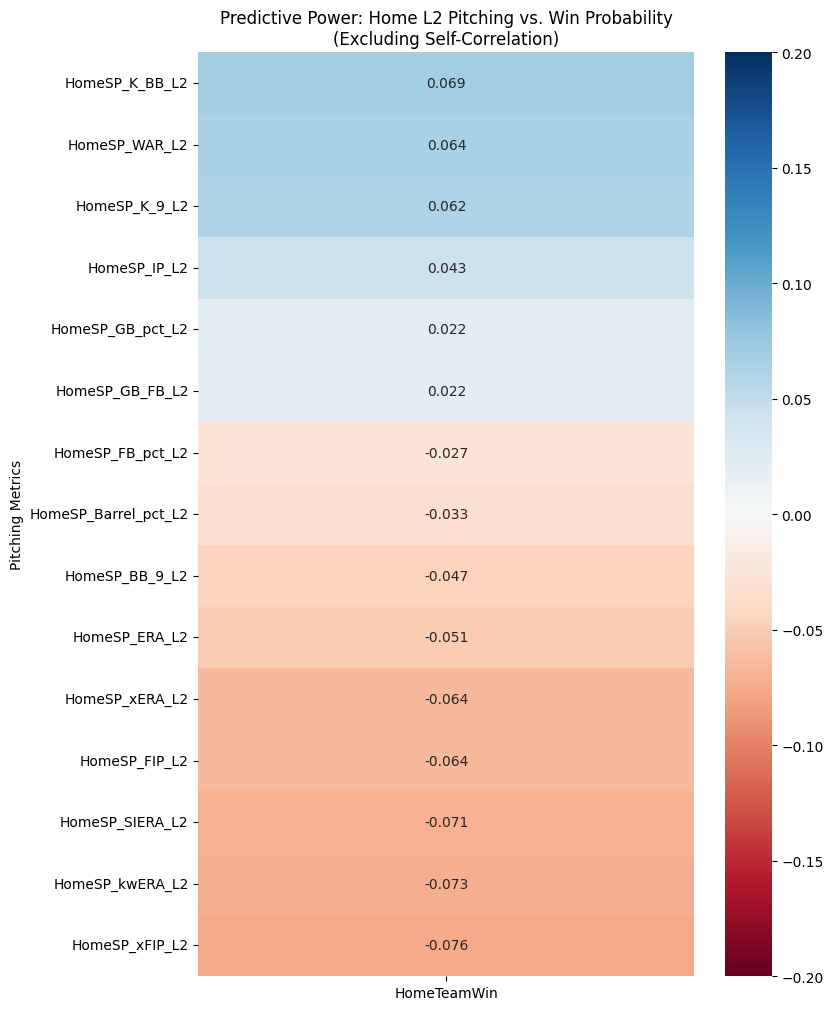

In [16]:
# Correlation of Home pitching over L2 frame and HomeTeamWin

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_refined_pitching_correlation(df):
    # Identify L2 Pitching Columns
    pitching_cols = [col for col in df.columns if 
                     (col.startswith('HomeSP') or col.startswith('HomeBP')) 
                     and col.endswith('L2')]
    
    # Calculate correlation with the target
    correlations = df[pitching_cols + ['HomeTeamWin']].corr()['HomeTeamWin']
    
    correlations = correlations.drop(labels=['HomeTeamWin']).sort_values(ascending=False)
    
    corr_df = pd.DataFrame(correlations)

    # 4. Plotting
    plt.figure(figsize=(8, 12))
    sns.heatmap(corr_df, annot=True, cmap='RdBu', center=0, fmt=".3f",
                vmin=-0.2, vmax=0.2) 
    
    plt.title("Predictive Power: Home L2 Pitching vs. Win Probability\n(Excluding Self-Correlation)")
    plt.ylabel("Pitching Metrics")
    plt.show()

plot_refined_pitching_correlation(GameBoxScores)

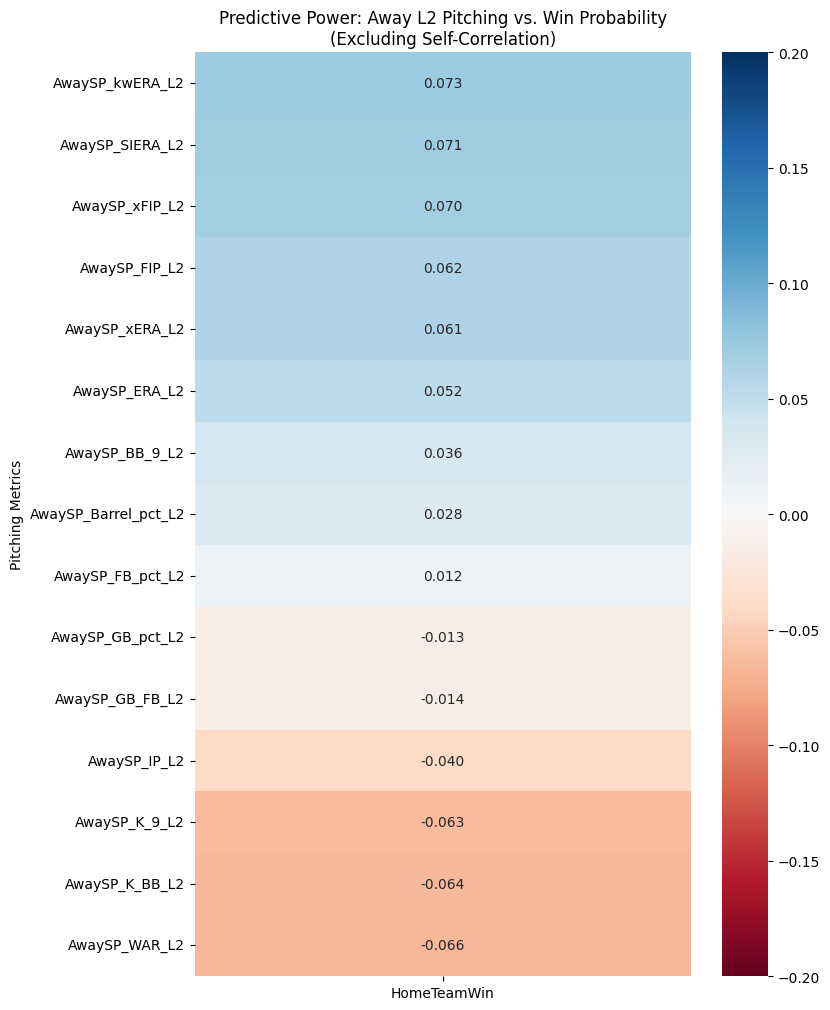

In [17]:
# Correlation of Away pitching over L2 frame and HomeTeamWin

def plot_refined_pitching_correlation1(df):
    # Identify L2 Pitching Columns
    pitching_cols = [col for col in df.columns if 
                     (col.startswith('AwaySP') or col.startswith('AwayBP')) 
                     and col.endswith('L2')]
    
    # Calculate correlation with the target
    correlations = df[pitching_cols + ['HomeTeamWin']].corr()['HomeTeamWin']
    
    correlations = correlations.drop(labels=['HomeTeamWin']).sort_values(ascending=False)
    
    corr_df = pd.DataFrame(correlations)

    # 4. Plotting
    plt.figure(figsize=(8, 12))
    sns.heatmap(corr_df, annot=True, cmap='RdBu', center=0, fmt=".3f",
                vmin=-0.2, vmax=0.2) 
    
    plt.title("Predictive Power: Away L2 Pitching vs. Win Probability\n(Excluding Self-Correlation)")
    plt.ylabel("Pitching Metrics")
    plt.show()

plot_refined_pitching_correlation1(GameBoxScores)

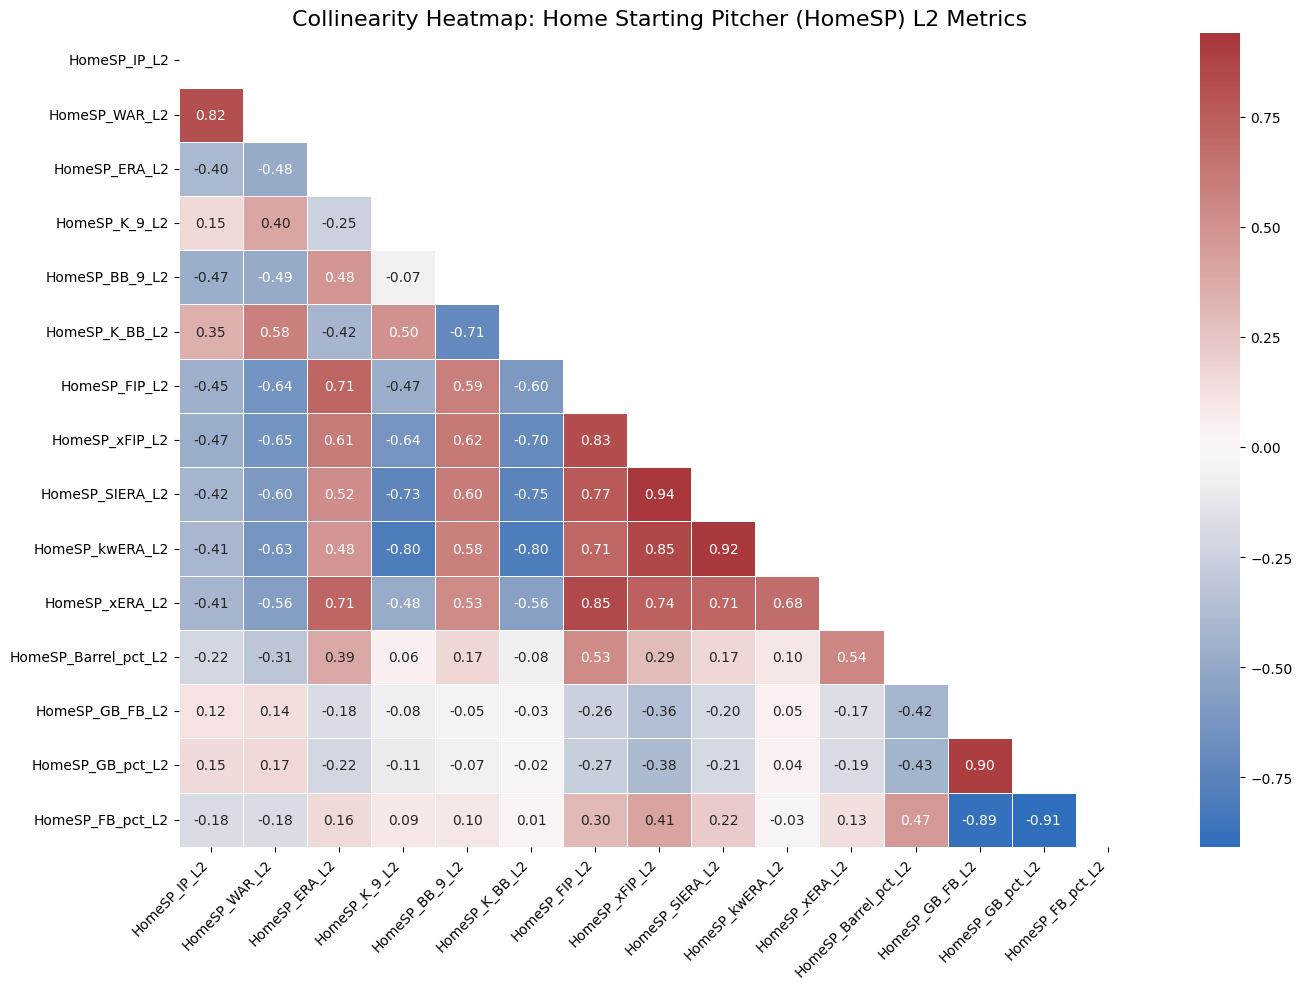

In [18]:
# Correlation matrix visual for starting pitcher fields to investigate colinearity.

def plot_homesp_l2_collinearity(df):
    # Filter for Home Starting Pitcher L2 stats
    homesp_l2_cols = [c for c in df.columns if c.startswith('HomeSP_') and c.endswith('_L2')]

    # Calculate the Correlation Matrix
    corr_matrix = df[homesp_l2_cols].corr()

    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask, 
                annot=True,
                cmap='vlag', 
                center=0, 
                fmt=".2f",
                linewidths=.5)
    
    plt.title("Collinearity Heatmap: Home Starting Pitcher (HomeSP) L2 Metrics", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_homesp_l2_collinearity(GameBoxScores)

In [19]:
print(GameBoxScores.columns.tolist())

['GAMEID', 'Date', 'AwayTeam', 'HomeTeam', 'AwayScore', 'HomeScore', 'HomeTeamWin', 'AwayTeamWin', 'Year', 'AwayPitcherIDFirstYear', 'HomePitcherIDFirstYear', 'AwayFieldingRunsC', 'HomeFieldingRunsC', 'AwayPitcherHand', 'HomePitcherHand', 'HomeSP_IP_L2', 'HomeSP_WAR_L2', 'HomeSP_ERA_L2', 'HomeSP_K_9_L2', 'HomeSP_BB_9_L2', 'HomeSP_K_BB_L2', 'HomeSP_FIP_L2', 'HomeSP_xFIP_L2', 'HomeSP_SIERA_L2', 'HomeSP_kwERA_L2', 'HomeSP_xERA_L2', 'HomeSP_Barrel_pct_L2', 'HomeSP_GB_FB_L2', 'HomeSP_GB_pct_L2', 'HomeSP_FB_pct_L2', 'AwaySP_IP_L2', 'AwaySP_WAR_L2', 'AwaySP_ERA_L2', 'AwaySP_K_9_L2', 'AwaySP_BB_9_L2', 'AwaySP_K_BB_L2', 'AwaySP_FIP_L2', 'AwaySP_xFIP_L2', 'AwaySP_SIERA_L2', 'AwaySP_kwERA_L2', 'AwaySP_xERA_L2', 'AwaySP_Barrel_pct_L2', 'AwaySP_GB_FB_L2', 'AwaySP_GB_pct_L2', 'AwaySP_FB_pct_L2', 'HomeSP_IP_L5M', 'HomeSP_ERA_L5M', 'HomeSP_DRA_L5M', 'HomeSP_Kpct_L5M', 'HomeSP_BBpct_L5M', 'AwaySP_IP_L5M', 'AwaySP_ERA_L5M', 'AwaySP_DRA_L5M', 'AwaySP_Kpct_L5M', 'AwaySP_BBpct_L5M', 'HomeBP_IP_L3M', 'HomeB

In [21]:
# Compute delta values

delta_list = ['HomeFieldingRunsC', 'HomeSP_IP_L2', 'HomeSP_WAR_L2', 'HomeSP_ERA_L2', 'HomeSP_K_9_L2', 'HomeSP_BB_9_L2', 'HomeSP_K_BB_L2', 'HomeSP_FIP_L2', 'HomeSP_xFIP_L2', 'HomeSP_SIERA_L2', 'HomeSP_kwERA_L2',
              'HomeSP_xERA_L2', 'HomeSP_Barrel_pct_L2', 'HomeSP_GB_FB_L2', 'HomeSP_GB_pct_L2', 'HomeSP_FB_pct_L2', 'HomeSP_IP_L5M', 'HomeSP_ERA_L5M', 'HomeSP_DRA_L5M', 'HomeSP_Kpct_L5M', 'HomeSP_BBpct_L5M',
              'HomeBP_IP_L3M', 'HomeBP_ERA_L3M', 'HomeBP_SO9_L3M', 'HomeBP_BB9_L3M', 'HomeSP_IP_L4A', 'HomeSP_ERA_L4A', 'HomeSP_SO9_L4A', 'HomeSP_BB9_L4A', 'HomeSP_K_BB_L4A', 'HomeSP_FIP_L4A', 'HomeSP_xFIP_L4A',
              'HomeSP_SIERA_L4A', 'HomeSP_xERA_L4A', 'HomeSP_Barrel_pct_L4A', 'HomeSP_GB_FB_L4A', 'HomeSP_GB_pct_L4A', 'HomeSP_FB_pct_L4A', 'HomeB1_PA_L2', 'HomeB1_WAR_L2', 'HomeB1_BSR_L2', 'HomeB1_BB_pct_L2',
              'HomeB1_K_pct_L2', 'HomeB1_BB_K_L2', 'HomeB1_OPS_L2', 'HomeB1_GB_FB_L2', 'HomeB1_GB_pct_L2', 'HomeB1_FB_pct_L2', 'HomeB1_wOBA_L2', 'HomeB1_wRC_plus_L2', 'HomeB1_xwOBA_L2', 'HomeB1_xAVG_L2', 'HomeB1_xSLG_L2',
              'HomeB1_LA_L2', 'HomeB1_Barrel_pct_L2', 'HomeB1_maxEV_L2', 'HomeB1_EV90_L2', 'HomeB2_PA_L2', 'HomeB2_WAR_L2', 'HomeB2_BSR_L2', 'HomeB2_BB_pct_L2', 'HomeB2_K_pct_L2', 'HomeB2_BB_K_L2', 'HomeB2_OPS_L2',
              'HomeB2_GB_FB_L2', 'HomeB2_GB_pct_L2', 'HomeB2_FB_pct_L2', 'HomeB2_wOBA_L2', 'HomeB2_wRC_plus_L2', 'HomeB2_xwOBA_L2', 'HomeB2_xAVG_L2', 'HomeB2_xSLG_L2', 'HomeB2_LA_L2', 'HomeB2_Barrel_pct_L2', 
              'HomeB2_maxEV_L2', 'HomeB2_EV90_L2', 'HomeB3_PA_L2', 'HomeB3_WAR_L2', 'HomeB3_BSR_L2', 'HomeB3_BB_pct_L2', 'HomeB3_K_pct_L2', 'HomeB3_BB_K_L2', 'HomeB3_OPS_L2', 'HomeB3_GB_FB_L2', 'HomeB3_GB_pct_L2',
              'HomeB3_FB_pct_L2', 'HomeB3_wOBA_L2', 'HomeB3_wRC_plus_L2', 'HomeB3_xwOBA_L2', 'HomeB3_xAVG_L2', 'HomeB3_xSLG_L2', 'HomeB3_LA_L2', 'HomeB3_Barrel_pct_L2', 'HomeB3_maxEV_L2', 'HomeB3_EV90_L2', 'HomeB4_PA_L2',
              'HomeB4_WAR_L2', 'HomeB4_BSR_L2', 'HomeB4_BB_pct_L2', 'HomeB4_K_pct_L2', 'HomeB4_BB_K_L2', 'HomeB4_OPS_L2', 'HomeB4_GB_FB_L2', 'HomeB4_GB_pct_L2', 'HomeB4_FB_pct_L2', 'HomeB4_wOBA_L2', 'HomeB4_wRC_plus_L2',
              'HomeB4_xwOBA_L2', 'HomeB4_xAVG_L2', 'HomeB4_xSLG_L2', 'HomeB4_LA_L2', 'HomeB4_Barrel_pct_L2', 'HomeB4_maxEV_L2', 'HomeB4_EV90_L2', 'HomeB5_PA_L2', 'HomeB5_WAR_L2', 'HomeB5_BSR_L2', 'HomeB5_BB_pct_L2',
              'HomeB5_K_pct_L2', 'HomeB5_BB_K_L2', 'HomeB5_OPS_L2', 'HomeB5_GB_FB_L2', 'HomeB5_GB_pct_L2', 'HomeB5_FB_pct_L2', 'HomeB5_wOBA_L2', 'HomeB5_wRC_plus_L2', 'HomeB5_xwOBA_L2', 'HomeB5_xAVG_L2', 'HomeB5_xSLG_L2',
              'HomeB5_LA_L2', 'HomeB5_Barrel_pct_L2', 'HomeB5_maxEV_L2', 'HomeB5_EV90_L2', 'HomeB6_PA_L2', 'HomeB6_WAR_L2', 'HomeB6_BSR_L2', 'HomeB6_BB_pct_L2', 'HomeB6_K_pct_L2', 'HomeB6_BB_K_L2', 'HomeB6_OPS_L2',
              'HomeB6_GB_FB_L2', 'HomeB6_GB_pct_L2', 'HomeB6_FB_pct_L2', 'HomeB6_wOBA_L2', 'HomeB6_wRC_plus_L2', 'HomeB6_xwOBA_L2', 'HomeB6_xAVG_L2', 'HomeB6_xSLG_L2', 'HomeB6_LA_L2', 'HomeB6_Barrel_pct_L2', 
              'HomeB6_maxEV_L2', 'HomeB6_EV90_L2', 'HomeB7_PA_L2', 'HomeB7_WAR_L2', 'HomeB7_BSR_L2', 'HomeB7_BB_pct_L2', 'HomeB7_K_pct_L2', 'HomeB7_BB_K_L2', 'HomeB7_OPS_L2', 'HomeB7_GB_FB_L2', 'HomeB7_GB_pct_L2',
              'HomeB7_FB_pct_L2', 'HomeB7_wOBA_L2', 'HomeB7_wRC_plus_L2', 'HomeB7_xwOBA_L2', 'HomeB7_xAVG_L2', 'HomeB7_xSLG_L2', 'HomeB7_LA_L2', 'HomeB7_Barrel_pct_L2', 'HomeB7_maxEV_L2', 'HomeB7_EV90_L2',
              'HomeB8_PA_L2', 'HomeB8_WAR_L2', 'HomeB8_BSR_L2', 'HomeB8_BB_pct_L2', 'HomeB8_K_pct_L2', 'HomeB8_BB_K_L2', 'HomeB8_OPS_L2', 'HomeB8_GB_FB_L2', 'HomeB8_GB_pct_L2', 'HomeB8_FB_pct_L2', 'HomeB8_wOBA_L2',
              'HomeB8_wRC_plus_L2', 'HomeB8_xwOBA_L2', 'HomeB8_xAVG_L2', 'HomeB8_xSLG_L2', 'HomeB8_LA_L2', 'HomeB8_Barrel_pct_L2', 'HomeB8_maxEV_L2', 'HomeB8_EV90_L2', 'HomeB9_PA_L2', 'HomeB9_WAR_L2', 'HomeB9_BSR_L2',
              'HomeB9_BB_pct_L2', 'HomeB9_K_pct_L2', 'HomeB9_BB_K_L2', 'HomeB9_OPS_L2', 'HomeB9_GB_FB_L2', 'HomeB9_GB_pct_L2', 'HomeB9_FB_pct_L2', 'HomeB9_wOBA_L2', 'HomeB9_wRC_plus_L2', 'HomeB9_xwOBA_L2', 
              'HomeB9_xAVG_L2', 'HomeB9_xSLG_L2', 'HomeB9_LA_L2', 'HomeB9_Barrel_pct_L2', 'HomeB9_maxEV_L2', 'HomeB9_EV90_L2', 'HomeTeamWinsL162', 'HomeTeamWinsL50', 'HomeTeamWinsL10', 'HomeTeamRunsScoredL10',
              'HomeTeamRunsAllowedL10', 'HomeTeamRunsScoredL100', 'HomeTeamRunsAllowedL100', 'HomeTeamAvgOutTotalL3', 'Home_Team_PA_L10A_Avg', 'Home_Team_AVG_L10A_Avg', 'Home_Team_BB_pct_L10A_Avg', 
              'Home_Team_K_pct_L10A_Avg', 'Home_Team_BB_K_L10A_Avg', 'Home_Team_OBP_L10A_Avg', 'Home_Team_OPS_L10A_Avg', 'Home_Team_GB_FB_L10A_Avg', 'Home_Team_wOBA_L10A_Avg', 'Home_Team_wRC_plus_L10A_Avg',
              'Home_Team_xwOBA_L10A_Avg', 'Home_Team_xAVG_L10A_Avg', 'Home_Team_xSLG_L10A_Avg', 'Home_Team_Barrel_pct_L10A_Avg', 'Home_Top_PA_L5M_Avg', 'Home_Middle_PA_L5M_Avg', 'Home_Bottom_PA_L5M_Avg', 
              'Home_Top_OBP_L5M_Avg', 'Home_Middle_OBP_L5M_Avg', 'Home_Bottom_OBP_L5M_Avg', 'Home_Top_OPS_L5M_Avg', 'Home_Middle_OPS_L5M_Avg', 'Home_Bottom_OPS_L5M_Avg', 'Home_Top_DRC_plus_L5M_Avg',
              'Home_Middle_DRC_plus_L5M_Avg', 'Home_Bottom_DRC_plus_L5M_Avg', 'Home_Top_Kpct_L5M_Avg', 'Home_Middle_Kpct_L5M_Avg', 'Home_Bottom_Kpct_L5M_Avg', 'Home_Top_BBpct_L5M_Avg', 'Home_Middle_BBpct_L5M_Avg',
              'Home_Bottom_BBpct_L5M_Avg', 'Home_Top_PA_L5M_P_Avg', 'Home_Middle_PA_L5M_P_Avg', 'Home_Bottom_PA_L5M_P_Avg', 'Home_Top_OBP_L5M_P_Avg', 'Home_Middle_OBP_L5M_P_Avg', 'Home_Bottom_OBP_L5M_P_Avg',
              'Home_Top_OPS_L5M_P_Avg', 'Home_Middle_OPS_L5M_P_Avg', 'Home_Bottom_OPS_L5M_P_Avg', 'Home_Top_DRC_plus_L5M_P_Avg', 'Home_Middle_DRC_plus_L5M_P_Avg', 'Home_Bottom_DRC_plus_L5M_P_Avg', 
              'Home_Top_Kpct_L5M_P_Avg', 'Home_Middle_Kpct_L5M_P_Avg', 'Home_Bottom_Kpct_L5M_P_Avg', 'Home_Top_BBpct_L5M_P_Avg', 'Home_Middle_BBpct_L5M_P_Avg', 'Home_Bottom_BBpct_L5M_P_Avg', 'HomeFirstYearCount',
              'Home_Infield_Defense_L5M', 'Home_Outfield_Defense_L5M']

for col in delta_list:
    away_col = col.replace("Home", "Away")
    delta_col = col.replace("Home", "Delta") 
    
    if col in GameBoxScores.columns and away_col in GameBoxScores.columns:
        GameBoxScores[delta_col] = GameBoxScores[col] - GameBoxScores[away_col]
    else:
        print("MAJOR ERROR")

/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/1796049268.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[delta_col] = GameBoxScores[col] - GameBoxScores[away_col]
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/1796049268.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  GameBoxScores[delta_col] = GameBoxScores[col] - GameBoxScores[away_col]
/var/folders/4k/3pfkn1jn039bp8wy8410pn3m0000gn/T/ipykernel_50637/1796049268.py:36: PerformanceWarning: DataFrame is highly fragmente

In [22]:
col_removal = []
for col in delta_list:
    away_col = col.replace("Home", "Away")
    delta_col = col.replace("Home", "Delta") 
    
    col_removal.append(away_col)
    col_removal.append(col)
    
GameBoxScores.drop(columns=col_removal, inplace=True)

In [24]:
GameBoxScores.to_csv("AltGBS.csv", index=False)

In [26]:
# XGBoost feature importance

from xgboost import XGBClassifier

features = [
'AwayPitcherIDFirstYear', 'HomePitcherIDFirstYear', 'AwayPitcherHand', 'HomePitcherHand', 'ParkFactor', 'DeltaFieldingRunsC', 'DeltaSP_IP_L2', 'DeltaSP_WAR_L2', 'DeltaSP_ERA_L2', 'DeltaSP_K_9_L2',
'DeltaSP_BB_9_L2', 'DeltaSP_K_BB_L2', 'DeltaSP_FIP_L2', 'DeltaSP_xFIP_L2', 'DeltaSP_SIERA_L2', 'DeltaSP_kwERA_L2', 'DeltaSP_xERA_L2', 'DeltaSP_Barrel_pct_L2', 'DeltaSP_GB_FB_L2', 'DeltaSP_GB_pct_L2',
'DeltaSP_FB_pct_L2', 'DeltaSP_IP_L5M', 'DeltaSP_ERA_L5M', 'DeltaSP_DRA_L5M', 'DeltaSP_Kpct_L5M', 'DeltaSP_BBpct_L5M', 'DeltaBP_IP_L3M', 'DeltaBP_ERA_L3M', 'DeltaBP_SO9_L3M', 'DeltaBP_BB9_L3M',
'DeltaSP_IP_L4A', 'DeltaSP_ERA_L4A', 'DeltaSP_SO9_L4A', 'DeltaSP_BB9_L4A', 'DeltaSP_K_BB_L4A', 'DeltaSP_FIP_L4A', 'DeltaSP_xFIP_L4A', 'DeltaSP_SIERA_L4A', 'DeltaSP_xERA_L4A', 'DeltaSP_Barrel_pct_L4A',
'DeltaSP_GB_FB_L4A', 'DeltaSP_GB_pct_L4A', 'DeltaSP_FB_pct_L4A', 'DeltaB1_PA_L2', 'DeltaB1_WAR_L2', 'DeltaB1_BSR_L2', 'DeltaB1_BB_pct_L2', 'DeltaB1_K_pct_L2', 'DeltaB1_BB_K_L2', 'DeltaB1_OPS_L2',
'DeltaB1_GB_FB_L2', 'DeltaB1_GB_pct_L2', 'DeltaB1_FB_pct_L2', 'DeltaB1_wOBA_L2', 'DeltaB1_wRC_plus_L2', 'DeltaB1_xwOBA_L2', 'DeltaB1_xAVG_L2', 'DeltaB1_xSLG_L2', 'DeltaB1_LA_L2', 'DeltaB1_Barrel_pct_L2',
'DeltaB1_maxEV_L2', 'DeltaB1_EV90_L2', 'DeltaB2_PA_L2', 'DeltaB2_WAR_L2', 'DeltaB2_BSR_L2', 'DeltaB2_BB_pct_L2', 'DeltaB2_K_pct_L2', 'DeltaB2_BB_K_L2', 'DeltaB2_OPS_L2', 'DeltaB2_GB_FB_L2',
'DeltaB2_GB_pct_L2', 'DeltaB2_FB_pct_L2', 'DeltaB2_wOBA_L2', 'DeltaB2_wRC_plus_L2', 'DeltaB2_xwOBA_L2', 'DeltaB2_xAVG_L2', 'DeltaB2_xSLG_L2', 'DeltaB2_LA_L2', 'DeltaB2_Barrel_pct_L2', 
'DeltaB2_maxEV_L2', 'DeltaB2_EV90_L2', 'DeltaB3_PA_L2', 'DeltaB3_WAR_L2', 'DeltaB3_BSR_L2', 'DeltaB3_BB_pct_L2', 'DeltaB3_K_pct_L2', 'DeltaB3_BB_K_L2', 'DeltaB3_OPS_L2', 'DeltaB3_GB_FB_L2',
'DeltaB3_GB_pct_L2', 'DeltaB3_FB_pct_L2', 'DeltaB3_wOBA_L2', 'DeltaB3_wRC_plus_L2', 'DeltaB3_xwOBA_L2', 'DeltaB3_xAVG_L2', 'DeltaB3_xSLG_L2', 'DeltaB3_LA_L2', 'DeltaB3_Barrel_pct_L2',
'DeltaB3_maxEV_L2', 'DeltaB3_EV90_L2', 'DeltaB4_PA_L2', 'DeltaB4_WAR_L2', 'DeltaB4_BSR_L2', 'DeltaB4_BB_pct_L2', 'DeltaB4_K_pct_L2', 'DeltaB4_BB_K_L2', 'DeltaB4_OPS_L2', 'DeltaB4_GB_FB_L2',
'DeltaB4_GB_pct_L2', 'DeltaB4_FB_pct_L2', 'DeltaB4_wOBA_L2', 'DeltaB4_wRC_plus_L2', 'DeltaB4_xwOBA_L2', 'DeltaB4_xAVG_L2', 'DeltaB4_xSLG_L2', 'DeltaB4_LA_L2', 'DeltaB4_Barrel_pct_L2',
'DeltaB4_maxEV_L2', 'DeltaB4_EV90_L2', 'DeltaB5_PA_L2', 'DeltaB5_WAR_L2', 'DeltaB5_BSR_L2', 'DeltaB5_BB_pct_L2', 'DeltaB5_K_pct_L2', 'DeltaB5_BB_K_L2', 'DeltaB5_OPS_L2', 'DeltaB5_GB_FB_L2',
'DeltaB5_GB_pct_L2', 'DeltaB5_FB_pct_L2', 'DeltaB5_wOBA_L2', 'DeltaB5_wRC_plus_L2', 'DeltaB5_xwOBA_L2', 'DeltaB5_xAVG_L2', 'DeltaB5_xSLG_L2', 'DeltaB5_LA_L2', 'DeltaB5_Barrel_pct_L2',
'DeltaB5_maxEV_L2', 'DeltaB5_EV90_L2', 'DeltaB6_PA_L2', 'DeltaB6_WAR_L2', 'DeltaB6_BSR_L2', 'DeltaB6_BB_pct_L2', 'DeltaB6_K_pct_L2', 'DeltaB6_BB_K_L2', 'DeltaB6_OPS_L2', 'DeltaB6_GB_FB_L2',
'DeltaB6_GB_pct_L2', 'DeltaB6_FB_pct_L2', 'DeltaB6_wOBA_L2', 'DeltaB6_wRC_plus_L2', 'DeltaB6_xwOBA_L2', 'DeltaB6_xAVG_L2', 'DeltaB6_xSLG_L2', 'DeltaB6_LA_L2', 'DeltaB6_Barrel_pct_L2',
'DeltaB6_maxEV_L2', 'DeltaB6_EV90_L2', 'DeltaB7_PA_L2', 'DeltaB7_WAR_L2', 'DeltaB7_BSR_L2', 'DeltaB7_BB_pct_L2', 'DeltaB7_K_pct_L2', 'DeltaB7_BB_K_L2', 'DeltaB7_OPS_L2', 'DeltaB7_GB_FB_L2',
'DeltaB7_GB_pct_L2', 'DeltaB7_FB_pct_L2', 'DeltaB7_wOBA_L2', 'DeltaB7_wRC_plus_L2', 'DeltaB7_xwOBA_L2', 'DeltaB7_xAVG_L2', 'DeltaB7_xSLG_L2', 'DeltaB7_LA_L2', 'DeltaB7_Barrel_pct_L2',
'DeltaB7_maxEV_L2', 'DeltaB7_EV90_L2', 'DeltaB8_PA_L2', 'DeltaB8_WAR_L2', 'DeltaB8_BSR_L2', 'DeltaB8_BB_pct_L2', 'DeltaB8_K_pct_L2', 'DeltaB8_BB_K_L2', 'DeltaB8_OPS_L2', 'DeltaB8_GB_FB_L2',
'DeltaB8_GB_pct_L2', 'DeltaB8_FB_pct_L2', 'DeltaB8_wOBA_L2', 'DeltaB8_wRC_plus_L2', 'DeltaB8_xwOBA_L2', 'DeltaB8_xAVG_L2', 'DeltaB8_xSLG_L2', 'DeltaB8_LA_L2', 'DeltaB8_Barrel_pct_L2', 
'DeltaB8_maxEV_L2', 'DeltaB8_EV90_L2', 'DeltaB9_PA_L2', 'DeltaB9_WAR_L2', 'DeltaB9_BSR_L2', 'DeltaB9_BB_pct_L2', 'DeltaB9_K_pct_L2', 'DeltaB9_BB_K_L2', 'DeltaB9_OPS_L2', 'DeltaB9_GB_FB_L2',
'DeltaB9_GB_pct_L2', 'DeltaB9_FB_pct_L2', 'DeltaB9_wOBA_L2', 'DeltaB9_wRC_plus_L2', 'DeltaB9_xwOBA_L2', 'DeltaB9_xAVG_L2', 'DeltaB9_xSLG_L2', 'DeltaB9_LA_L2', 'DeltaB9_Barrel_pct_L2',
'DeltaB9_maxEV_L2', 'DeltaB9_EV90_L2', 'DeltaTeamWinsL162', 'DeltaTeamWinsL50', 'DeltaTeamWinsL10', 'DeltaTeamRunsScoredL10', 'DeltaTeamRunsAllowedL10', 'DeltaTeamRunsScoredL100', 
'DeltaTeamRunsAllowedL100', 'DeltaTeamAvgOutTotalL3', 'Delta_Team_PA_L10A_Avg', 'Delta_Team_AVG_L10A_Avg', 'Delta_Team_BB_pct_L10A_Avg', 'Delta_Team_K_pct_L10A_Avg', 'Delta_Team_BB_K_L10A_Avg',
'Delta_Team_OBP_L10A_Avg', 'Delta_Team_OPS_L10A_Avg', 'Delta_Team_GB_FB_L10A_Avg', 'Delta_Team_wOBA_L10A_Avg', 'Delta_Team_wRC_plus_L10A_Avg', 'Delta_Team_xwOBA_L10A_Avg', 'Delta_Team_xAVG_L10A_Avg',
'Delta_Team_xSLG_L10A_Avg', 'Delta_Team_Barrel_pct_L10A_Avg', 'Delta_Top_PA_L5M_Avg', 'Delta_Middle_PA_L5M_Avg', 'Delta_Bottom_PA_L5M_Avg', 'Delta_Top_OBP_L5M_Avg', 'Delta_Middle_OBP_L5M_Avg',
'Delta_Bottom_OBP_L5M_Avg', 'Delta_Top_OPS_L5M_Avg', 'Delta_Middle_OPS_L5M_Avg', 'Delta_Bottom_OPS_L5M_Avg', 'Delta_Top_DRC_plus_L5M_Avg', 'Delta_Middle_DRC_plus_L5M_Avg', 'Delta_Bottom_DRC_plus_L5M_Avg',
'Delta_Top_Kpct_L5M_Avg', 'Delta_Middle_Kpct_L5M_Avg', 'Delta_Bottom_Kpct_L5M_Avg', 'Delta_Top_BBpct_L5M_Avg', 'Delta_Middle_BBpct_L5M_Avg', 'Delta_Bottom_BBpct_L5M_Avg', 'Delta_Top_PA_L5M_P_Avg',
'Delta_Middle_PA_L5M_P_Avg', 'Delta_Bottom_PA_L5M_P_Avg', 'Delta_Top_OBP_L5M_P_Avg', 'Delta_Middle_OBP_L5M_P_Avg', 'Delta_Bottom_OBP_L5M_P_Avg', 'Delta_Top_OPS_L5M_P_Avg', 'Delta_Middle_OPS_L5M_P_Avg',
'Delta_Bottom_OPS_L5M_P_Avg', 'Delta_Top_DRC_plus_L5M_P_Avg', 'Delta_Middle_DRC_plus_L5M_P_Avg', 'Delta_Bottom_DRC_plus_L5M_P_Avg', 'Delta_Top_Kpct_L5M_P_Avg', 'Delta_Middle_Kpct_L5M_P_Avg', 
'Delta_Bottom_Kpct_L5M_P_Avg', 'Delta_Top_BBpct_L5M_P_Avg', 'Delta_Middle_BBpct_L5M_P_Avg', 'Delta_Bottom_BBpct_L5M_P_Avg', 'DeltaFirstYearCount', 'Delta_Infield_Defense_L5M', 'Delta_Outfield_Defense_L5M'
]
target = 'HomeTeamWin'

def run_xgboost_importance(df, feature_cols, target_col):
    X = pd.get_dummies(df[feature_cols], drop_first=True)
    y = df[target_col]
    
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        importance_type='gain' # 'gain' is usually more informative for baseball stats than 'weight'
    )
    
    print("Training XGBoost model on all features...")
    model.fit(X, y)
    
    # 3. Extract Feature Importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    return importance_df

importance_results = run_xgboost_importance(GameBoxScores, features, target)

# Display Top 50
print(importance_results.head(50))

Training XGBoost model on all features...
                             feature  importance
212                DeltaTeamWinsL162    0.029918
218         DeltaTeamRunsAllowedL100    0.012709
213                 DeltaTeamWinsL50    0.008665
11                   DeltaSP_xFIP_L2    0.006616
28                    DeltaSP_IP_L4A    0.004971
52               DeltaB1_wRC_plus_L2    0.004734
137                   DeltaB6_WAR_L2    0.004610
53                  DeltaB1_xwOBA_L2    0.004502
244    Delta_Middle_DRC_plus_L5M_Avg    0.004481
44                 DeltaB1_BB_pct_L2    0.004423
89                   DeltaB3_wOBA_L2    0.004422
21                   DeltaSP_DRA_L5M    0.004398
229     Delta_Team_wRC_plus_L10A_Avg    0.004367
242         Delta_Bottom_OPS_L5M_Avg    0.004336
90               DeltaB3_wRC_plus_L2    0.004320
270              DeltaFirstYearCount    0.004276
51                   DeltaB1_wOBA_L2    0.004272
92                   DeltaB3_xAVG_L2    0.004267
36                  DeltaSP

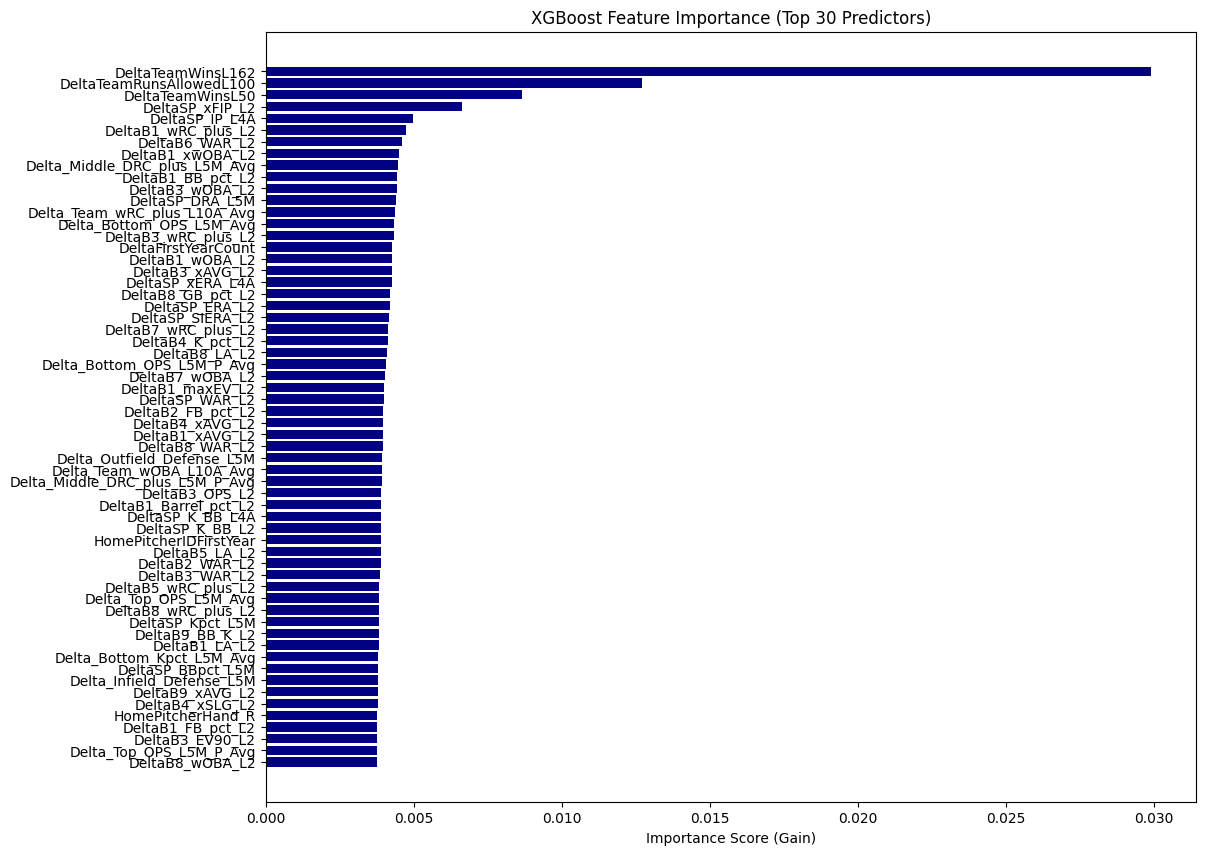

In [28]:
# Visualize the top 30
plt.figure(figsize=(12, 10))
top_30 = importance_results.head(60)
plt.barh(top_30['feature'], top_30['importance'], color='navy')
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Top 30 Predictors)")
plt.xlabel("Importance Score (Gain)")
plt.show()

In [29]:
def rank_by_subgroups(importance_df):
    subgroups = {
        'Pitcher L2': ['SP_', '_L2'],
        'Hitter L2': ['B1_', 'B2_', 'B3_', 'B4_', 'B5_', 'B6_', 'B7_', 'B8_', 'B9_', '_L2'],
        'Hitter L5M & L5MP': ['_PA_L5M', '_OBP_L5M', '_OPS_L5M', '_DRC_plus_L5M'],
        'Pitcher L5M': ['SP_', '_L5M'],
        'Hitter L10A': ['_L10A_Avg'],
        'Pitcher L4A': ['SP_', '_L4A']
    }
    
    rankings = {}

    for name, patterns in subgroups.items():
        mask = importance_df['feature'].apply(lambda x: all(p in x for p in patterns))
            
        group_df = importance_df[mask].copy()
        
        # Assign a relative rank within the group
        group_df['within_group_rank'] = range(1, len(group_df) + 1)
        rankings[name] = group_df[['within_group_rank', 'feature', 'importance']]

    return rankings

group_rankings = rank_by_subgroups(importance_results)

for category, data in group_rankings.items():
    print(f"\n--- {category} Importance Ranking ---")
    print(data.head(35).to_string(index=False))


--- Pitcher L2 Importance Ranking ---
 within_group_rank               feature  importance
                 1       DeltaSP_xFIP_L2    0.006616
                 2        DeltaSP_ERA_L2    0.004193
                 3      DeltaSP_SIERA_L2    0.004154
                 4        DeltaSP_WAR_L2    0.003995
                 5       DeltaSP_K_BB_L2    0.003887
                 6        DeltaSP_K_9_L2    0.003736
                 7      DeltaSP_kwERA_L2    0.003670
                 8     DeltaSP_FB_pct_L2    0.003578
                 9       DeltaSP_xERA_L2    0.003513
                10        DeltaSP_FIP_L2    0.003445
                11     DeltaSP_GB_pct_L2    0.003226
                12       DeltaSP_BB_9_L2    0.003200
                13         DeltaSP_IP_L2    0.003170
                14 DeltaSP_Barrel_pct_L2    0.003043
                15      DeltaSP_GB_FB_L2    0.002626

--- Hitter L2 Importance Ranking ---
Empty DataFrame
Columns: [within_group_rank, feature, importance]
Index: []

In [30]:
def rank_by_subgroups_fixed(importance_df):
    rankings = {}

    hitter_l2_mask = (importance_df['feature'].str.contains(r'B[1-9]_') & 
                      importance_df['feature'].str.endswith('_L2'))
    rankings['Hitter L2'] = importance_df[hitter_l2_mask].copy()

    hitter_l5m_mask = (importance_df['feature'].str.contains(r'Top_|Middle_|Bottom_') & 
                       importance_df['feature'].str.contains('L5M'))
    rankings['Hitter L5M & L5MP'] = importance_df[hitter_l5m_mask].copy()

    for name in rankings:
        rankings[name] = rankings[name].sort_values('importance', ascending=False)
        rankings[name]['within_group_rank'] = range(1, len(rankings[name]) + 1)

    return rankings

hitter_rankings = rank_by_subgroups_fixed(importance_results)
for cat, data in hitter_rankings.items():
    print(f"\n--- {cat} Importance Ranking ---")
    print(data.head(200)[['within_group_rank', 'feature', 'importance']].to_string(index=False))


--- Hitter L2 Importance Ranking ---
 within_group_rank               feature  importance
                 1   DeltaB1_wRC_plus_L2    0.004734
                 2        DeltaB6_WAR_L2    0.004610
                 3      DeltaB1_xwOBA_L2    0.004502
                 4     DeltaB1_BB_pct_L2    0.004423
                 5       DeltaB3_wOBA_L2    0.004422
                 6   DeltaB3_wRC_plus_L2    0.004320
                 7       DeltaB1_wOBA_L2    0.004272
                 8       DeltaB3_xAVG_L2    0.004267
                 9     DeltaB8_GB_pct_L2    0.004212
                10   DeltaB7_wRC_plus_L2    0.004128
                11      DeltaB4_K_pct_L2    0.004115
                12         DeltaB8_LA_L2    0.004084
                13       DeltaB7_wOBA_L2    0.004015
                14      DeltaB1_maxEV_L2    0.003995
                15     DeltaB2_FB_pct_L2    0.003978
                16       DeltaB4_xAVG_L2    0.003971
                17       DeltaB1_xAVG_L2    0.003971
        

In [31]:
win_model_cols = ['GAMEID', 'Date', 'AwayTeam', 'HomeTeam', 'AwayScore', 'HomeScore', 'HomeTeamWin', 'AwayTeamWin', 'Year',
    'DeltaTeamWinsL162', 'DeltaTeamWinsL50', 'DeltaTeamRunsScoredL100', 'DeltaTeamRunsAllowedL100', 
    'DeltaFirstYearCount', 'HomePitcherIDFirstYear', 'AwayPitcherIDFirstYear', 'Delta_Infield_Defense_L5M', 
    'Delta_Outfield_Defense_L5M', 'DeltaFieldingRunsC', 'DeltaSP_xFIP_L2', 'DeltaSP_SIERA_L2', 
    'DeltaSP_ERA_L2', 'DeltaSP_WAR_L2', 'DeltaSP_K_BB_L2', 'DeltaSP_GB_pct_L2', 'DeltaSP_DRA_L5M', 
    'DeltaSP_Kpct_L5M', 'DeltaSP_BBpct_L5M', 'DeltaSP_IP_L5M', 'DeltaSP_IP_L4A', 'DeltaSP_xERA_L4A', 
    'DeltaSP_Barrel_pct_L4A', 'DeltaSP_K_BB_L4A', 'Delta_Team_wRC_plus_L10A_Avg', 'Delta_Team_PA_L10A_Avg', 
    'Delta_Team_xAVG_L10A_Avg', 'Delta_Team_xSLG_L10A_Avg', 'Delta_Team_BB_K_L10A_Avg', 
    'Delta_Top_DRC_plus_L5M_Avg', 'Delta_Middle_DRC_plus_L5M_Avg', 'Delta_Bottom_DRC_plus_L5M_Avg', 
    'Delta_Top_OPS_L5M_Avg', 'Delta_Middle_OPS_L5M_Avg', 'Delta_Bottom_OPS_L5M_Avg', 
    'Delta_Top_OPS_L5M_P_Avg', 'Delta_Middle_OPS_L5M_P_Avg', 'Delta_Bottom_OPS_L5M_P_Avg', 
    'Delta_Top_Kpct_L5M_Avg', 'Delta_Middle_Kpct_L5M_Avg', 'Delta_Bottom_Kpct_L5M_Avg', 
    'Delta_Top_BBpct_L5M_P_Avg', 'Delta_Middle_BBpct_L5M_P_Avg', 'Delta_Bottom_BBpct_L5M_P_Avg', 
    'DeltaB1_wRC_plus_L2', 'DeltaB2_wRC_plus_L2', 'DeltaB3_wRC_plus_L2', 'DeltaB4_wRC_plus_L2', 
    'DeltaB5_wRC_plus_L2', 'DeltaB6_wRC_plus_L2', 'DeltaB7_wRC_plus_L2', 'DeltaB8_wRC_plus_L2', 
    'DeltaB9_wRC_plus_L2', 'DeltaB1_xwOBA_L2', 'DeltaB2_xwOBA_L2', 'DeltaB3_xwOBA_L2', 
    'DeltaB4_xwOBA_L2', 'DeltaB5_xwOBA_L2', 'DeltaB6_xwOBA_L2', 'DeltaB7_xwOBA_L2', 
    'DeltaB8_xwOBA_L2', 'DeltaB9_xwOBA_L2', 'DeltaB1_BB_K_L2', 'DeltaB2_BB_K_L2', 
    'DeltaB3_BB_K_L2', 'DeltaB4_BB_K_L2', 'DeltaB5_BB_K_L2', 'DeltaB6_BB_K_L2', 
    'DeltaB7_BB_K_L2', 'DeltaB8_BB_K_L2', 'DeltaB9_BB_K_L2', 'DeltaB1_LA_L2', 
    'DeltaB2_LA_L2', 'DeltaB3_LA_L2', 'DeltaB4_LA_L2', 'DeltaB5_LA_L2', 'DeltaB6_LA_L2', 
    'DeltaB7_LA_L2', 'DeltaB8_LA_L2', 'DeltaB9_LA_L2', 'DeltaB1_BSR_L2', 'DeltaB2_BSR_L2', 
    'DeltaB3_BSR_L2', 'DeltaB4_BSR_L2', 'DeltaB5_BSR_L2', 'DeltaB6_BSR_L2', 'DeltaB7_BSR_L2', 
    'DeltaB8_BSR_L2', 'DeltaB9_BSR_L2', 'DeltaBP_SO9_L3M', 'DeltaBP_BB9_L3M', 'DeltaBP_ERA_L3M'
]

len(win_model_cols)

101

In [32]:
GameBoxScores_Model = GameBoxScores[win_model_cols].copy()

In [84]:
GameBoxScores_Model.to_csv("GBS_Model.csv", index=False)

---------
----------
------
-----
--------
-------

In [2]:
GBS_Models = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/GBS_Model.csv')
GBS_Models

,GAMEID,Date,AwayTeam,HomeTeam,AwayScore,HomeScore,HomeTeamWin,AwayTeamWin,Year,DeltaTeamWinsL162,...,DeltaB3_BSR_L2,DeltaB4_BSR_L2,DeltaB5_BSR_L2,DeltaB6_BSR_L2,DeltaB7_BSR_L2,DeltaB8_BSR_L2,DeltaB9_BSR_L2,DeltaBP_SO9_L3M,DeltaBP_BB9_L3M,DeltaBP_ERA_L3M
0,1,2018-03-29,NYY,TOR,6,1,0,1,2018,-15.0,...,0.243400,5.644200,-12.8442,-2.109300,-2.602600,9.475600,-0.880500,-2.184378,-0.534860,1.592203
1,2,2018-03-29,HOU,TEX,4,1,0,1,2018,-23.0,...,0.918900,-9.152500,-6.1101,-2.738500,-2.169800,1.490500,7.453100,-2.323342,0.495427,0.501419
2,3,2018-03-29,STL,NYM,4,9,1,0,2018,-13.0,...,-1.625500,-3.949500,-2.8930,-1.733800,2.194200,-4.735500,0.327600,-0.302129,1.393275,1.429524
3,4,2018-03-29,COL,ARI,2,8,1,0,2018,6.0,...,7.861800,-0.333400,5.8953,-7.463100,4.673400,15.949000,-0.779400,-0.091132,0.153348,-0.035633
4,5,2018-03-29,PHI,ATL,5,8,1,0,2018,6.0,...,1.381100,-3.035100,-4.0434,0.864200,5.622300,-0.299500,0.791100,-0.675361,0.833576,1.407952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17901,17902,2025-09-28,KCR,ATH,9,2,0,1,2025,-6.0,...,3.547900,8.394000,-2.1269,-1.813497,-3.642200,-1.351358,0.000000,0.970344,0.477842,0.251355
17902,17903,2025-09-28,STL,CHC,0,2,1,0,2025,12.0,...,3.002500,3.840700,-3.0801,0.000000,5.093800,5.914000,4.360558,-0.543749,-0.847485,0.437524
17903,17904,2025-09-28,ARI,SDP,4,12,1,0,2025,8.0,...,-7.406500,3.631858,5.5139,-3.473200,-3.207100,-9.667300,-0.877100,1.592836,-0.111420,-1.288854
17904,17905,2025-09-28,DET,BOS,3,4,1,0,2025,2.0,...,-3.646300,2.223300,-0.5931,-8.588000,-0.327900,6.909200,1.273200,1.205655,0.662216,-1.163103


In [3]:
BoxScores26 = pd.read_csv('/Users/owendrummond/Documents/python_projects/Capstone/BoxScores26_Final.csv')
BoxScores26

,game_pk,away_team_name,home_team_name,away_runs_total,home_runs_total,date
0,823244,New York Yankees,San Francisco Giants,7,0,2026-03-25
1,823649,Pittsburgh Pirates,New York Mets,7,11,2026-03-26
2,823812,Chicago White Sox,Milwaukee Brewers,2,14,2026-03-26
3,824704,Washington Nationals,Chicago Cubs,10,4,2026-03-26
4,824865,Minnesota Twins,Baltimore Orioles,1,2,2026-03-26
...,...,...,...,...,...,...
372,824688,Philadelphia Phillies,Chicago Cubs,2,7,2026-04-22
373,822913,Pittsburgh Pirates,Texas Rangers,8,4,2026-04-22
374,824367,San Diego Padres,Colorado Rockies,3,8,2026-04-22
375,825097,Chicago White Sox,Arizona Diamondbacks,7,11,2026-04-22


In [4]:
print(BoxScores26['home_team_name'].unique().tolist())

['San Francisco Giants', 'New York Mets', 'Milwaukee Brewers', 'Chicago Cubs', 'Baltimore Orioles', 'Cincinnati Reds', 'Houston Astros', 'San Diego Padres', 'St. Louis Cardinals', 'Philadelphia Phillies', 'Los Angeles Dodgers', 'Seattle Mariners', 'Toronto Blue Jays', 'Miami Marlins', 'Atlanta Braves', 'Kansas City Royals', 'Arizona Diamondbacks', 'Chicago White Sox', 'Washington Nationals', 'Detroit Tigers', 'New York Yankees', 'Boston Red Sox', 'Texas Rangers', 'Cleveland Guardians', 'Minnesota Twins', 'Colorado Rockies', 'Pittsburgh Pirates', 'Los Angeles Angels', 'Athletics', 'Tampa Bay Rays']


In [5]:
print(GBS_Models['HomeTeam'].unique().tolist())

['TOR', 'TEX', 'NYM', 'ARI', 'ATL', 'SDP', 'TBR', 'KCR', 'BAL', 'ATH', 'SEA', 'MIA', 'LAD', 'CIN', 'DET', 'LAA', 'HOU', 'MIL', 'PIT', 'NYY', 'SFG', 'STL', 'CHW', 'BOS', 'WAS', 'PHI', 'MIN', 'COL', 'CLE', 'CHC']


In [6]:
import pandas as pd
import numpy as np

# 1. Create the Correction Dictionary
team_map = {
    'Arizona Diamondbacks': 'ARI', 'Atlanta Braves': 'ATL', 'Baltimore Orioles': 'BAL',
    'Boston Red Sox': 'BOS', 'Chicago Cubs': 'CHC', 'Chicago White Sox': 'CHW',
    'Cincinnati Reds': 'CIN', 'Cleveland Guardians': 'CLE', 'Colorado Rockies': 'COL',
    'Detroit Tigers': 'DET', 'Houston Astros': 'HOU', 'Kansas City Royals': 'KCR',
    'Los Angeles Angels': 'LAA', 'Los Angeles Dodgers': 'LAD', 'Miami Marlins': 'MIA',
    'Milwaukee Brewers': 'MIL', 'Minnesota Twins': 'MIN', 'New York Mets': 'NYM',
    'New York Yankees': 'NYY', 'Athletics': 'ATH', 'Philadelphia Phillies': 'PHI',
    'Pittsburgh Pirates': 'PIT', 'San Diego Padres': 'SDP', 'San Francisco Giants': 'SFG',
    'Seattle Mariners': 'SEA', 'St. Louis Cardinals': 'STL', 'Tampa Bay Rays': 'TBR',
    'Texas Rangers': 'TEX', 'Toronto Blue Jays': 'TOR', 'Washington Nationals': 'WAS'
}

# 2. Apply Mapping
BoxScores26['away_team_name'] = BoxScores26['away_team_name'].map(team_map)
BoxScores26['home_team_name'] = BoxScores26['home_team_name'].map(team_map)

# 3. Feature Engineer Wins (1 for Win, 0 for Loss)
BoxScores26['HomeTeamWin'] = (BoxScores26['home_runs_total'] > BoxScores26['away_runs_total']).astype(int)
BoxScores26['AwayTeamWin'] = (BoxScores26['away_runs_total'] > BoxScores26['home_runs_total']).astype(int)

# 4. Standardize Columns for Union
# We rename BoxScores26 columns to match the GBS_Models schema
box_scores_subset = BoxScores26[[
    'date', 'away_team_name', 'home_team_name', 
    'away_runs_total', 'home_runs_total', 'HomeTeamWin', 'AwayTeamWin'
]].rename(columns={
    'date': 'Date',
    'away_team_name': 'AwayTeam',
    'home_team_name': 'HomeTeam',
    'away_runs_total': 'AwayScore',
    'home_runs_total': 'HomeScore'
})

# 5. Perform the Union
# Assumes GBS_Models is already loaded with the matching column names
master_wins_df = pd.concat([GBS_Models, box_scores_subset], ignore_index=True)

# Final Cleanup: Ensure Date is actual datetime objects
master_wins_df['Date'] = pd.to_datetime(master_wins_df['Date'])

print(f"Union Complete. Total games in master record: {len(master_wins_df)}")
print(master_wins_df.tail())

Union Complete. Total games in master record: 18283
       GAMEID       Date AwayTeam HomeTeam  AwayScore  HomeScore  HomeTeamWin  \
18278     NaN 2026-04-22      PHI      CHC          2          7            1   
18279     NaN 2026-04-22      PIT      TEX          8          4            0   
18280     NaN 2026-04-22      SDP      COL          3          8            1   
18281     NaN 2026-04-22      CHW      ARI          7         11            1   
18282     NaN 2026-04-22      LAD      SFG          0          3            1   

       AwayTeamWin  Year  DeltaTeamWinsL162  ...  DeltaB3_BSR_L2  \
18278            0   NaN                NaN  ...             NaN   
18279            1   NaN                NaN  ...             NaN   
18280            0   NaN                NaN  ...             NaN   
18281            0   NaN                NaN  ...             NaN   
18282            0   NaN                NaN  ...             NaN   

       DeltaB4_BSR_L2  DeltaB5_BSR_L2  DeltaB6_BSR_L

In [7]:
master_wins_df.to_csv('master_wins.csv', index=False)